# 🚖 NYC Yellow Taxi Trip Records Data Analysis
---

## 📋 Management Summary

**Dataset context:** This notebook analyzes about 305k yellow taxi trips from **January 2018 to January 2023**. The 2018-2022 years are complete (about 60k trips per year), while 2023 contains January only (5k trips). The notebook notes that the data appears sample-capped at roughly 5,000 trips per month, so findings should be interpreted as sample behavior.

### Key insights from this notebook

| Theme | Insight from notebook findings |
|---|---|
| **Data quality and cleaning** | Around 3% of records had missing operational metadata fields (passenger_count, RatecodeID, store_and_fwd_flag). Cleaning steps imputed these fields (with missingness flagging), removed problematic duplicates and negative records, and filtered implausible distance-duration-speed combinations. |
| **Demand** | Demand is highly concentrated in Manhattan with about 90% of trips. It varies by time of day and day of week, with weekday late afternoons and early evenings having the highest demand. The data distribution of Mar 2020 is skewed with almost no trips in the 2nd half of that month, which correlates with the timing of Covid pandemic. |
| **Revenue** | Average revenue per trip increased from 16 to 27 USD over 2018-2023. Fare is the largest revenue component, contributing to about 70% of total revenue. Fare differs by time and space, due to strong positive correlation with trip distance and trip duration.  |
| **Payment and Tips** | Card payment share reached over 75% of all trips recorded. About 95% of card-payment trips have tips. Many trips cluster around a 20% tip level, and tip amount increases with trip distance. |
| **Efficiency** |  Revenue efficiency remained stable over 2018-2022, then rose significantly in Jan 2023. Inner city zones within Manhattan have shorter distance trips, but better Revenue-per-mile. Revenue-per-mile peaks during weekday office hours, whereas Revenue-per-minute peaks during overnight periods, indicating different operating conditions across time windows. |
| **Segment differences** | Standard rate rides dominate volume (~97%), while airport and negotiated segments have smaller shares but stronger revenue quality. Vendors differ in trend volatility and efficiency, with 2 largest vendors making up over 99% of volume. |

- Demand and revenue performance vary significantly by zone and time period, suggesting that operational monitoring and resource allocation should be managed at a more granular segment level rather than through citywide averages.
- Revenue per mile and revenue per minute capture different dimensions of efficiency and should be used together when evaluating operational performance and profitability.
- Consistent demand peaks by hour and day indicate opportunities for more targeted capacity planning and driver allocation during high-demand periods.
- Several zones and rate-code segments exhibit stronger revenue and efficiency metrics, making them worthwhile candidates for further operational investigation and optimization.
- A small number of anomalous records were identified, reinforcing the need for ongoing data-quality monitoring to ensure reliable reporting and decision-making.

### Interpretation scope

This report is **descriptive and diagnostic** (not predictive) and is designed to support operational decisions with transparent KPI-based analysis.

## Table of Contents

- [1. Introduction](#1-introduction)
  - [1.1. Dataset](#11-dataset)
  - [1.2. Research Questions](#12-research-questions)
  - [1.3. Business Significance](#13-business-significance)
  - [1.4. Method](#14-method)
- [2. Data Quality](#2-data-quality)
  - [2.1. Data Completeness](#21-data-completeness)
  - [2.2. Data Uniqueness](#22-data-uniqueness)
  - [2.3. Data Validity](#23-data-validity)
    - [a) Categorical columns](#a-categorical-columns)
    - [b) Numerical columns](#b-numerical-columns)
  - [2.4. Data Accuracy](#24-data-accuracy)
    - [a) Trip Distance (mile)](#a-trip-distance-mile)
    - [b) Trip Duration (minute)](#b-trip-duration-minute)
    - [c) Speed (mph)](#c-speed-mph)
    - [d) Total_amount vs Sum of components](#d-total_amount-vs-sum-of-components)
- [3. Data Cleaning](#3-data-cleaning)
  - [3.1. Data Completeness](#31-data-completeness)
  - [3.2. Data Uniqueness](#32-data-uniqueness)
  - [3.3. Data Validity](#33-data-validity)
  - [3.4. Data Accuracy](#34-data-accuracy)
- [4. Feature Engineering](#4-feature-engineering)
  - [4.1. Add new columns](#41-add-new-columns)
  - [4.2. Load extra geospatial data](#42-load-extra-geospatial-data)
  - [4.3. Sample validation](#43-sample-validation)
- [5. Data Analysis](#5-data-analysis)
  - [5.1. High-level Overview (L0)](#51-high-level-overview-l0)
    - [a) Demand](#a-demand)
    - [b) Revenue](#b-revenue)
    - [c) Payment & Tipping](#c-payment--tipping)
    - [d) Operational Efficiency](#d-operational-efficiency)
  - [5.2. Temporal Analysis (L1)](#52-temporal-analysis-l1)
  - [5.3. Geospatial Analysis (L1)](#53-geospatial-analysis-l1)
  - [5.4. Vendor Analysis (L1)](#54-vendor-analysis-l1)
  - [5.5. Rate Code Analysis (L1)](#55-rate-code-analysis-l1)
  - [5.6. Tip Analysis (L2)](#56-tip-analysis-l2)
  - [5.7. Fare Analysis (L2)](#57-fare-analysis-l2)
- [6. Conclusions](#6-conclusions)

## **1. Introduction**
### 1.1. Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import geopandas as gpd
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})
PALETTE = [
    '#4E79A7',  # blue
    '#F28E2B',  # orange
    '#59A14F',  # green
    '#E15759',  # red
    '#76B7B2',  # teal
    '#B07AA1',  # purple
    '#EDC948'   # yellow
]
sns.set_palette(PALETTE)

In [3]:
# Load the dataset
df_raw = pd.read_csv(
    'Yellow_Taxi_Assignment.csv',
    parse_dates=['tpep_pickup_datetime', 'tpep_dropoff_datetime']
)
print(f"Shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
df_raw.head(3)

Shape: 304,978 rows x 19 columns


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2,2018-01-01 12:02:01,2018-01-01 12:04:05,1.0,0.53,1.0,N,142,163,1,3.5,0.0,0.5,1.29,0.0,0.3,5.59,NaN,NaN
1,2,2018-01-01 12:26:48,2018-01-01 12:31:29,1.0,1.05,1.0,N,140,236,1,6.0,0.0,0.5,1.02,0.0,0.3,7.82,NaN,NaN
2,2,2018-01-01 01:28:34,2018-01-01 01:39:38,4.0,1.83,1.0,N,211,158,1,9.5,0.5,0.5,1.62,0.0,0.3,12.42,NaN,NaN


In [4]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304978 entries, 0 to 304977
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               304978 non-null  int64         
 1   tpep_pickup_datetime   304978 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  304978 non-null  datetime64[ns]
 3   passenger_count        295465 non-null  float64       
 4   trip_distance          304978 non-null  float64       
 5   RatecodeID             295465 non-null  float64       
 6   store_and_fwd_flag     295465 non-null  object        
 7   PULocationID           304978 non-null  int64         
 8   DOLocationID           304978 non-null  int64         
 9   payment_type           304978 non-null  int64         
 10  fare_amount            304978 non-null  float64       
 11  extra                  304978 non-null  float64       
 12  mta_tax                304978 non-null  floa

In [5]:
# Convert categorical columns to 'category' dtype
categorical_cols = ['VendorID', 'passenger_count', 'RatecodeID', 'store_and_fwd_flag', 'PULocationID', 'DOLocationID', 'payment_type']
for col in categorical_cols:
    df_raw[col] = df_raw[col].astype('category')
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 304978 entries, 0 to 304977
Data columns (total 19 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   VendorID               304978 non-null  category      
 1   tpep_pickup_datetime   304978 non-null  datetime64[ns]
 2   tpep_dropoff_datetime  304978 non-null  datetime64[ns]
 3   passenger_count        295465 non-null  category      
 4   trip_distance          304978 non-null  float64       
 5   RatecodeID             295465 non-null  category      
 6   store_and_fwd_flag     295465 non-null  category      
 7   PULocationID           304978 non-null  category      
 8   DOLocationID           304978 non-null  category      
 9   payment_type           304978 non-null  category      
 10  fare_amount            304978 non-null  float64       
 11  extra                  304978 non-null  float64       
 12  mta_tax                304978 non-null  floa

**passenger_count** is a borderline case. It can be either categorical or numeric.
- Categorical for:
    - Counting trips by passenger count
    - Comparing average fare by passenger count
    - Visualizing distribution
- Numeric for:
    - Calculating average passenger count
    - Studying correlation with fare amount
    - Building predictive models

It can be converted to numeric if it is used in arithmatic operations.

*Note:*

*- Throughout this assignment, the terms **demand**, **trip volume**, and **number of trips** are used interchangeably to refer to the same concept.*

*- **Fare** is from fare_amount column.*

*- **Revenue** is from total_amount column.*

*- **Revenue per mile**: SUM(total_amount)/SUM(trip_distance)*

*- **Revenue per minute**: SUM(total_amount)/SUM(trip_duration)*

[Back to Table of Contents](#table-of-contents)

### 1.2. Research Questions

| Research Questions | Analyzed in section |
|---|---|
| What are the most important citywide patterns in demand, revenue, payment behavior, and efficiency over the analysis period? | 5.1. L0 High-level Overview |
| How do demand and efficiency vary by month, day of week, and hour of day? | 5.2. L1 Temporal Analysis |
| Which pickup/dropoff zones and boroughs are the strongest demand and efficiency hotspots, and which are persistently weak? | 5.3. L1 Geospatial Analysis |
| How do vendors differ in demand, revenue, and efficiency metrics over time? | 5.4. L1 Vendor Analysis |
| How do rate-code segments differ in demand, revenue, and efficiency metrics over time? | 5.5. L1 Rate Code Analysis |
| How are tip amount and tip percentage distributed, and how are they influenced by time and space dimensions? | 5.6. L2 Tip Analysis |
| What is the strength and form of the relationship between fare amount and trip distance/duration, and what does it imply for time and space-dependency? | 5.7. L2 Fare Analysis |


[Back to Table of Contents](#table-of-contents)
### 1.3. Business Significance
- Provide **clear, actionable KPIs** for management dashboards to track operational performance over time.
- Support **smarter fleet allocation** by identifying when and where demand is strongest across hours, weekdays, and zones.
- Omptimize **revenue management** by highlighting high- and low-performing time-zone combinations for revenue per mile and revenue per minute.
- Enable more **targeted service strategy** by separating patterns across vendors, rate codes, and trip profiles.
- Improve **data governance** by understanding the data quality and revealing any data errors.


[Back to Table of Contents](#table-of-contents)
### 1.4. Method

This analysis follows a structured, end-to-end workflow to ensure findings are reliable, interpretable, and decision-oriented:

- **Step 1 - Data preparation and profiling:** Loaded trip-level taxi records, standardized data types, and performed initial profiling of volume, distributions, and missingness.

- **Step 2 - Data quality validation:** Assessed completeness, uniqueness, validity, and basic accuracy checks; identified anomalies (for example, out-of-range values or implausible trip records) and documented treatment decisions.

- **Step 3 - Data cleaning:** Handled null values where appropriate, removed duplicates, filtered invalid or implausible records, added flags where necessary.

- **Step 4 - Feature engineering:** Created analysis-ready features such as temporal dimensions (hour, weekday), spatial attributes (pickup/dropoff zones), and categorical labelling (vendor, rate code, payment type).

- **Step 5 - Exploratory and diagnostic analysis:** Used descriptive statistics and visual analysis to evaluate demand, revenue, efficiency, tipping behavior, and fare dynamics across time, space, vendors, and rate codes.

- **Step 6 - Interpretation and recommendations:** Converted analytical outputs into practical insights for fleet allocation, service design, and dashboard KPI monitoring.


Methodologically, this report is **descriptive and diagnostic** rather than predictive: the goal is to explain observed operational patterns and support management decisions with transparent, evidence-based metrics.

[Back to Table of Contents](#table-of-contents)
## 2. Data Quality

There are several frameworks to check for data quality.

The most common 6 dimensions of data quality are shown in the below photo (Zwart, 2025): 

<img src="https://www.cleverrepublic.com/wp-content/uploads/2024/01/Data-Quality-Dimensions-Visual.png" width="800">

Source: https://www.cleverrepublic.com/resources/blog/the-six-most-used-data-quality-dimensions/

In the scope of this assignment, I will focus on Completeness, Uniqueness, Validity and Accuracy. 

The other 2 dimensions are not relevant in this assignment:
- Timeliness (how up-to-date data are): this is a static dataset
- Consistency (data are consistent among tables, systems): there is only 1 dataset

**Business significance of this analysis:**

- Improves trust in KPI reporting by removing records that can distort demand, fare, and efficiency metrics.
- Reduces risk of incorrect operational decisions (for example, driver allocation and pricing evaluation) caused by duplicate or invalid trips.

[Back to Table of Contents](#table-of-contents)
### 2.1. Data Completeness

In [6]:
# Null counts
null_pct = (df_raw.isnull().sum() / len(df_raw) * 100).round(2)
print("Null % per column:")
print(null_pct[null_pct > 0].to_string())

Null % per column:
passenger_count          3.12
RatecodeID               3.12
store_and_fwd_flag       3.12
congestion_surcharge    23.82
airport_fee             65.17


In [7]:
# For these 3 columns: passenger_count, RatecodeID, and store_and_fwd_flag
# The % of Null are the same, so we should check for overlap of nulls across these columns
null_flags = df_raw[['passenger_count', 'RatecodeID', 'store_and_fwd_flag']].isnull()
n = len(df_raw)
print('Null count by column:')
print(null_flags.sum().to_string())

# A quick check shows that there is a three-way overlap
all_three = null_flags.all(axis=1).sum()
print(f'All three null in same row: {all_three:,} ({all_three/n*100:.2f}%)')

Null count by column:
passenger_count       9513
RatecodeID            9513
store_and_fwd_flag    9513
All three null in same row: 9,513 (3.12%)


This suggests that the missingness is not random and may be due to a specific data collection issue.

In [8]:
# For the other 2 columns: congestion_surcharge and airport_fee
# A trip can have no congestion surcharge or airport fee. I will check whether these columns have values of 0
print('Zero-value % per column:')
print(f"Congestion surcharge: {(df_raw['congestion_surcharge'] == 0).sum() / len(df_raw) * 100:.2f}%")
print(f"Airport fee: {(df_raw['airport_fee'] == 0).sum() / len(df_raw) * 100:.2f}%")

Zero-value % per column:
Congestion surcharge: 7.29%
Airport fee: 32.40%


It can be seen that these 2 columns have many zero-value records, so NULL values are not used as a substitute for 0.

Therefore, these NULL values likely indicate missing data rather than valid values of 0, and should be treated as such in the analysis.


[Back to Table of Contents](#table-of-contents)
### 2.2. Data Uniqueness

In [9]:
# There is no TripID column
# We will check for duplicates based on all columns
duplicate_count = df_raw.duplicated().sum()
print(f"Duplicate rows based on all columns: {duplicate_count:,} ({duplicate_count/len(df_raw)*100:.2f}%)")

Duplicate rows based on all columns: 0 (0.00%)


In [10]:
# Next, check for duplicates based on time and all categorical columns 
# (assuming that fare columns can be different between duplicates)
duplicate_count_time_cat = df_raw.duplicated(subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'VendorID', \
                                                     'passenger_count', 'RatecodeID', 'store_and_fwd_flag', \
                                                    'PULocationID', 'DOLocationID', 'payment_type']).sum()
print(f"Duplicate rows based on time and categorical columns: \
      {duplicate_count_time_cat:,} ({duplicate_count_time_cat/len(df_raw)*100:.2f}%)")

Duplicate rows based on time and categorical columns:       0 (0.00%)


In [11]:
# Check for duplicates based on time and all categorical columns, ignoring the 3 columns with the systematic null issue
duplicate_count_time_cat_ignore_nulls = df_raw.duplicated(subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'VendorID', \
                                                                'PULocationID', 'DOLocationID', 'payment_type']).sum()
print(f"Duplicate rows based on time and categorical columns (ignoring passenger_count, RatecodeID, store_and_fwd_flag): \
      {duplicate_count_time_cat_ignore_nulls:,} ({duplicate_count_time_cat_ignore_nulls/len(df_raw)*100:.2f}%)")


Duplicate rows based on time and categorical columns (ignoring passenger_count, RatecodeID, store_and_fwd_flag):       0 (0.00%)


In [12]:
# Finally, check for duplicates based on time and location columns only
duplicate_count_time_loc = df_raw.duplicated(subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime', \
                                                     'PULocationID', 'DOLocationID']).sum()
print(f"Duplicate rows based on time and location columns only: \
      {duplicate_count_time_loc:,} ({duplicate_count_time_loc/len(df_raw)*100:.2f}%)")

Duplicate rows based on time and location columns only:       3 (0.00%)


In [13]:
# Show these duplicates based on time and location columns only
duplicates_time_loc = df_raw[df_raw.duplicated(subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime', \
                                                     'PULocationID', 'DOLocationID'], keep=False)]
duplicates_time_loc


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
136961,1,2020-04-13 11:19:51,2020-04-13 11:27:53,NaN,1.60,NaN,NaN,140,236,0,8.0,0.0,0.5,1.70,0.0,0.3,13.00,NaN,NaN
136974,1,2020-04-13 11:19:51,2020-04-13 11:27:53,1.0,1.60,1.0,N,140,236,1,8.0,2.5,0.5,1.70,0.0,0.3,13.00,2.5,NaN
138092,1,2020-04-20 07:55:55,2020-04-20 08:02:32,0.0,2.00,1.0,N,263,237,1,8.0,2.5,0.5,2.26,0.0,0.3,13.56,2.5,NaN
138103,1,2020-04-20 07:55:55,2020-04-20 08:02:32,NaN,2.00,NaN,NaN,263,237,0,8.0,0.0,0.5,2.26,0.0,0.3,13.56,NaN,NaN
180763,2,2021-01-06 13:32:53,2021-01-06 13:44:04,1.0,1.82,1.0,N,142,140,3,-9.0,0.0,-0.5,0.00,0.0,-0.3,-12.30,-2.5,NaN
180812,2,2021-01-06 13:32:53,2021-01-06 13:44:04,1.0,1.82,1.0,N,142,140,2,9.0,0.0,0.5,0.00,0.0,0.3,12.30,2.5,NaN


There are 3 pairs of duplicates. It is almost impossible to have 2 trips with the exact same time (to the second) and the same distance travelled.



A quick glance at other columns reveal some issue for each of these pairs, which will be handled in Data Cleaning step (section 3):

- The first 2 pairs (pickup in April 2020): each pair has 1 row with NULL values for **passenger_count, RatecodeID** and **store_and_fwd_flag**. 

- The 3rd pair (pickup in Jan 2021): 1 row has negative values for many numerical columns.


[Back to Table of Contents](#table-of-contents)
### 2.3. Data Validity
#### a) Categorical columns:

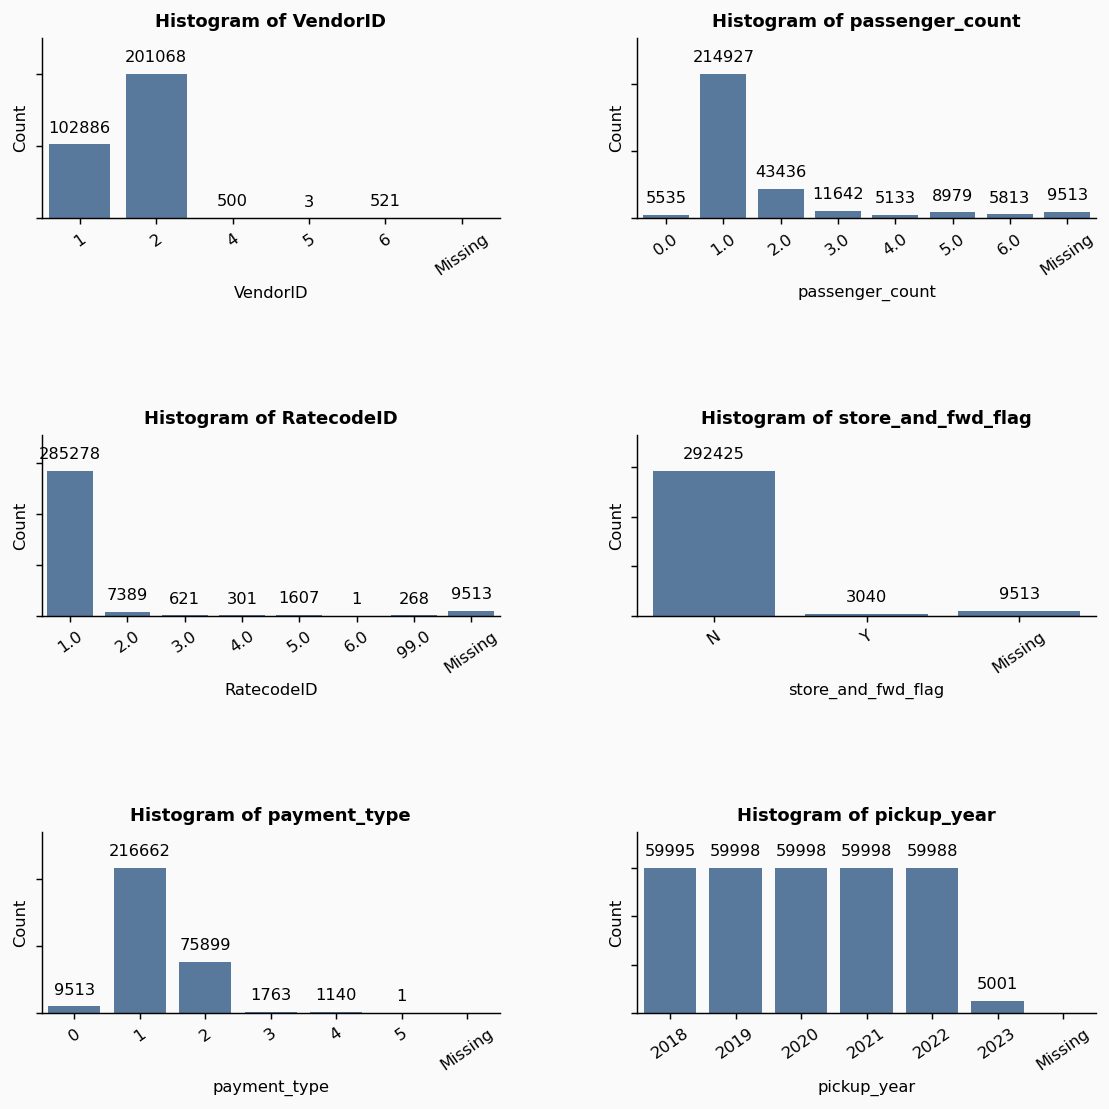

In [14]:
# I will analyze the 5 categorical columns to see whether the categories match with the expected values (from data dictionary file)
# I will also check pickup year to see whether there are any unexpected years (e.g. from data entry errors)
# Histogram (treating nulls as 'Missing' category):
pickup_year_raw = df_raw['tpep_pickup_datetime'].dt.year

plot_series = {
    'VendorID': df_raw['VendorID'],
    'passenger_count': df_raw['passenger_count'],
    'RatecodeID': df_raw['RatecodeID'],
    'store_and_fwd_flag': df_raw['store_and_fwd_flag'],
    'payment_type': df_raw['payment_type'],
    'pickup_year': pickup_year_raw
}

fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()

for ax, (col_name, ser) in zip(axes, plot_series.items()):
    ser_non_null = ser.dropna()
    # Preserve numeric ordering for numeric variables; alphabetic ordering otherwise
    if pd.api.types.is_numeric_dtype(ser_non_null):
        order_vals = sorted(ser_non_null.unique())
        order_labels = [str(int(v)) if float(v).is_integer() else str(v) for v in order_vals] + ['Missing']
        ser_plot = ser.map(lambda x: str(int(x)) if pd.notna(x) and float(x).is_integer() else (str(x) if pd.notna(x) else 'Missing'))
    else:
        order_vals = sorted(ser_non_null.astype(str).unique())
        order_labels = list(order_vals) + ['Missing']
        ser_plot = ser.astype(str).where(ser.notna(), 'Missing')

    sns.countplot(x=ser_plot, order=order_labels, ax=ax, color=PALETTE[0])
    ax.set_title(f'Histogram of {col_name}', fontweight='bold', fontsize=10)
    ax.set_xlabel(col_name, fontsize=9)
    ax.set_ylabel('Count', fontsize=9)
    ax.tick_params(axis='x', rotation=35, labelsize=9)
    ax.tick_params(axis='y', labelleft=False)

    max_height = 0
    for p in ax.patches:
        height = p.get_height()
        max_height = max(max_height, height)
        ax.annotate(f'{int(round(height, 0))}',
                    (p.get_x() + p.get_width() / 2.0, height),
                    ha='center', va='bottom', xytext=(0, 5), textcoords='offset points', fontsize=9)

    # Add extra headroom so labels and titles sit farther from the bars
    ax.set_ylim(0, max_height * 1.25 if max_height > 0 else 1)

# Add extra space between subplot panels
plt.tight_layout(pad=6)
plt.show()


- The categories of **VendorID** has some extra values not in dictionary (4 and 5, which will be treated as "Others" in the analysis)
- The categories of **RatecodeID**, **store_and_fwd_flag** and **payment_type** match the expected values from the data dictionary.
- **payment_type** has 9513 rows with value 0 (Flex Fare trip), which is the exact number of NULLs for **passenger_count**, **RatecodeID**, **store_and_fwd_flag**. I will check to see if all the NULLs happen when payment_type = 0
- **passenger_count** has ~5k records of 0, which is probably either errors or trips without any passengers.
- The 5 categorical columns are very skewed with 1 or 2 categories making up the majority of the records.
- the **pickup_year** has ~60k records for each year between 2018 and 2022, and ~5k for 2023 (1/12 of the other years). This suggests that the dataset is likely to have a cap of roughly 5k records per month (and thus 60k per year), and it is not the full data of all taxi trip records.

In [73]:
# Check if NULLs of passenger_count, RatecodeID, and store_and_fwd_flag are all when payment_type = 0
null_check = df_raw[(df_raw['passenger_count'].isnull()) | (df_raw['RatecodeID'].isnull()) | (df_raw['store_and_fwd_flag'].isnull())]
# count number of each value of payment types for rows with NULLs in passenger_count, RatecodeID, or store_and_fwd_flag
payment_type_counts = null_check['payment_type'].value_counts()
print(payment_type_counts)

payment_type
0    9513
1       0
2       0
3       0
4       0
5       0
Name: count, dtype: int64


The above results prove that the NULLs values of **passenger_count**, **RatecodeID**, **store_and_fwd_flag** happened for only Flex Fare trips (payment_type = 0).

[Back to Table of Contents](#table-of-contents)
#### b) Numerical columns


In [16]:
# Analyze numeric columns
df_raw.describe(percentiles=[.25, .5, .75]).T.round(3)

,count,mean,min,25%,50%,75%,max,std
tpep_pickup_datetime,304978,2020-07-16 11:54:50.074785792,2018-01-01 00:25:49,2019-04-08 09:18:22.500000,2020-07-17 17:01:39,2021-10-24 11:29:50.500000,2023-01-31 23:57:28,NaN
tpep_dropoff_datetime,304978,2020-07-16 12:11:31.905307648,2018-01-01 00:38:59,2019-04-08 09:32:34.750000128,2020-07-17 17:17:55,2021-10-24 11:42:53.249999872,2023-02-01 00:09:12,NaN
trip_distance,304978.0,4.587589,-16.86,1.0,1.73,3.21,177247.4,434.226624
fare_amount,304978.0,13.510189,-197.0,6.5,9.5,15.0,455.0,12.636651
extra,304978.0,0.903506,-6.0,0.0,0.5,1.0,18.5,1.185321
mta_tax,304978.0,0.492755,-0.5,0.5,0.5,0.5,2.54,0.074023
tip_amount,304978.0,2.224064,-20.0,0.0,1.86,2.95,115.56,2.7652
tolls_amount,304978.0,0.390715,-13.75,0.0,0.0,0.0,96.55,1.699547
improvement_surcharge,304978.0,0.312725,-1.0,0.3,0.3,0.3,1.0,0.110404
total_amount,304978.0,19.050501,-198.55,10.8,14.3,20.76,561.49,15.464014


Some potential data validity issues to investigate further:
- Negative values in all numerical columns (except for 2 datetime columns), which may indicate data errors:
    - Trip distance should never be negative
    - Fare, tax, toll, surcharge may be negative due to refund in some cases, but generally should be non-negative.
- To check if there are value of 0, which may be valid for some cases but could also indicate data errors.

In [17]:
# Check % of negative values in each numeric column
negative_cols = ['trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount', 
                 'tolls_amount', 'improvement_surcharge', 'total_amount', 'congestion_surcharge', 'airport_fee']
negative_flags = df_raw[negative_cols] < 0
negative_overlap = negative_flags.sum(axis=1)
# print column names and % of negative values
print("Negative value count and % per column:")
for col in negative_cols:
    count = (df_raw[col] < 0).sum()
    print(f"{col}: {count:,} ({count/len(df_raw)*100:.2f}%)")

Negative value count and % per column:
trip_distance: 9 (0.00%)
fare_amount: 1,162 (0.38%)
extra: 541 (0.18%)
mta_tax: 1,123 (0.37%)
tip_amount: 14 (0.00%)
tolls_amount: 38 (0.01%)
improvement_surcharge: 1,160 (0.38%)
total_amount: 1,167 (0.38%)
congestion_surcharge: 891 (0.29%)
airport_fee: 55 (0.02%)


The % of negative values are all below 1% and different across columns, suggesting that the negative values are likely due to data errors rather than a systematic issue affecting multiple columns. 

In [18]:
# Check % of zero values in each numeric column
zero_flags = df_raw[negative_cols] == 0
print("Zero value count and % per column:")
for col in negative_cols:
    count = (df_raw[col] == 0).sum()
    print(f"{col}: {count:,} ({count/len(df_raw)*100:.2f}%)")

Zero value count and % per column:
trip_distance: 3,882 (1.27%)
fare_amount: 129 (0.04%)
extra: 134,912 (44.24%)
mta_tax: 2,196 (0.72%)
tip_amount: 91,871 (30.12%)
tolls_amount: 287,172 (94.16%)
improvement_surcharge: 151 (0.05%)
total_amount: 78 (0.03%)
congestion_surcharge: 22,228 (7.29%)
airport_fee: 98,815 (32.40%)


Some possible explanations for the 0 values:
- trip_distance: can be 0 for cancelled trips, GPS error, or very short trips (rounded to 0), etc.
- fare_amount and total_amount: can be 0 for free trips (eg. cancelled trip or technical error or other reasons).
- The other columns can have valid 0 values.

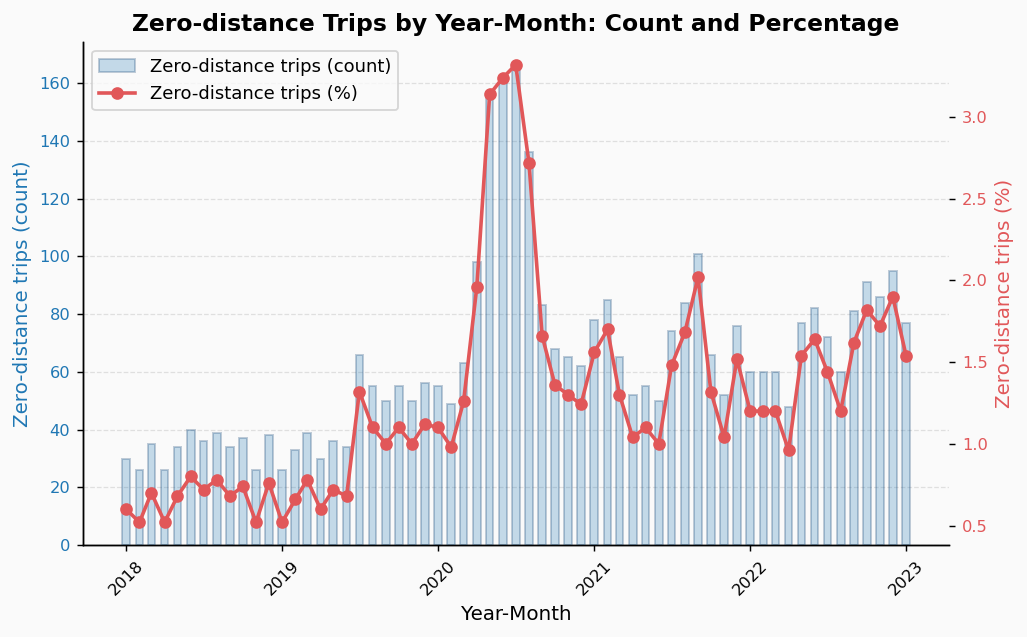

In [19]:
# Zero-distance trips by year-month: count and percentage
zero_distance_monthly = (
    df_raw.assign(
        year_month=df_raw['tpep_pickup_datetime'].dt.to_period('M').dt.to_timestamp(),
        is_zero_distance=df_raw['trip_distance'].eq(0)
    )
    .groupby('year_month')
    .agg(
        total_trips=('trip_distance', 'size'),
        zero_distance_trips=('is_zero_distance', 'sum')
    )
    .reset_index()
)

zero_distance_monthly['zero_distance_pct'] = (
    zero_distance_monthly['zero_distance_trips'] / zero_distance_monthly['total_trips'] * 100
)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_axisbelow(True)
ax1.grid(axis='y', color='#D9D9D9', linestyle='--', linewidth=0.7, alpha=0.8)

bars = ax1.bar(
    zero_distance_monthly['year_month'],
    zero_distance_monthly['zero_distance_trips'],
    color='#1F77B4',
    alpha=0.25,
    width=18,
    edgecolor='#0B3C6D',
    linewidth=1.1,
    label='Zero-distance trips (count)',
    zorder=3
)
ax1.set_xlabel('Year-Month')
ax1.set_ylabel('Zero-distance trips (count)', color='#1F77B4')
ax1.tick_params(axis='y', labelcolor='#1F77B4')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(
    zero_distance_monthly['year_month'],
    zero_distance_monthly['zero_distance_pct'],
    color=PALETTE[3],
    marker='o',
    linewidth=2,
    label='Zero-distance trips (%)'
)
ax2.set_ylabel('Zero-distance trips (%)', color=PALETTE[3])
ax2.tick_params(axis='y', labelcolor=PALETTE[3])

ax1.set_title('Zero-distance Trips by Year-Month: Count and Percentage', fontweight='bold')

# Combined legend
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

The proportion of zero-distance trips peaked in 2020. This coincides with the COVID-19 pandemic and may reflect increased ride cancellations, operational disruptions, or reporting anomalies. However, the dataset does not contain information that allows the exact cause to be determined. The effect of COVID-19 will be analyzed in section 4.3. (Sample validation).

In [20]:
# Count zero-distance trips with non-zero total_amount
zero_distance_non_zero_amount = df_raw[(df_raw['trip_distance'] == 0) & (df_raw['total_amount'] > 0)].shape[0]
print(f"Zero-distance trips with non-zero total_amount: {zero_distance_non_zero_amount:,}")

Zero-distance trips with non-zero total_amount: 3,666


It can been seen that most zero-distance trips were still charged (total_amount is not 0). There can be multiple reasons for trips with zero distance but non-zero fare:
- Cancellation (so no trips were made), but there are still some charges:
    - minimum fare charged at the start before cancellation
    - waiting times fare before cancellation 
    - driver error (starting fare meter before starting trip, not resetting meter after previous trip)
- GPS error:
    - distance was not recorded but fare was still charged
- Very short trip: distance rounded to 0

Zero-distance rate by store_and_fwd_flag:
store_and_fwd_flag  total_trips  zero_distance_trips zero_distance_pct
                 N       292425                 3518             1.20%
                 Y         3040                  134             4.41%
           Missing         9513                  230             2.42%


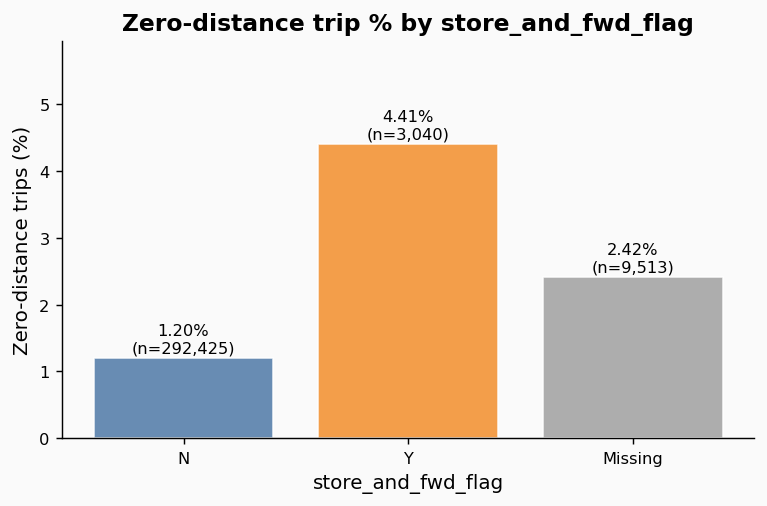


Chi-square test of independence (all flag groups):
  H0: zero-distance is independent of store_and_fwd_flag
  chi2 = 348.324, dof = 2, p-value = 2.303e-76


In [21]:
# Analyze whether zero-distance trips are associated with store_and_fwd_flag
analysis_df = df_raw[['trip_distance', 'store_and_fwd_flag']].copy()
analysis_df['zero_distance'] = analysis_df['trip_distance'].eq(0)
analysis_df['store_and_fwd_flag'] = analysis_df['store_and_fwd_flag'].astype('string').fillna('Missing').astype(str)

# Keep only common TLC values + Missing to avoid tiny noisy categories
valid_flags = ['Y', 'N', 'Missing']
analysis_df = analysis_df[analysis_df['store_and_fwd_flag'].isin(valid_flags)]

# Summary table by flag
flag_summary = (
    analysis_df.groupby('store_and_fwd_flag')
    .agg(
        total_trips=('zero_distance', 'size'),
        zero_distance_trips=('zero_distance', 'sum')
    )
    .reset_index()
)
flag_summary['zero_distance_pct'] = flag_summary['zero_distance_trips'] / flag_summary['total_trips'] * 100

# Reorder for readability
flag_order = ['N', 'Y', 'Missing']
flag_summary['sort_key'] = flag_summary['store_and_fwd_flag'].map({k: i for i, k in enumerate(flag_order)})
flag_summary = flag_summary.sort_values('sort_key').drop(columns='sort_key')

print('Zero-distance rate by store_and_fwd_flag:')
print(flag_summary.to_string(index=False, formatters={'zero_distance_pct': '{:.2f}%'.format}))

# Visual comparison
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(
    flag_summary['store_and_fwd_flag'],
    flag_summary['zero_distance_pct'],
    color=[PALETTE[0], PALETTE[1], '#A0A0A0'],
    alpha=0.85,
    edgecolor='white',
    linewidth=0.9
)
ax.set_title('Zero-distance trip % by store_and_fwd_flag', fontweight='bold')
ax.set_xlabel('store_and_fwd_flag')
ax.set_ylabel('Zero-distance trips (%)')
ax.set_ylim(0, flag_summary['zero_distance_pct'].max() * 1.35)

for bar, pct, n in zip(bars, flag_summary['zero_distance_pct'], flag_summary['total_trips']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{pct:.2f}%\n(n={n:,})",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ------------------------------
# Statistical test: Chi-square test of independence between store_and_fwd_flag and zero_distance
cont_table = pd.crosstab(analysis_df['store_and_fwd_flag'], analysis_df['zero_distance'])
from scipy.stats import chi2_contingency
chi2, p_chi2, dof, expected = chi2_contingency(cont_table)
print('\nChi-square test of independence (all flag groups):')
print(f'  H0: zero-distance is independent of store_and_fwd_flag')
print(f'  chi2 = {chi2:.3f}, dof = {dof}, p-value = {p_chi2:.3e}')

Store-and-forward trips exhibit a substantially higher rate of zero-distance records (4.41%) compared with non-store-and-forward trips (1.20%). Statistical testing confirms that this difference is highly significant (chi-square test: p < 0.001). This suggests that data transmission delays or operational circumstances associated with store-and-forward records may be linked to a higher likelihood of anomalous trip records, although causality cannot be determined from the available data.

[Back to Table of Contents](#table-of-contents)
### 2.4. Data Accuracy

Some potential data quality issues to investigate:
- Check for unusually high values of some metrics. This indicates data errors or outliers, as such trips are uncommon/impossible in NYC.
    - trip distance (eg. above 100 miles) 
    - trip durations (eg. above 3 hours)
    - speed (eg. over 100 mph)
- Check if total_amount is the sum of other columns, as this is expected based on the data dictionary.

#### a) Trip Distance (mile)

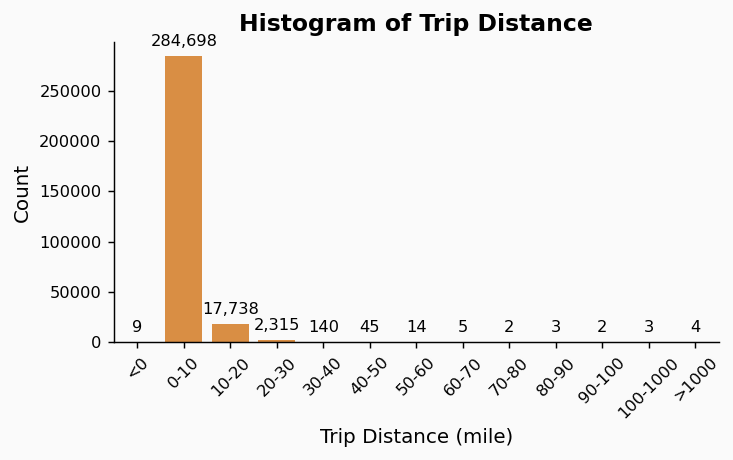

In [22]:
# Build frequency tables of trip_distance, including negative values
bins = [float('-inf'), 0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 1000, float('inf')]
labels = ['<0', '0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80', '80-90', '90-100', '100-1000', '>1000']
trip_distance_bin = pd.cut(df_raw['trip_distance'], bins=bins, labels=labels, right=False)
trip_distance_freq = trip_distance_bin.value_counts().sort_index()

# Draw a bar chart of the frequency distribution of trip_distance bins
plt.figure(figsize=(6, 3)) 
ax = sns.barplot(x=trip_distance_freq.index, y=trip_distance_freq.values, color=PALETTE[1])
plt.title('Histogram of Trip Distance', fontweight='bold')
plt.xlabel('Trip Distance (mile)')
plt.ylabel('Count')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2.0, height),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9)
plt.xticks(rotation=45)
plt.show()

Some trips have very long distances (eg. 100-1000 miles or >1000 miles) which are likely data errors, 
as these distances are not plausible for taxi trips within NYC. There are also negative distance values which need to be removed.

[Back to Table of Contents](#table-of-contents)
#### b) Trip Duration (minute)

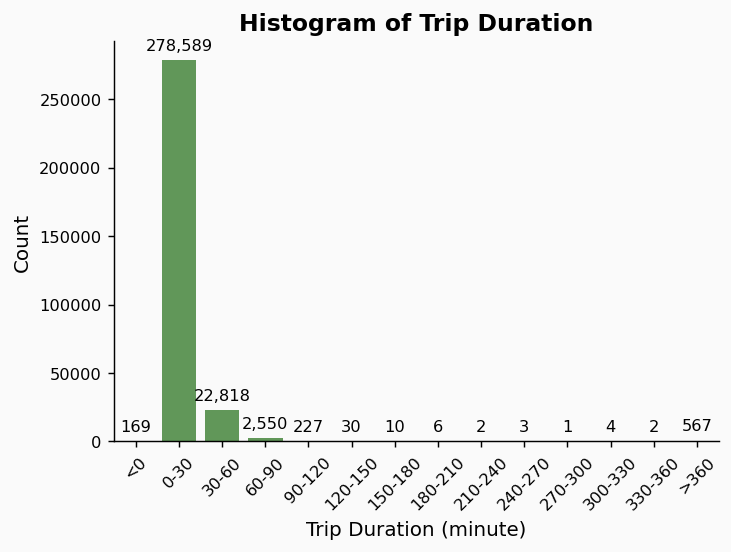

In [23]:
# Create histogram of trip duration, each bin is 30 minutes, including negative durations
trip_duration = (df_raw['tpep_dropoff_datetime'] - df_raw['tpep_pickup_datetime']).dt.total_seconds() / 60
duration_bins_30min = [float('-inf'), 0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330, 360, float('inf')]
duration_labels_30min = ['<0', '0-30', '30-60', '60-90', '90-120', '120-150', '150-180', '180-210', '210-240', '240-270', '270-300', '300-330', '330-360', '>360']
trip_duration_bin_30min = pd.cut(trip_duration, bins=duration_bins_30min, labels=duration_labels_30min, right=False)
trip_duration_freq_30min = trip_duration_bin_30min.value_counts().sort_index()
# Draw a bar chart of the frequency distribution of trip duration bins (30 min bins)
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=trip_duration_freq_30min.index, y=trip_duration_freq_30min.values, color=PALETTE[2])
plt.title('Histogram of Trip Duration', fontweight='bold')
plt.xlabel('Trip Duration (minute)')
plt.ylabel('Count')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2.0, height),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9)
plt.xticks(rotation=45)
plt.show()

Again, very long trips (3 hours) and negative duration are potential data errors.

[Back to Table of Contents](#table-of-contents)
#### c) Speed (mph)


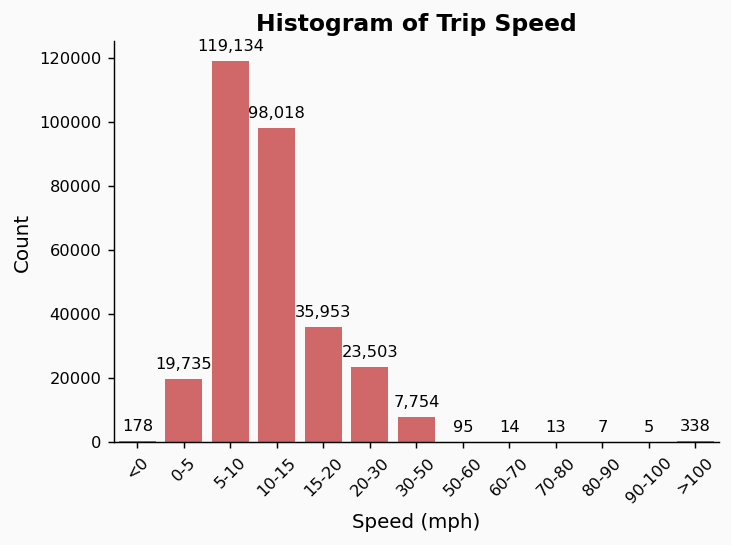

In [24]:
# Calculate speed in miles per hour and check for outliers, including negative speeds.
trip_duration_hours = trip_duration / 60
speed_mph = df_raw['trip_distance'] / trip_duration_hours
speed_bins = [float('-inf'), 0, 5, 10, 15, 20, 30, 50, 60, 70, 80, 90, 100, float('inf')]
speed_labels = ['<0', '0-5', '5-10', '10-15', '15-20', '20-30', '30-50', '50-60', '60-70', '70-80', '80-90', '90-100', '>100']
speed_bin = pd.cut(speed_mph, bins=speed_bins, labels=speed_labels, right=False)
speed_freq = speed_bin.value_counts().sort_index()

# Draw a bar chart of the frequency distribution of speed bins
plt.figure(figsize=(6, 4))
ax = sns.barplot(x=speed_freq.index, y=speed_freq.values, color=PALETTE[3])
plt.title('Histogram of Trip Speed', fontweight='bold')
plt.xlabel('Speed (mph)')
plt.ylabel('Count')
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height):,}',
                (p.get_x() + p.get_width() / 2.0, height),
                ha='center', va='bottom', xytext=(0, 4), textcoords='offset points', fontsize=9)
plt.xticks(rotation=45)
plt.show()

Majority of trips have relatively slow speed (5-15 mph). Negative speeds are impossible, and speed above 100 mph are very unlikely within NYC.

[Back to Table of Contents](#table-of-contents)
#### d) Total_amount vs Sum of components


In [25]:
# Check if total_amount is the sum of other fare columns
# We will allow for a small tolerance to account for any rounding issues.
calculated_total = df_raw['fare_amount'] + df_raw['extra'] + df_raw['mta_tax'] + df_raw['tip_amount'] + df_raw['tolls_amount'] + \
                    df_raw['improvement_surcharge'] + df_raw['congestion_surcharge'].fillna(0) + df_raw['airport_fee'].fillna(0)
total_mismatch = (df_raw['total_amount'] - calculated_total).abs() > 0.01
mismatch_count = total_mismatch.sum()
print(f"Total amount mismatch count: {mismatch_count:,} ({mismatch_count/len(df_raw)*100:.2f}%)")

# Create a frequency table (including % of total trips) of the total_amount mismatches to see if there are any patterns in the mismatches
mismatch_diff = (df_raw['total_amount'] - calculated_total).round(2)
mismatch_freq = mismatch_diff[total_mismatch].value_counts().sort_index()
mismatch_freq_df = mismatch_freq.reset_index()
mismatch_freq_df.columns = ['Difference', 'Frequency']
mismatch_freq_df['Percentage'] = round(mismatch_freq_df['Frequency'] / len(df_raw) * 100, 2)
mismatch_freq_df

Total amount mismatch count: 73,680 (24.16%)


,Difference,Frequency,Percentage
0,-3.90,1,0.00
1,-3.75,924,0.30
2,-2.80,6,0.00
3,-2.50,66803,21.90
4,-1.75,1,0.00
5,-1.25,908,0.30
6,-0.80,1,0.00
7,-0.30,2,0.00
8,0.75,2,0.00
9,1.94,1,0.00


- Most mismatches are at specific values (-2.50 and +2.50), which are possible values of congestion_surcharge, suggesting some inaccurate/missing congestion_surcharge in the dataset.
- The other mismatch account for much smaller percentages.

In [26]:
# Find out when mismatch = +/- 2.50, what are the distribution of congestion_surcharge:
print("Distribution of congestion_surcharge when mismatch is -2.50:")
print(df_raw.loc[np.isclose(mismatch_diff, -2.50) & total_mismatch, 'congestion_surcharge'].value_counts(dropna=False).to_string())
print("\nDistribution of congestion_surcharge when mismatch is +2.50:")
print(df_raw.loc[np.isclose(mismatch_diff, 2.50) & total_mismatch, 'congestion_surcharge'].value_counts(dropna=False).to_string())


Distribution of congestion_surcharge when mismatch is -2.50:
congestion_surcharge
 2.5    66797
 0.0        3
-2.5        3

Distribution of congestion_surcharge when mismatch is +2.50:
congestion_surcharge
NaN    4292
2.5      94
0.0       3


From the above results, congestion_surcharge can be used to explain for the mismatch of +/-2.50

Possible explanation:
- Mismatch = -2.5 : due to congestion_surcharge of 2.50
    - congestion_surcharge is correctly recorded as 2.50, but NOT included in total_amount
    - congestion_surcharge is wrongly recorded as 2.50 (should be 0 instead)

- Mismatch = +2.5 : due to NULL congestion_surcharge
    - congestion_surcharge is NOT recorded, but included in total_amount

I will run a statistical test to confirm this assocociation.

In [27]:
# Run statistical test to see if mismatch is associated with congestion_surcharge
# We will categorize congestion_surcharge into 5 groups: NaN, 0, -2.5, +2.5, and Other Congestion
# We will categorize mismatch into 4 groups: Mismatch = -2.5, Mismatch = +2.5, Other Mismatch, and No Mismatch
analysis_df = df_raw.copy()
analysis_df['mismatch_category'] = np.where(total_mismatch, np.where(np.isclose(mismatch_diff, -2.50), '-2.5', 
                                                                     np.where(np.isclose(mismatch_diff, 2.50), '+2.5', 
                                                                              'Other Mismatch')), 'No Mismatch')
analysis_df['congestion_category'] = np.where(analysis_df['congestion_surcharge'].isna(), 'NaN',
                                              np.where(analysis_df['congestion_surcharge'] == 0, '0',
                                                       np.where(np.isclose(analysis_df['congestion_surcharge'], -2.50), '-2.5',
                                                                np.where(np.isclose(analysis_df['congestion_surcharge'], 2.50), '+2.5',
                                                                         'Other Congestion'))))
cont_table = pd.crosstab(analysis_df['mismatch_category'], analysis_df['congestion_category'])
try:
    from scipy.stats import chi2_contingency
    chi2, p_chi2, dof, expected = chi2_contingency(cont_table)
    print('\nChi-square test of independence between mismatch_category and congestion_category:')
    print(f'  H0: mismatch_category is independent of congestion_category')
    print(f'  chi2 = {chi2:.3f}, dof = {dof}, p-value = {p_chi2:.3e}')
except Exception as e:
    print('\nChi-square test was skipped (scipy not available in this kernel).')
    print(f'  Detail: {e}')



Chi-square test of independence between mismatch_category and congestion_category:
  H0: mismatch_category is independent of congestion_category
  chi2 = 53858.658, dof = 12, p-value = 0.000e+00


- The above result confirms that there is a strong association between the total_amount mismatch and the congestion_surcharge, particularly with the -2.50 and +2.50 values. This suggests that the mismatches may be related to specific congestion surcharge amounts, which could indicate systematic issues in how these surcharges are being applied or recorded in the dataset.

[Back to Table of Contents](#table-of-contents)
## **3. Data Cleaning**

In [28]:
df = df_raw.copy()
print(f"Rows in working dataframe: {len(df):,}")

Rows in working dataframe: 304,978


### 3.1. Data Completeness
**Operational metadata** NULLs (passenger_count, RatecodeID, store_and_fwd_flag) will be mode-imputed with missingness flags.

**Financial fee** NULLs (congestion_surcharge, airport_fee) are retained as missing; only temporarily treated as 0 in specific arithmetic analysis.”


Why impute instead of drop the 3-way **Operational metadata** NULLs? 

- Missingness is likely due to a specific data collection issue and not random, and these are categorical variables where mode imputation is appropriate.
- Dropping 3.1% of rows is defensible, but those rows have fully valid financial fields as the null is in operational metadata (passenger count, rate code, flag). Imputing preserves the financial signal without introducing noise.

In [29]:
# Add a flag column for whether the trip has any missing values in the 3 columns with the systematic null issue
df['has_null_metadata'] = df[['passenger_count', 'RatecodeID', 'store_and_fwd_flag']].isnull().any(axis=1)

# I will impute the missing values in passenger_count, RatecodeID, store_and_fwd_flag using mode:
df['passenger_count'].fillna(df['passenger_count'].mode()[0], inplace=True) 
df['RatecodeID'].fillna(df['RatecodeID'].mode()[0], inplace=True)
df['store_and_fwd_flag'].fillna(df['store_and_fwd_flag'].mode()[0], inplace=True)

For **congestion_surcharge** and **airport_fee**, I will leave them as NULL rather than changing those to 0 (so it can be a flag instead of mixing them with valid 0 values). Reverse-engineering these fees from total_amount and other fare columns is risky due to the finding about mismatch in section 2.4 and the large numbers of nulls for these 2 columns.

[Back to Table of Contents](#table-of-contents)
### 3.2. Data Uniqueness

From 2.2., there are 3 pairs of duplicates.
- 2 pairs with NULL metadata issue: I will delete 1 row in each pair (the row with the as_null_metadata flag from 3.1.)
- 1 pair with negative financial data: I will delete the row with negative total_amount

In [30]:
# Delete problematic rows only within duplicate time-location groups
df_before_uniqueness = len(df)
dup_time_loc = df.duplicated(
    subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID'],
    keep=False
)

# Drop rows in duplicate groups if metadata is missing OR total_amount is negative
drop_mask = (dup_time_loc & df['has_null_metadata']) | (dup_time_loc & (df['total_amount'] < 0))
df = df[~drop_mask]

# Check duplicates again based on time and location columns only
duplicate_count_time_loc_after = df.duplicated(
    subset=['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID']
).sum()
print(f"Duplicate rows based on time and location columns after cleaning: {duplicate_count_time_loc_after}")

# Print number of rows removed and remaining in this step
rows_removed_32 = df_before_uniqueness - len(df)
print(f"\nRows removed in 3.2 (Data Uniqueness): {rows_removed_32:,} ({rows_removed_32/df_before_uniqueness*100:.2f}%)")
print(f"Rows remaining after 3.2: {len(df):,}")

Duplicate rows based on time and location columns after cleaning: 0

Rows removed in 3.2 (Data Uniqueness): 3 (0.00%)
Rows remaining after 3.2: 304,975


[Back to Table of Contents](#table-of-contents)
### 3.3. Data Validity

For numerical columns:
- Negative values are likely to be errors. Besides, the number of negative values are small. I will drop the rows with negative values.
- Zero values can have valid reasons, so I will leave them there. Removing zero-distance trips silently would undercount minimum-fare and cancellation-related revenue. 

In [31]:
# 3.3 Data Validity: remove rows with impossible negative financial/distance values
df_before_validity = len(df)

# Columns that must be non-negative
strict_non_negative_cols = [
    'trip_distance', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
    'tolls_amount', 'improvement_surcharge', 'total_amount'
]

# Optional-fee columns: keep NULL, but if present they must be non-negative
nullable_non_negative_cols = ['congestion_surcharge', 'airport_fee']

# Build one mask so filtering is applied once and easy to audit
valid_mask = (df[strict_non_negative_cols] >= 0).all(axis=1)
for col in nullable_non_negative_cols:
    valid_mask &= df[col].isnull() | (df[col] >= 0)

df = df[valid_mask].copy()

# Verify no negative values remain in enforced columns
neg_check_cols = strict_non_negative_cols + nullable_non_negative_cols
remaining_negatives = (df[neg_check_cols] < 0).sum()
print("Remaining negative counts by column:")
print(remaining_negatives)

# Audit outputs for this step
rows_removed_33 = df_before_validity - len(df)
print(f"\nRows removed in 3.3 (Data Validity): {rows_removed_33:,} ({rows_removed_33/df_before_validity*100:.2f}%)")
print(f"Rows remaining after 3.3: {len(df):,}")

Remaining negative counts by column:
trip_distance            0
fare_amount              0
extra                    0
mta_tax                  0
tip_amount               0
tolls_amount             0
improvement_surcharge    0
total_amount             0
congestion_surcharge     0
airport_fee              0
dtype: int64

Rows removed in 3.3 (Data Validity): 1,180 (0.39%)
Rows remaining after 3.3: 303,795


[Back to Table of Contents](#table-of-contents)
### 3.4. Data Accuracy

I keep only trips within practical plausibility bounds:
- trip_distance <= 100 miles
- trip_duration_min <= 180 minutes
- avg_speed_mph <= 100 mph

I also require trip_duration_min > 0 before speed calculation. This avoids invalid division (infinite/undefined speed) from zero or negative durations and makes the filtering logic explicit and auditable.

Another possible approach is percentile-based trimming (for example, keeping the central 99% of records). The final threshold choice depends on domain judgment and the analysis objective.

In [32]:
# 3.4 Data Accuracy: keep plausible trips based on distance, duration, and speed thresholds
df_before_accuracy = len(df)

# Recompute duration from timestamps
df['trip_duration_min'] = (
    df['tpep_dropoff_datetime'] - df['tpep_pickup_datetime']
).dt.total_seconds() / 60

# Require strictly positive duration before speed calculation to avoid inf/NaN speeds
positive_duration = df['trip_duration_min'] > 0
df['avg_speed_mph'] = np.where(
    positive_duration,
    df['trip_distance'] / (df['trip_duration_min'] / 60),
    np.nan
)

# Apply business plausibility thresholds
accuracy_mask = (
    (df['trip_distance'] <= 100) &
    (df['trip_duration_min'] <= 180) &
    (df['avg_speed_mph'] <= 100) &
    positive_duration &
    (df['avg_speed_mph'] >= 0)
)

df = df[accuracy_mask].copy()

# Audit outputs for this step
rows_removed_34 = df_before_accuracy - len(df)
print(f"Rows removed in 3.4 (Data Accuracy): {rows_removed_34:,} ({rows_removed_34/df_before_accuracy*100:.2f}%)")
print(f"Rows remaining after 3.4: {len(df):,}")

Rows removed in 3.4 (Data Accuracy): 1,321 (0.43%)
Rows remaining after 3.4: 302,474


Based on the accuracy checks in Section 2.4, total_amount mismatches are strongly associated with congestion_surcharge patterns (especially +/-2.50), suggesting a systematic recording issue rather than random noise. However, the dataset does not provide a reliable business rule to determine whether total_amount or congestion_surcharge is incorrect for each affected trip. Therefore, no direct reconciliation is applied to either source field in the cleaning pipeline.

For analysis only, I add derived helper fields and keep source columns unchanged:
- `is_total_mismatch`: whether `total_amount` differs from the sum of fare components by more than 0.01.
- `congestion_surcharge_inferred`: inferred only when observed `congestion_surcharge` is NULL and the implied value is one of {-2.50, 0.00, 2.50}; otherwise left as NULL.

These helper fields are used for diagnostic analysis and sensitivity checks, not as corrected ground truth values.

In [33]:
# Analysis-only reconciliation helpers (do not overwrite source fields)
components_total = (
    df['fare_amount'] + df['extra'] + df['mta_tax'] + df['tip_amount'] +
    df['tolls_amount'] + df['improvement_surcharge'] +
    df['congestion_surcharge'].fillna(0) + df['airport_fee'].fillna(0)
)
df['is_total_mismatch'] = (df['total_amount'] - components_total).abs() > 0.01

# Infer congestion only for a conservative set of expected values when source is missing
base_without_congestion = (
    df['fare_amount'] + df['extra'] + df['mta_tax'] + df['tip_amount'] +
    df['tolls_amount'] + df['improvement_surcharge'] + df['airport_fee'].fillna(0)
)
inferred_congestion = (df['total_amount'] - base_without_congestion).round(2)
allowed_inferred_values = [-2.50, 0.00, 2.50]
df['congestion_surcharge_inferred'] = np.where(
    df['congestion_surcharge'].isna() & inferred_congestion.isin(allowed_inferred_values),
    inferred_congestion,
    np.nan
)

In [34]:
# Check the cleaned data
df.describe(percentiles=[.25, .5, .75]).T.round(3)

,count,mean,min,25%,50%,75%,max,std
tpep_pickup_datetime,302474,2020-07-15 06:39:29.173320448,2018-01-01 00:25:49,2019-04-06 15:42:53,2020-07-15 15:46:42,2021-10-23 13:36:46.249999872,2023-01-31 23:57:28,NaN
tpep_dropoff_datetime,302474,2020-07-15 06:53:43.063664640,2018-01-01 00:38:59,2019-04-06 16:05:09.750000128,2020-07-15 16:04:19,2021-10-23 13:54:03.249999872,2023-02-01 00:09:12,NaN
trip_distance,302474.0,3.125422,0.0,1.01,1.73,3.2,85.2,4.005545
fare_amount,302474.0,13.572827,0.0,6.5,9.5,15.0,455.0,12.405749
extra,302474.0,0.909715,0.0,0.0,0.5,1.0,18.5,1.184525
mta_tax,302474.0,0.496657,0.0,0.5,0.5,0.5,2.54,0.041595
tip_amount,302474.0,2.234969,0.0,0.0,1.95,2.96,115.56,2.753456
tolls_amount,302474.0,0.392565,0.0,0.0,0.0,0.0,96.55,1.693603
improvement_surcharge,302474.0,0.315262,0.0,0.3,0.3,0.3,1.0,0.102771
total_amount,302474.0,19.15277,0.0,10.8,14.6,20.76,480.96,15.199007


The min and max values of numeric columns are more reasonable now.

In [35]:
# Final check: Number of rows removed and remaining after all cleaning steps
rows_removed = len(df_raw) - len(df)
rows_remaining = len(df)
pct_removed = rows_removed / len(df_raw) * 100
pct_remaining = rows_remaining / len(df_raw) * 100

print(f"Rows removed: {rows_removed:,} ({pct_removed:.2f}%)")
print(f"Rows remaining: {rows_remaining:,} ({pct_remaining:.2f}%)")

Rows removed: 2,504 (0.82%)
Rows remaining: 302,474 (99.18%)


[Back to Table of Contents](#table-of-contents)
## **4. Feature Engineering**

#### 4.1. Add new columns
I will add some more columns that are useful for data analysis.

In [36]:
# Datetime-derived features 
df['pickup_year']    = df['tpep_pickup_datetime'].dt.year
df['pickup_month']   = df['tpep_pickup_datetime'].dt.month
df['pickup_dow']     = df['tpep_pickup_datetime'].dt.day_of_week   # 0=Mon
df['pickup_hour']    = df['tpep_pickup_datetime'].dt.hour
df['pickup_date']    = df['tpep_pickup_datetime'].dt.date

# Derived flags & labels 
vendor_map = {1: 'Creative Mobile Technologies, LLC', 2: 'Curb Mobility, LLC', 3: 'Others', 4: 'Others', 5: 'Others', 6: 'Myle Technologies Inc', 7: 'Helix'}
df['vendor_name'] = df['VendorID'].map(vendor_map)

rate_map = {1: 'Standard', 2: 'JFK', 3: 'Newark', 4: 'Nassau/Westchester', 5: 'Negotiated', 6: 'Group Ride', 99: 'Unknown'}
df['rate_label'] = df['RatecodeID'].map(rate_map)

payment_map = {0: 'Flex Fare', 1: 'Credit Card', 2: 'Cash', 3: 'No Charge', 4: 'Dispute', 5: 'Unknown', 6: 'Voided'}
df['payment_label'] = df['payment_type'].map(payment_map)

dow_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
df['dow_label'] = df['pickup_dow'].map(dow_map)

# Tip rate (only meaningful for card payments)
df['tip_pct'] = np.where(df['total_amount'] > 0, df['tip_amount'] / df['total_amount'] * 100, np.nan)


[Back to Table of Contents](#table-of-contents)
### 4.2. Load extra geospatial data
I will use 2 extra data sources from the **NYC Taxi and Limousine Commission (TLC)** public data repository https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

- Zone names lookup table: https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv
- Zone shapefiles: https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip

The taxi_zone_lookup.csv file is a **lookup table** that translates the numeric location IDs into meaningful geographic areas. It has 4 columns as follows:

| Column | Meaning |
|----------|----------|
| LocationID | Numeric zone identifier used in taxi trip records |
| Borough | One of the five NYC boroughs (Manhattan, Brooklyn, Queens, Bronx, Staten Island) + Newwark Airport (EWR)|
| Zone | Name of the taxi zone or neighborhood |
| service_zone | Taxi service classification for that area (Yellow, Boro, Airports, EWR) |

**Why this table is useful**

The taxi trip dataset contains numeric location identifiers:

- PULocationID = Pickup Location ID
- DOLocationID = Dropoff Location ID

By joining these columns with the lookup table, we can identify:

- The borough where a trip starts or ends
- The pickup and dropoff neighborhoods
- Airport-related trips (JFK, LaGuardia, Newark)
- Travel patterns between boroughs
- Geographic demand hotspots

In [37]:
# Load shared geospatial references from local files
zone_lookup = pd.read_csv('taxi_zone_lookup.csv')[['LocationID', 'Borough', 'Zone', 'service_zone']]
zones_gdf = gpd.read_file('taxi_zones/taxi_zones.shp')[['LocationID', 'zone', 'borough', 'geometry']].rename(
    columns={'LocationID': 'PULocationID', 'zone': 'Zone', 'borough': 'Borough'}
)

zone_lookup.head()

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


In [38]:
# Add pickup/dropoff zone attributes using the shared lookup table
zone_map = zone_lookup.set_index('LocationID')

df['pickup_borough'] = df['PULocationID'].map(zone_map['Borough'])
df['pickup_zone'] = df['PULocationID'].map(zone_map['Zone'])
df['pickup_service_zone'] = df['PULocationID'].map(zone_map['service_zone'])

df['dropoff_borough'] = df['DOLocationID'].map(zone_map['Borough'])
df['dropoff_zone'] = df['DOLocationID'].map(zone_map['Zone'])
df['dropoff_service_zone'] = df['DOLocationID'].map(zone_map['service_zone'])

# Count unique LocationIDs by Borough and service_zone
borough_service_table = (
    zone_lookup.groupby(['Borough', 'service_zone'])['LocationID']
    .nunique()
    .unstack(fill_value=0)
    .sort_index()
)

borough_service_table['Total'] = borough_service_table.sum(axis=1)
borough_service_table.loc['Total'] = borough_service_table.sum(axis=0)

borough_service_table

service_zone,Airports,Boro Zone,EWR,Yellow Zone,Total
Borough,,,,,
Bronx,0,43,0,0,43
Brooklyn,0,61,0,0,61
EWR,0,0,1,0,1
Manhattan,0,14,0,55,69
Queens,2,67,0,0,69
Staten Island,0,20,0,0,20
Total,2,205,1,55,263


[Back to Table of Contents](#table-of-contents)
### 4.3. Sample validation
This section will first assess whether the dataset is representative of the trends over time.

Second, as mentioned in 2.3. (Data Validity) zero-distance trips peaked in 2020. I will analyze some other metrics to see if they also experience the same disruption, which is correlated with COVID-19 pandemic.

#### a) Representativeness Assessment
Because the dataset is capped at approximately 5,000 trips per month, it is important to verify that the sample is internally consistent before drawing conclusions from ratio metrics (efficiency, payment mix, tip behavior). If the sample composition shifted across months — for example, if certain boroughs or payment types were over-represented in some periods — trend metrics could reflect sampling artifacts rather than true operational changes.

We test three key dimensions: **payment type mix**, **borough distribution**, and **hourly distribution** — checking whether they are stable across months.

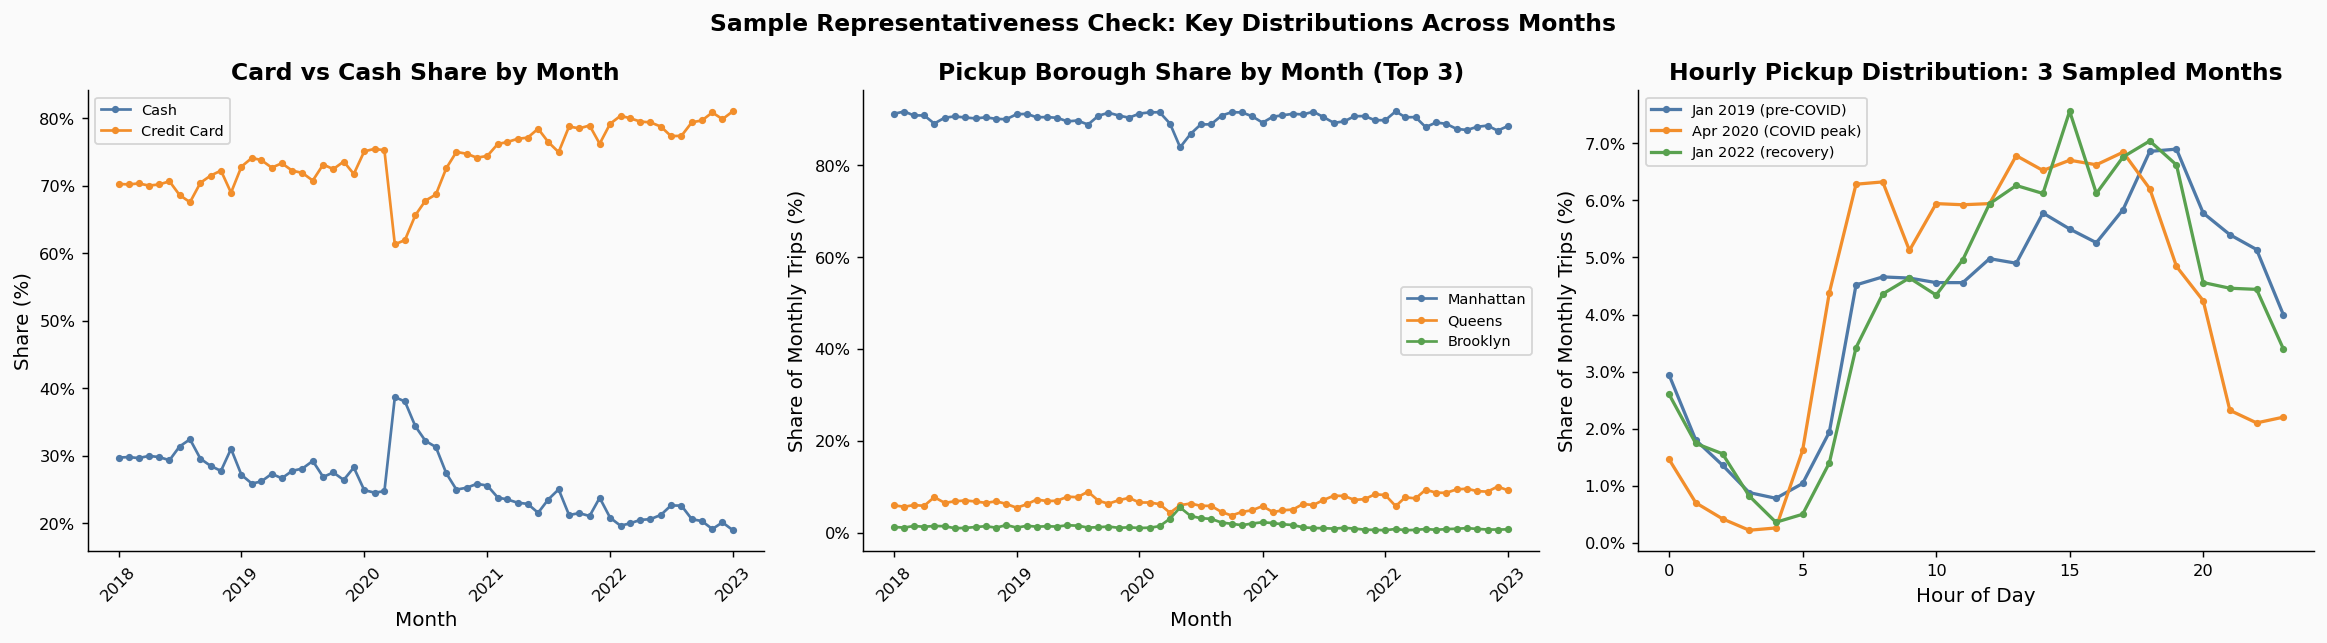

Stability check (Coefficient of Variation across months):
  Card share CV: 0.061
  Manhattan pickup share CV: 0.016

Interpretation: CV < 0.10 indicates stable composition; higher values warrant caution in trend analysis.


In [39]:
# ── Sample Representativeness Check ──────────────────────────────────────
# Test whether payment mix, borough share, and hourly distribution are
# stable across months (a badly biased sample would show erratic swings)
# I use df_raw to exclude any effects from cleaning steps
rep_df = df_raw.copy()
rep_df['year_month'] = rep_df['tpep_pickup_datetime'].dt.to_period('M').dt.to_timestamp()
rep_df['pickup_hour'] = rep_df['tpep_pickup_datetime'].dt.hour

# Add borough via lookup
zone_map_rep = zone_lookup.set_index('LocationID')['Borough']
rep_df['pickup_borough'] = rep_df['PULocationID'].map(zone_map_rep)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Sample Representativeness Check: Key Distributions Across Months',
             fontsize=13, fontweight='bold')

# 1) Payment type share by month (card vs cash as % of total)
pay_monthly = (
    rep_df[rep_df['payment_type'].isin([1, 2])]
    .assign(payment_label=lambda d: d['payment_type'].map({1: 'Credit Card', 2: 'Cash'}))
    .groupby(['year_month', 'payment_label'])
    .size()
    .unstack(fill_value=0)
)
pay_monthly_pct = pay_monthly.div(pay_monthly.sum(axis=1), axis=0) * 100

for col, color in zip(pay_monthly_pct.columns, [PALETTE[0], PALETTE[1]]):
    axes[0].plot(pay_monthly_pct.index, pay_monthly_pct[col],
                 label=col, color=color, linewidth=1.5, marker='o', markersize=3)
axes[0].set_title('Card vs Cash Share by Month', fontweight='bold')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Share (%)')
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(fontsize=8)

# 2) Borough pickup share by month (Manhattan vs Queens vs Brooklyn)
top_boroughs = ['Manhattan', 'Queens', 'Brooklyn']
borough_monthly = (
    rep_df[rep_df['pickup_borough'].isin(top_boroughs)]
    .groupby(['year_month', 'pickup_borough'])
    .size()
    .unstack(fill_value=0)
)
borough_monthly_pct = borough_monthly.div(rep_df.groupby('year_month').size(), axis=0) * 100

for col, color in zip(top_boroughs, PALETTE[:3]):
    if col in borough_monthly_pct.columns:
        axes[1].plot(borough_monthly_pct.index, borough_monthly_pct[col],
                     label=col, color=color, linewidth=1.5, marker='o', markersize=3)
axes[1].set_title('Pickup Borough Share by Month (Top 3)', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Share of Monthly Trips (%)')
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=8)

# 3) Hourly distribution stability — plot mean hour-of-day share for selected months
# Compare a pre-COVID month, a COVID month, and a post-COVID month
test_months = {
    'Jan 2019 (pre-COVID)': pd.Timestamp('2019-01-01'),
    'Apr 2020 (COVID peak)': pd.Timestamp('2020-04-01'),
    'Jan 2022 (recovery)':  pd.Timestamp('2022-01-01'),
}
for label, ts in test_months.items():
    subset = rep_df[rep_df['year_month'] == ts]
    if len(subset) > 0:
        hourly_share = subset['pickup_hour'].value_counts(normalize=True).sort_index() * 100
        hourly_share = hourly_share.reindex(range(24), fill_value=0)
        axes[2].plot(range(24), hourly_share.values, label=label, linewidth=1.8, marker='o', markersize=3)

axes[2].set_title('Hourly Pickup Distribution: 3 Sampled Months', fontweight='bold')
axes[2].set_xlabel('Hour of Day')
axes[2].set_ylabel('Share of Monthly Trips (%)')
axes[2].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

# Coefficient of variation (CV) across months for card share and Manhattan share
card_share_monthly = pay_monthly_pct.get('Credit Card', pd.Series(dtype=float))
manhattan_share_monthly = borough_monthly_pct.get('Manhattan', pd.Series(dtype=float))

print('Stability check (Coefficient of Variation across months):')
print(f"  Card share CV: {card_share_monthly.std() / card_share_monthly.mean():.3f}")
print(f"  Manhattan pickup share CV: {manhattan_share_monthly.std() / manhattan_share_monthly.mean():.3f}")
print()
print('Interpretation: CV < 0.10 indicates stable composition; higher values warrant caution in trend analysis.')

**Representativeness Assessment**

- **Payment mix** shows a smooth, monotonic trend (credit card rising, cash falling) except for a disruption in early 2020 probably due to Covid.
- **Borough share** is stable across most months, with the expected 2020 dip in Manhattan share (as city-center trips collapsed during lockdowns) followed by recovery. This dip reflects a real operational shift, not a sampling artifact.
- **Hourly distribution** is broadly similar across the three reference months, though the COVID-peak month (April 2020) shows a flatter curve with less evening concentration — again, a real-world signal rather than a sampling issue.
- **Conclusion:** The sample appears internally consistent. Ratio metrics (fare per trip, payment mix, tip rate, efficiency per mile/minute) are suitable for trend analysis. Absolute volume figures remain unreliable due to the cap.

#### b) Covid impact

The spikes in 2020 in several metrics is a signal worth investigating more broadly. Below we quantify the pandemic's effect across key operational metrics — demand, fare, payment mix, and tipping — and trace the recovery path from 2020 through 2022.

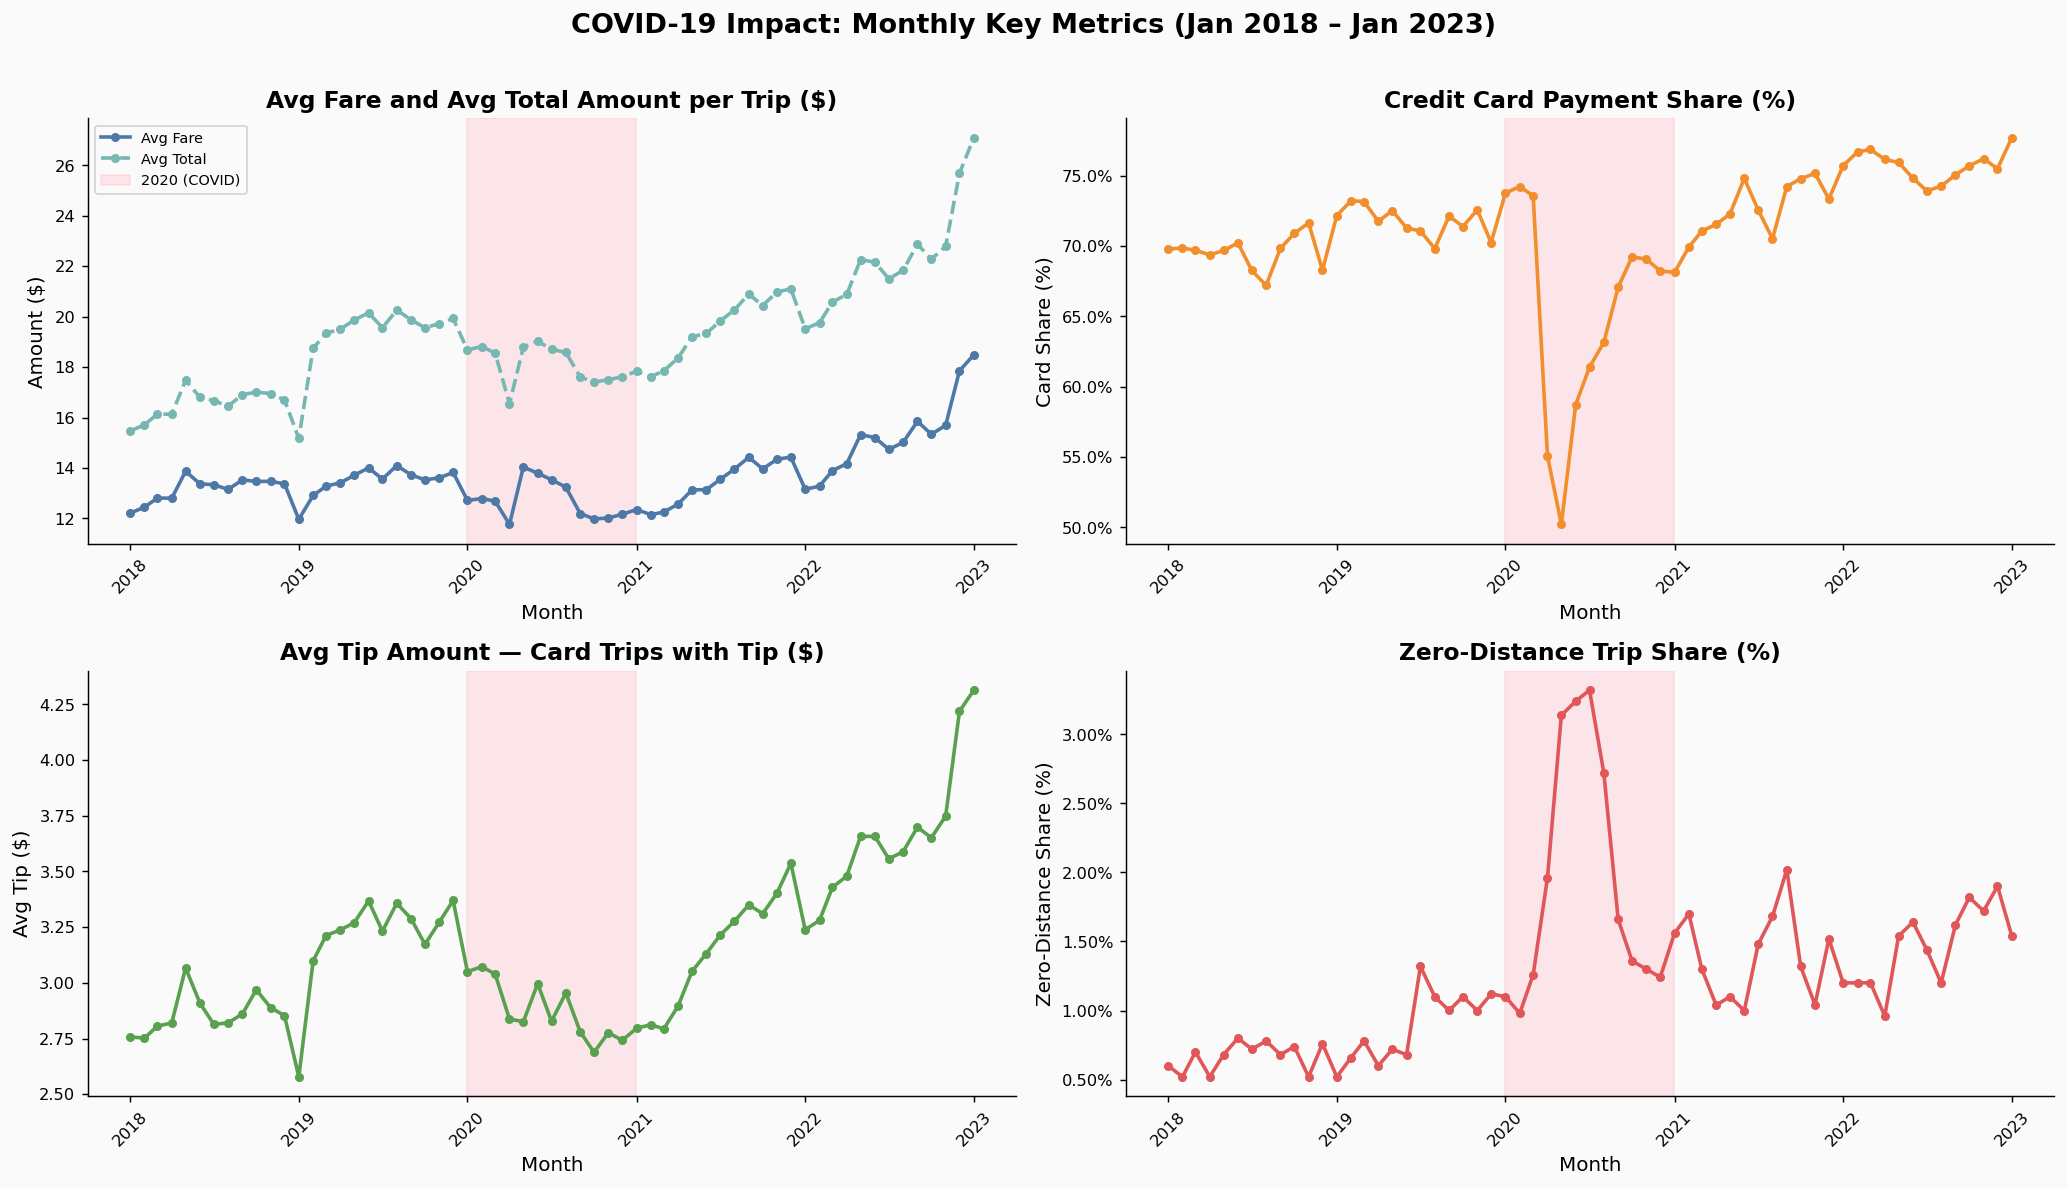

COVID-19 Period Comparison:
                      avg_fare  avg_total  card_share_pct  zero_dist_pct  avg_tip
period                                                                           
Pre-COVID (2018-19)      13.31      17.92           70.79           0.73     3.04
COVID (2020)             12.74      18.15           65.66           1.87     2.89
Recovery (2021-22)       14.16      20.66           74.42           1.34     3.37
Post-Recovery (2023)     18.48      27.10           78.27           1.41     4.31


In [40]:
# COVID-19 Impact Analysis: how did key metrics shift across 2018-2022?
# Using df_raw (pre-cleaning) to capture the full picture including anomalous records

covid_df = df_raw.copy()
covid_df['pickup_year'] = covid_df['tpep_pickup_datetime'].dt.year
covid_df['pickup_month'] = covid_df['tpep_pickup_datetime'].dt.month

# ── 1. Monthly avg fare (all trips with fare > 0) ──────────────────────────
monthly_fare = (
    covid_df[covid_df['fare_amount'] > 0]
    .assign(year_month=lambda d: d['tpep_pickup_datetime'].dt.to_period('M').dt.to_timestamp())
    .groupby('year_month')
    .agg(avg_fare=('fare_amount', 'mean'),
         avg_total=('total_amount', 'mean'),
         trip_count=('fare_amount', 'size'))
    .reset_index()
)

# ── 2. Monthly credit-card share ──────────────────────────────────────────
monthly_cc = (
    covid_df
    .assign(year_month=lambda d: d['tpep_pickup_datetime'].dt.to_period('M').dt.to_timestamp(),
            is_card=lambda d: d['payment_type'] == 1)
    .groupby('year_month')
    .agg(card_share=('is_card', 'mean'))
    .reset_index()
)

# ── 3. Monthly avg tip amount (card trips only, tip > 0) ──────────────────
monthly_tip = (
    covid_df[(covid_df['payment_type'] == 1) & (covid_df['tip_amount'] > 0)]
    .assign(year_month=lambda d: d['tpep_pickup_datetime'].dt.to_period('M').dt.to_timestamp())
    .groupby('year_month')
    .agg(avg_tip=('tip_amount', 'mean'))
    .reset_index()
)

# ── 4. Monthly zero-distance share (already computed above as zero_distance_monthly) ─
# Recompute cleanly here for self-contained cell
monthly_zero_dist = (
    covid_df
    .assign(year_month=lambda d: d['tpep_pickup_datetime'].dt.to_period('M').dt.to_timestamp(),
            is_zero=lambda d: d['trip_distance'] == 0)
    .groupby('year_month')
    .agg(zero_dist_pct=('is_zero', 'mean'))
    .reset_index()
)
monthly_zero_dist['zero_dist_pct'] *= 100

# ── Plot: 4-panel COVID impact dashboard ─────────────────────────────────
import matplotlib.patches as mpatches

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle('COVID-19 Impact: Monthly Key Metrics (Jan 2018 – Jan 2023)',
             fontsize=15, fontweight='bold', y=1.01)

# Shade 2020 on each panel
covid_start = pd.Timestamp('2020-01-01')
covid_end   = pd.Timestamp('2020-12-31')

def shade_covid(ax):
    ax.axvspan(covid_start, covid_end, color='#FFC0CB', alpha=0.35, label='2020 (COVID)')

# 1) Avg fare amount and avg total amount
ax = axes[0, 0]
ax.plot(monthly_fare['year_month'], monthly_fare['avg_fare'],
        color=PALETTE[0], linewidth=2, marker='o', markersize=4, label='Avg Fare')
ax.plot(monthly_fare['year_month'], monthly_fare['avg_total'],
        color=PALETTE[4], linewidth=2, marker='o', markersize=4, linestyle='--', label='Avg Total')
shade_covid(ax)
ax.set_title('Avg Fare and Avg Total Amount per Trip ($)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Amount ($)')
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8)

# 2) Credit-card share
ax = axes[0, 1]
ax.plot(monthly_cc['year_month'], monthly_cc['card_share'] * 100,
        color=PALETTE[1], linewidth=2, marker='o', markersize=4)
shade_covid(ax)
ax.set_title('Credit Card Payment Share (%)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Card Share (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis='x', rotation=45)

# 3) Avg tip amount (card trips)
ax = axes[1, 0]
ax.plot(monthly_tip['year_month'], monthly_tip['avg_tip'],
        color=PALETTE[2], linewidth=2, marker='o', markersize=4)
shade_covid(ax)
ax.set_title('Avg Tip Amount — Card Trips with Tip ($)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Tip ($)')
ax.tick_params(axis='x', rotation=45)

# 4) Zero-distance trip share
ax = axes[1, 1]
ax.plot(monthly_zero_dist['year_month'], monthly_zero_dist['zero_dist_pct'],
        color=PALETTE[3], linewidth=2, marker='o', markersize=4)
shade_covid(ax)
ax.set_title('Zero-Distance Trip Share (%)', fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Zero-Distance Share (%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ── Summary table: pre-COVID (2018-2019) vs COVID (2020) vs recovery (2021-2022)
period_df = covid_df.copy()
period_df['period'] = pd.cut(
    period_df['pickup_year'],
    bins=[2017, 2019, 2020, 2022, 2023],
    labels=['Pre-COVID (2018-19)', 'COVID (2020)', 'Recovery (2021-22)', 'Post-Recovery (2023)']
)

summary_table = (
    period_df[period_df['fare_amount'] > 0]
    .assign(is_card=lambda d: d['payment_type'] == 1,
            is_zero=lambda d: d['trip_distance'] == 0)
    .groupby('period', observed=True)
    .agg(
        avg_fare=('fare_amount', 'mean'),
        avg_total=('total_amount', 'mean'),
        card_share_pct=('is_card', lambda x: x.mean() * 100),
        zero_dist_pct=('is_zero', lambda x: x.mean() * 100),
    )
)

# Avg tip from card trips only
tip_summary = (
    period_df[(period_df['payment_type'] == 1) & (period_df['tip_amount'] > 0)]
    .groupby('period', observed=True)
    .agg(avg_tip=('tip_amount', 'mean'))
)

summary_table = summary_table.join(tip_summary)
summary_table = summary_table.round(2)

print('COVID-19 Period Comparison:')
print(summary_table.to_string())

**COVID-19 Period Comparison (data-supported findings only)**

The dashboard and comparison table show clear shifts in 2020 versus nearby years:

- Average fare and average total per trip declined slightly in 2020.
- Average tip amount on card trips with tips decreased in 2020.
- Credit-card payment share dipped in 2020, then recovered afterward.
- Zero-distance trip share increased noticeably in 2020.
- Overall, the key metrics rebounded during 2021-2022 and continued improving into 2023.

**Important caveat:** 
Many metrics saw large changes at around the same period, proving that these fluctuations are structural and not random.
The 2020 pattern is consistent with pandemic disruption, but this notebook supports correlation only, not causal proof. 

[Back to Table of Contents](#table-of-contents)
## **5. Data Analysis**

![Data Analysis Structure](https://www.dropbox.com/scl/fi/gvgnqtcl4cnw3z7udg21u/data-analysis-structure-1.png?rlkey=je56aki63jzhjwh2ywzaerp4f&raw=1)

The chart above presents a **hierarchy within dashboard** that I usually use for my work, moving from executive-level overview (L0) to deeper diagnostic and performance-focused insights.

A clear structure of dashboard guides analysts in organizing our analysis as well as enables users to obtain the insights more efficiently.


For the **Yellow Taxi Trip Records dataset**, I will use a modified version of the above structure as shown below:

![Data Analysis Structure](https://www.dropbox.com/scl/fi/ewty95uf03imgehzfkgeb/data-analysis-structure-2.png?rlkey=s8kws152hofxcdbx3e7cfi1w3&raw=1)

- At the top level (L0), the analysis starts with overall trip behavior (demand, revenue & fare, payment & tipping, and operational efficiency). 
- It then branches into more detailed lenses (L1), such as temporal trends, spatial patterns, and categorical comparisons (for example vendor and rate code).
- The lower level (L2) will focus on two topics: tip and fare analyses.

This framework helps ensure that conclusions are built progressively: first establish the overall pattern, then drill down into where, when, and for whom those patterns are strongest.

In this notebook, the sections follow that same logic so each later analysis is grounded in the earlier, broader findings.

- L0: section 5.1 (High-level Overview)
- L1: section 5.2 to 5.5 (Temporal, Geospatial, Vendor, and Rate Code analyses)
- L2: section 5.6 to 5.7 (Tip and Fare analyses)

[Back to Table of Contents](#table-of-contents)
### 5.1. High-level Overview (L0)

The high-level overview will include 4 sub-sections as shown in the table below.

| # | Section | Focus |
|---|---|---|
| a | Demand | Volume, timing & geography |
| b | Revenue | Money, fare drivers & segments |
| c | Payment & Tipping | How passengers pay and tip |
| d | Operational Efficiency | Speed, distance & duration |

#### a) Demand

Demand Summary
- Total trips: 302,474
- Coverage period: 2018-01-01 to 2023-01-31
- Average daily demand: 162.9 trips/day
- Peak day: 2020-03-05 (402 trips)


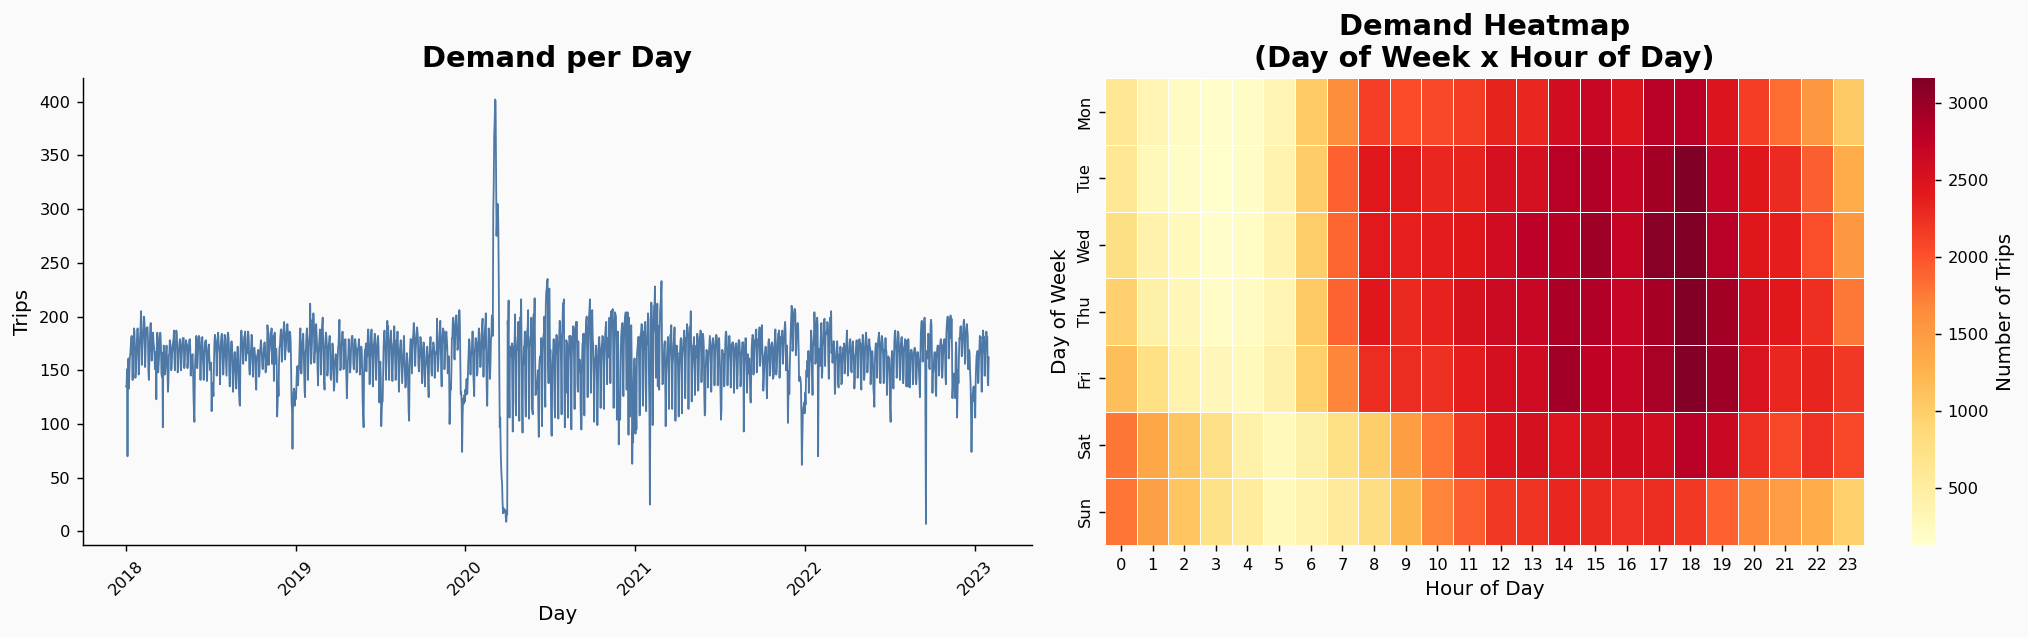

In [41]:
# Overall demand: daily trend + weekly/hourly heatmap
pickup_col = 'tpep_pickup_datetime'

# Core demand KPIs
period_start = df[pickup_col].min()
period_end = df[pickup_col].max()
num_days = (period_end.normalize() - period_start.normalize()).days + 1

total_trips = len(df)
avg_daily_demand = total_trips / num_days
peak_day = df[pickup_col].dt.date.value_counts().idxmax()
peak_day_trips = int(df[pickup_col].dt.date.value_counts().max())

print('Demand Summary')
print(f"- Total trips: {total_trips:,}")
print(f"- Coverage period: {period_start:%Y-%m-%d} to {period_end:%Y-%m-%d}")
print(f"- Average daily demand: {avg_daily_demand:,.1f} trips/day")
print(f"- Peak day: {peak_day} ({peak_day_trips:,} trips)")

# 1) Demand per day (line)
daily_demand = (
    df.set_index(pickup_col)
      .resample('D')
      .size()
      .rename('trips')
      .reset_index()
)

# 2) Demand heatmap by Day of Week x Hour of Day
heatmap_df = (
    df.groupby(['pickup_dow', 'pickup_hour'])
      .size()
      .unstack(fill_value=0)
      .reindex(index=range(7), columns=range(24), fill_value=0)
)
heatmap_df.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(
    daily_demand[pickup_col],
    daily_demand['trips'],
    linewidth=1,
    color=PALETTE[0]
)
axes[0].set_title('Demand per Day', fontsize=16, fontweight='bold')
axes[0].set_xlabel('Day')
axes[0].set_ylabel('Trips')
axes[0].tick_params(axis='x', rotation=45)

sns.heatmap(
    heatmap_df,
    cmap='YlOrRd',
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'label': 'Number of Trips'},
    ax=axes[1]
)
axes[1].set_title('Demand Heatmap\n(Day of Week x Hour of Day)', fontsize=16, fontweight='bold')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Day of Week')

plt.tight_layout()
plt.show()


- The trend over time seems stable except for around March 2020: some days have much higher volume then it dropped to almost 0. I will analyze this in further details in section 5.2. (Temporal Analysis).
- The hourly profile indicates clear late-afternoon and early-evening intensity, while day-of-week results show stronger demand on weekdays than weekends. 
- Overall, demand is time-dependent, which supports planning driver allocation around weekday evening peaks.

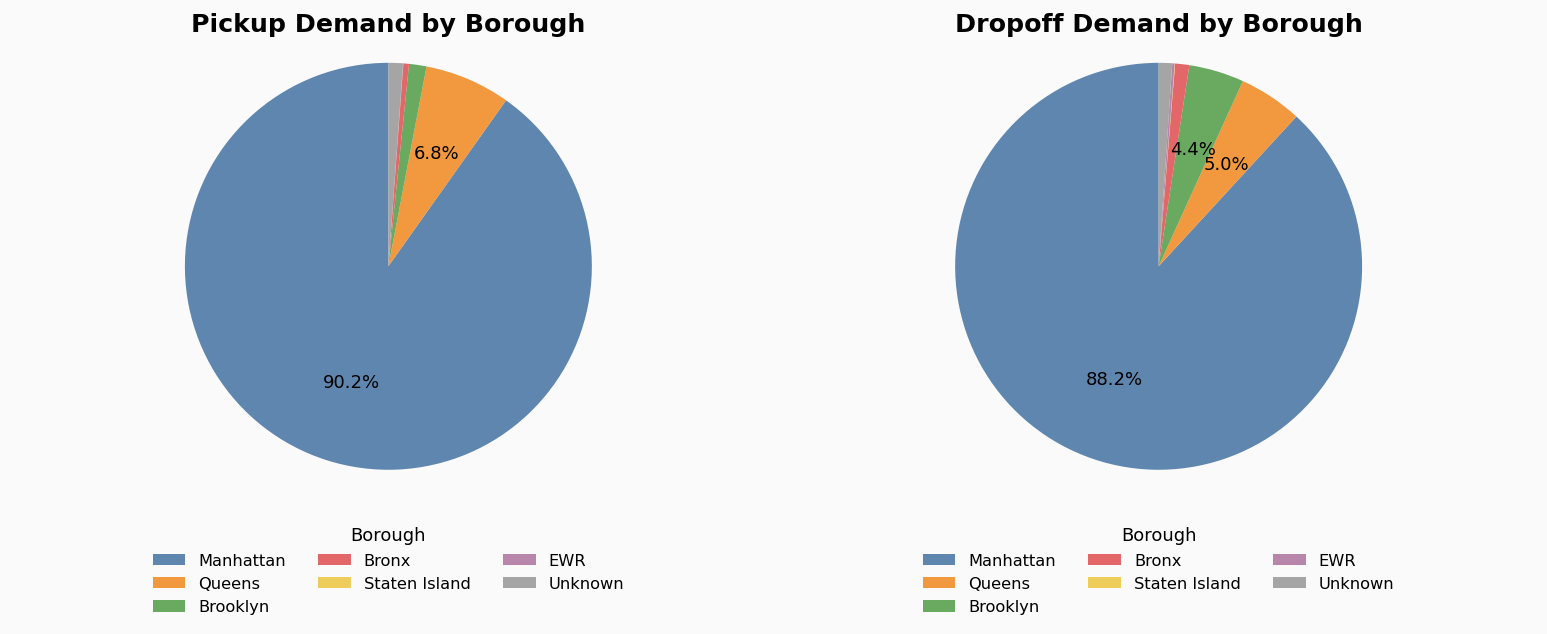

In [42]:
# Demand by borough and top zones
pickup_borough_demand = (
    df['pickup_borough']
    .fillna('Unknown')
    .value_counts()
    .rename_axis('borough')
    .reset_index(name='trips')
)
dropoff_borough_demand = (
    df['dropoff_borough']
    .fillna('Unknown')
    .value_counts()
    .rename_axis('borough')
    .reset_index(name='trips')
)

# Shared borough order + color map to keep both pie charts consistent
borough_order = ['Manhattan', 'Queens', 'Brooklyn', 'Bronx', 'Staten Island', 'EWR', 'Unknown']
borough_color_map = {
    'Manhattan': '#4E79A7',
    'Queens': '#F28E2B',
    'Brooklyn': '#59A14F',
    'Bronx': '#E15759',
    'Staten Island': '#EDC948',
    'EWR': '#B07AA1',
    'Unknown': '#9C9C9C'
}

pickup_borough_pie = (
    pickup_borough_demand.set_index('borough').reindex(borough_order).dropna().reset_index()
)
dropoff_borough_pie = (
    dropoff_borough_demand.set_index('borough').reindex(borough_order).dropna().reset_index()
)

def pct_label(pct):
    return f'{pct:.1f}%' if pct >= 4 else ''

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1) Pickup demand by borough
pickup_colors = [borough_color_map[b] for b in pickup_borough_pie['borough']]
wedges_pickup, _, _ = axes[0].pie(
    pickup_borough_pie['trips'],
    labels=None,
    autopct=pct_label,
    startangle=90,
    colors=pickup_colors,
    wedgeprops={'alpha': 0.9}
 )
axes[0].set_title('Pickup Demand by Borough', fontsize=14, fontweight='bold')
axes[0].axis('equal')
axes[0].legend(
    wedges_pickup,
    pickup_borough_pie['borough'],
    title='Borough',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False,
    fontsize=9
)

# 2) Dropoff demand by borough
dropoff_colors = [borough_color_map[b] for b in dropoff_borough_pie['borough']]
wedges_dropoff, _, _ = axes[1].pie(
    dropoff_borough_pie['trips'],
    labels=None,
    autopct=pct_label,
    startangle=90,
    colors=dropoff_colors,
    wedgeprops={'alpha': 0.9}
 )
axes[1].set_title('Dropoff Demand by Borough', fontsize=14, fontweight='bold')
axes[1].axis('equal')
axes[1].legend(
    wedges_dropoff,
    dropoff_borough_pie['borough'],
    title='Borough',
    loc='upper center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=3,
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.show()

- Manhattan dominates both pickup and dropoff demand.
- Queens and Brooklyn are the second and thrid largest for both. 

[Back to Table of Contents](#table-of-contents)
#### b) Revenue

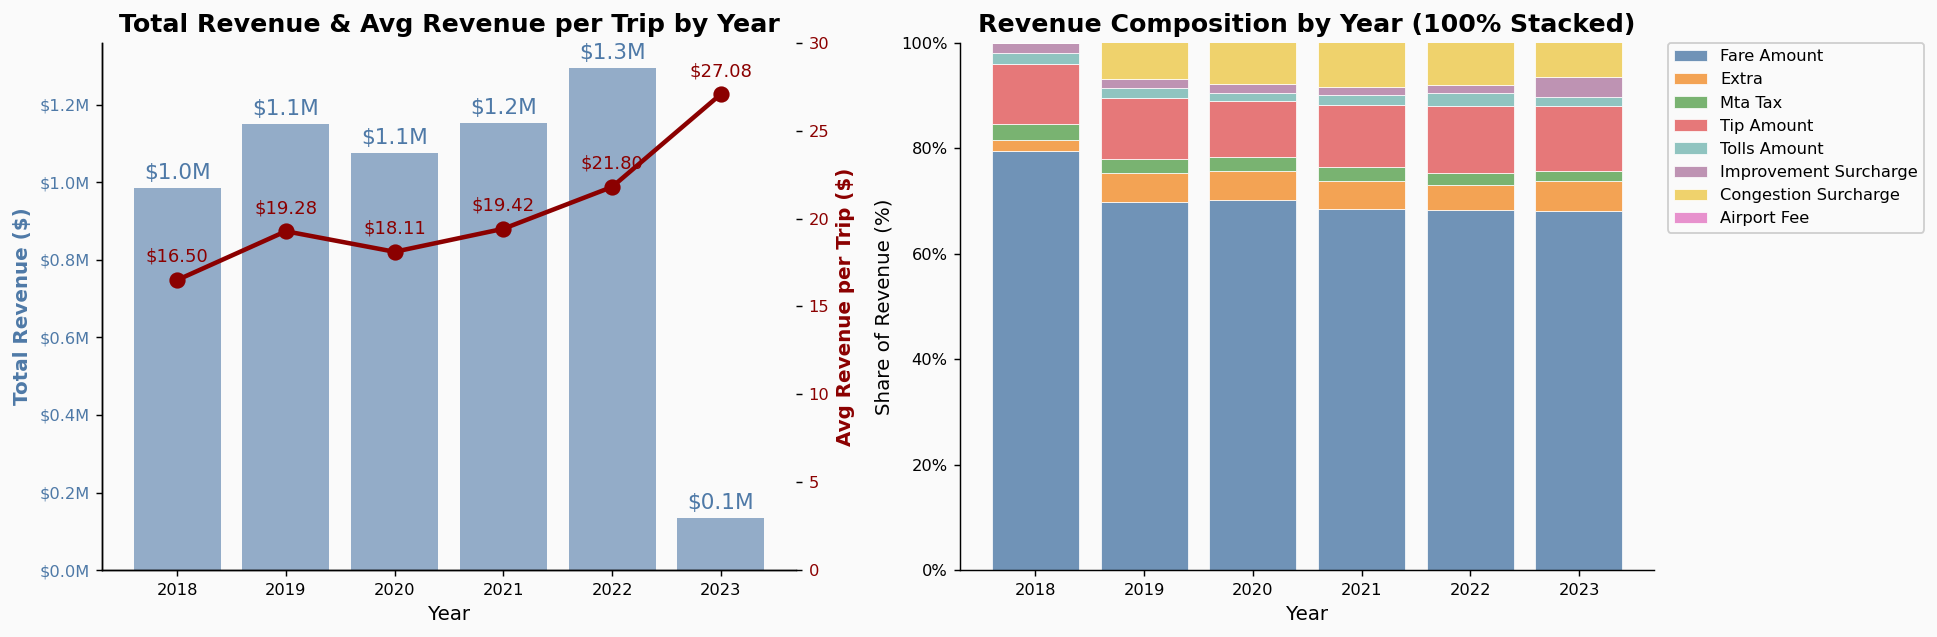

In [43]:
# Revenue analysis by year (combined + stacked)
revenue_year = (
    df.groupby('pickup_year')
    .agg(
        total_revenue=('total_amount', 'sum'),
        avg_revenue=('total_amount', 'mean'),
        trips=('total_amount', 'size'),
        fare_amount=('fare_amount', 'sum'),
        extra=('extra', 'sum'),
        mta_tax=('mta_tax', 'sum'),
        tip_amount=('tip_amount', 'sum'),
        tolls_amount=('tolls_amount', 'sum'),
        improvement_surcharge=('improvement_surcharge', 'sum'),
        congestion_surcharge=('congestion_surcharge', 'sum'),
        airport_fee=('airport_fee', 'sum'),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1) Combined chart: Total Revenue (bars) + Avg Revenue per Trip (line)
ax1 = axes[0]
ax2 = ax1.twinx()

# Total Revenue bars on left y-axis
bars = ax1.bar(
    revenue_year['pickup_year'],
    revenue_year['total_revenue'],
    color=PALETTE[0],
    alpha=0.6,
    label='Total Revenue'
)

# Add value labels for bars
for bar, rev in zip(bars, revenue_year['total_revenue']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        rev + revenue_year['total_revenue'].max() * 0.01,
        f'${rev/1e6:.1f}M',
        ha='center',
        va='bottom',
        fontsize=12,
        color=PALETTE[0]
    )

ax1.set_ylabel('Total Revenue ($)', color=PALETTE[0], fontweight='bold')
ax1.tick_params(axis='y', labelcolor=PALETTE[0])
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

# Avg Revenue per Trip line on right y-axis
line = ax2.plot(
    revenue_year['pickup_year'],
    revenue_year['avg_revenue'],
    marker='o',
    linewidth=2.5,
    markersize=8,
    color='#8B0000',
    label='Avg Revenue per Trip'
)
ax2.set_ylabel('Avg Revenue per Trip ($)', color='#8B0000', fontweight='bold')
ax2.tick_params(axis='y', labelcolor='#8B0000')
ax2.set_ylim(0, 30)

# Add value labels for line
for year, avg_rev in zip(revenue_year['pickup_year'], revenue_year['avg_revenue']):
    ax2.text(year, avg_rev + 0.8, f'${avg_rev:.2f}', ha='center', va='bottom', fontsize=10, color='#8B0000')

ax1.set_xlabel('Year')
ax1.set_title('Total Revenue & Avg Revenue per Trip by Year', fontsize=14, fontweight='bold')

# 2) 100% stacked bar chart of revenue components
fare_components = ['fare_amount', 'extra', 'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge', 'congestion_surcharge', 'airport_fee']
component_colors = PALETTE + ['#e377c2']

component_pct = revenue_year[fare_components].div(revenue_year['total_revenue'], axis=0) * 100

bottom = np.zeros(len(revenue_year))
for i, component in enumerate(fare_components):
    axes[1].bar(
        revenue_year['pickup_year'],
        component_pct[component],
        bottom=bottom,
        label=component.replace('_', ' ').title(),
        color=component_colors[i],
        alpha=0.8,
        edgecolor='white',
        linewidth=0.5
    )
    bottom += component_pct[component].values

axes[1].set_title('Revenue Composition by Year (100% Stacked)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Share of Revenue (%)')
axes[1].set_ylim(0, 100)
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0.0, fontsize=9, framealpha=0.95)

plt.tight_layout()
plt.show()

Average revenue per trip also trends upward and peaks in 2023. Revenue composition remains fare-led, with tip amount as the second-largest contributor. Congestion surcharge seems to be introduced in 2019.

[Back to Table of Contents](#table-of-contents)
#### c) Payment & Tipping

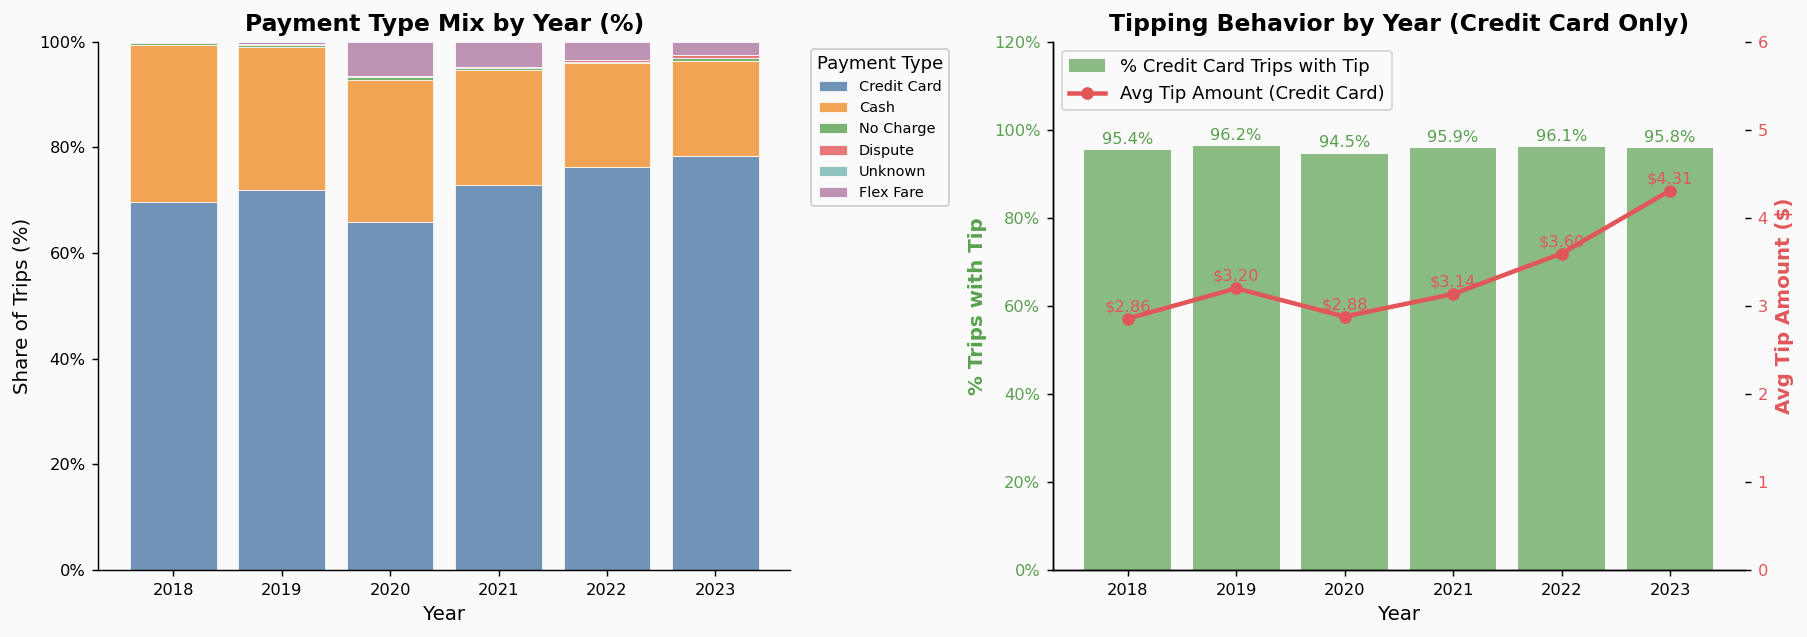

In [44]:
# Payment & Tipping overview: payment mix and tipping behavior by year

payment_col = 'payment_label'

# 1) Stacked bar chart: % payment type over years
payment_year = (
    df.groupby(['pickup_year', payment_col])
    .size()
    .reset_index(name='trips')
)
payment_year['year_total'] = payment_year.groupby('pickup_year')['trips'].transform('sum')
payment_year['trip_pct'] = payment_year['trips'] / payment_year['year_total'] * 100

payment_pivot = (
    payment_year
    .pivot(index='pickup_year', columns=payment_col, values='trip_pct')
    .fillna(0)
)

# Keep a stable order so major payment types appear first
preferred_order = ['Credit Card', 'Cash', 'No Charge', 'Dispute', 'Unknown', 'Voided', 'Flex Fare', 'Other']
ordered_cols = [c for c in preferred_order if c in payment_pivot.columns] + [c for c in payment_pivot.columns if c not in preferred_order]
payment_pivot = payment_pivot[ordered_cols]

# 2) Combined bar-line: % credit card trips with tip + avg tip amount (credit card only)
cc_df = df[df[payment_col] == 'Credit Card'].copy()

tip_year = (
    cc_df.assign(has_tip=cc_df['tip_amount'] > 0)
    .groupby('pickup_year')
    .agg(
        trip_count=('total_amount', 'size'),
        tip_trip_count=('has_tip', 'sum'),
        avg_tip_amount=('tip_amount', lambda s: s[s > 0].mean() if (s > 0).any() else 0)
    )
    .reset_index()
)
tip_year['tip_trip_pct'] = tip_year['tip_trip_count'] / tip_year['trip_count'] * 100

# Plot both charts
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left chart: stacked payment mix
bottom = np.zeros(len(payment_pivot.index))
for i, col in enumerate(payment_pivot.columns):
    axes[0].bar(
        payment_pivot.index,
        payment_pivot[col].values,
        bottom=bottom,
        label=col,
        color=PALETTE[i % len(PALETTE)],
        alpha=0.8,
        edgecolor='white',
        linewidth=0.5
    )
    bottom += payment_pivot[col].values

axes[0].set_title('Payment Type Mix by Year (%)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Share of Trips (%)')
axes[0].set_ylim(0, 100)
axes[0].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[0].legend(title='Payment Type', loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=8, framealpha=0.95)

# Right chart: bar (% credit card trips with tip) + line (avg tip amount)
ax1 = axes[1]
ax2 = ax1.twinx()

bars = ax1.bar(
    tip_year['pickup_year'],
    tip_year['tip_trip_pct'],
    color=PALETTE[2],
    alpha=0.7,
    label='% Credit Card Trips with Tip'
)
line = ax2.plot(
    tip_year['pickup_year'],
    tip_year['avg_tip_amount'],
    color=PALETTE[3],
    marker='o',
    linewidth=2.5,
    label='Avg Tip Amount (Credit Card)'
)

for bar, pct in zip(bars, tip_year['tip_trip_pct']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f'{pct:.1f}%',
        ha='center',
        va='bottom',
        fontsize=9,
        color=PALETTE[2]
    )
for year, avg_tip in zip(tip_year['pickup_year'], tip_year['avg_tip_amount']):
    ax2.text(year, avg_tip + 0.05, f'${avg_tip:.2f}', ha='center', va='bottom', fontsize=9, color=PALETTE[3])

ax1.set_title('Tipping Behavior by Year (Credit Card Only)', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('% Trips with Tip', color=PALETTE[2], fontweight='bold')
ax1.tick_params(axis='y', labelcolor=PALETTE[2])
ax1.yaxis.set_major_formatter(mticker.PercentFormatter())
ax1.set_ylim(0, 120)

ax2.set_ylabel('Avg Tip Amount ($)', color=PALETTE[3], fontweight='bold')
ax2.tick_params(axis='y', labelcolor=PALETTE[3])
ax2.set_ylim(0, 6)

# Combined legend for right chart
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()

- Card payments dominate across all years and increase over time, while cash share generally declines.
- The share of tipped trips remained stable at around 95%.
- Average tip amount also trends upward (roughly 2.86 to 4.31 USD), with a dip in 2020 and strong growth afterward.
- Overall, payment behavior is becoming more cashless and tip amount is improving over time.


[Back to Table of Contents](#table-of-contents)
#### d) Operational Efficiency

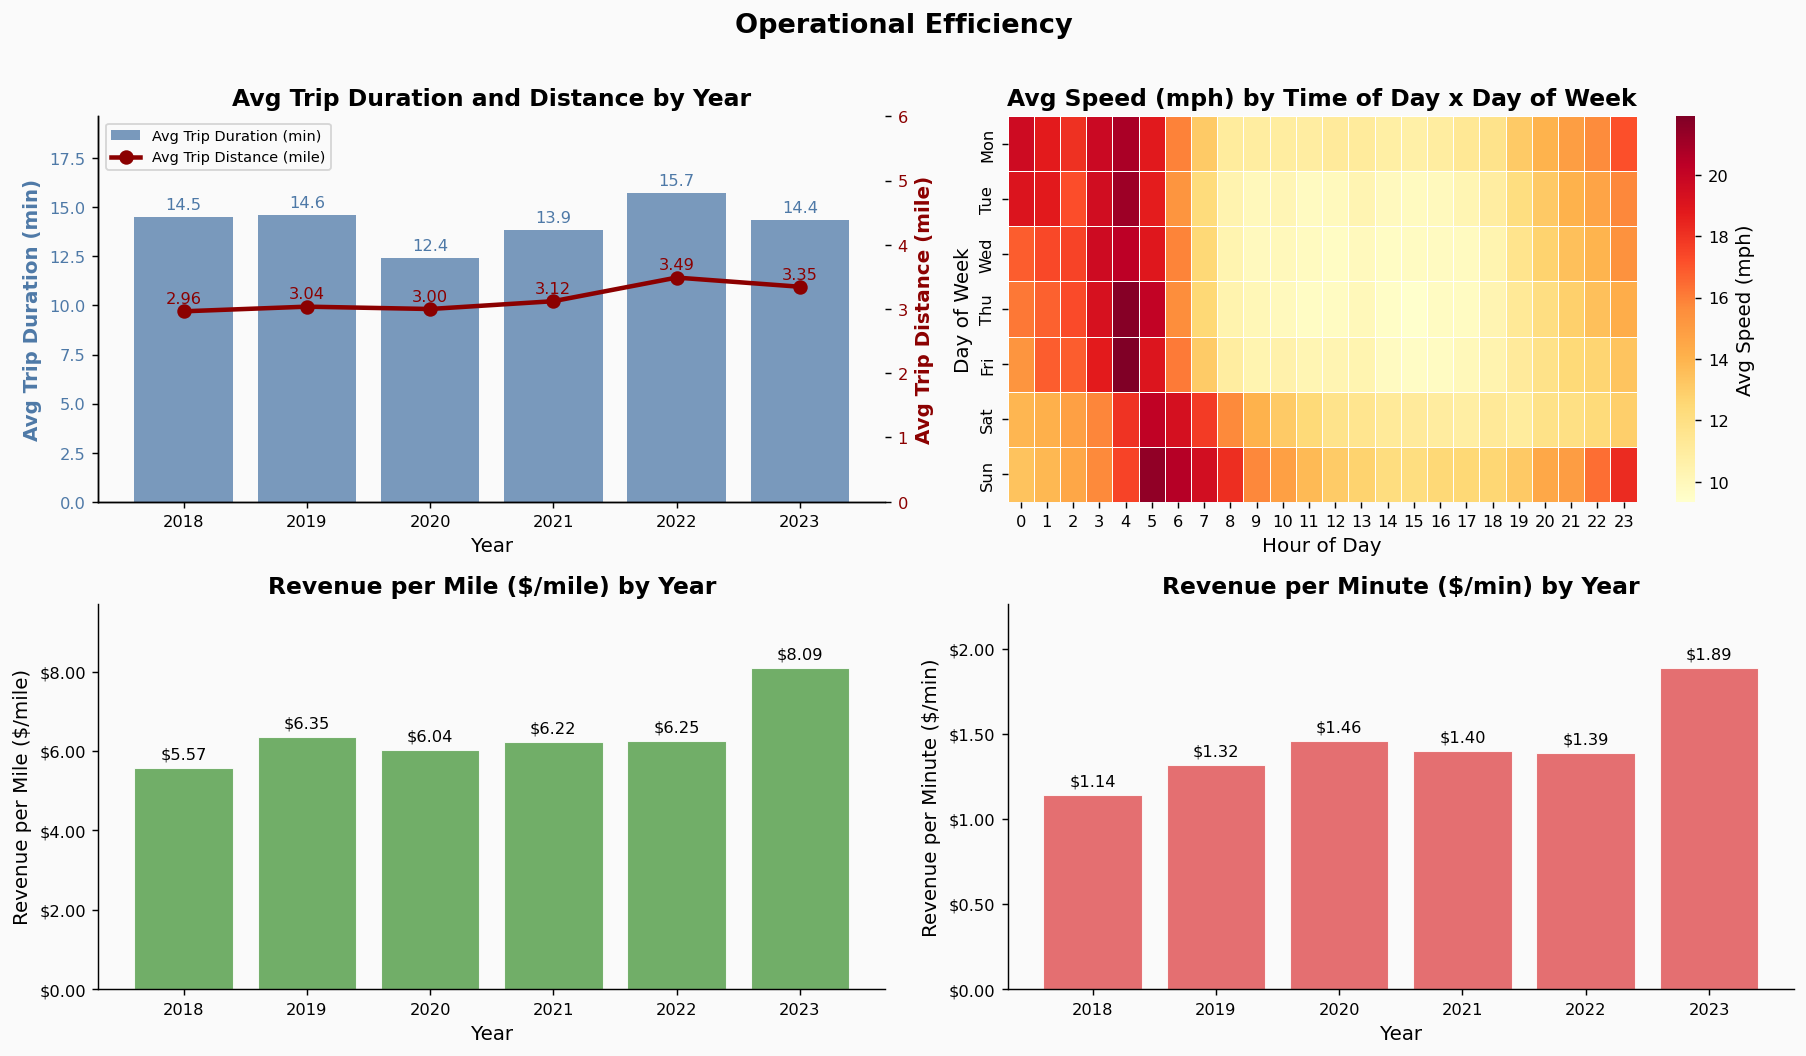

In [45]:
# Operational Efficiency: trip duration, speed patterns, and revenue efficiency
op_df = df.copy()

# Aggregate by year
operational_year = (
    op_df.groupby('pickup_year')
    .agg(
        avg_trip_duration=('trip_duration_min', 'mean'),
        avg_trip_distance=('trip_distance', 'mean'),
        total_revenue=('total_amount', 'sum'),
        total_distance=('trip_distance', 'sum'),
        total_duration_min=('trip_duration_min', 'sum')
    )
    .reset_index()
)
operational_year['revenue_per_mile'] = np.where(
    operational_year['total_distance'] > 0,
    operational_year['total_revenue'] / operational_year['total_distance'],
    np.nan
)
operational_year['revenue_per_minute'] = np.where(
    operational_year['total_duration_min'] > 0,
    operational_year['total_revenue'] / operational_year['total_duration_min'],
    np.nan
)

# Speed heatmap: avg speed by time of day x day of week
speed_heatmap = (
    op_df.groupby(['pickup_dow', 'pickup_hour'])['avg_speed_mph']
    .mean()
    .unstack()
    .reindex(index=range(7), columns=range(24))
)
speed_heatmap.index = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# ── Top-left: Avg Trip Duration (bar) + Avg Trip Distance (line) ───────────────
ax1 = axes[0, 0]
ax1_r = ax1.twinx()

bars = ax1.bar(
    operational_year['pickup_year'],
    operational_year['avg_trip_duration'],
    color=PALETTE[0], alpha=0.75, label='Avg Trip Duration (min)'
)
line = ax1_r.plot(
    operational_year['pickup_year'],
    operational_year['avg_trip_distance'],
    color='#8B0000', marker='o', linewidth=2.5, markersize=7,
    label='Avg Trip Distance (mile)'
)

for bar, duration in zip(bars, operational_year['avg_trip_duration']):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.25,
             f'{duration:.1f}', ha='center', va='bottom', fontsize=9, color=PALETTE[0])
for year, distance in zip(operational_year['pickup_year'], operational_year['avg_trip_distance']):
    ax1_r.text(year, distance + 0.08, f'{distance:.2f}',
               ha='center', va='bottom', fontsize=9, color='#8B0000')

ax1.set_title('Avg Trip Duration and Distance by Year', fontweight='bold')
ax1.set_xlabel('Year')
ax1.set_ylabel('Avg Trip Duration (min)', color=PALETTE[0], fontweight='bold')
ax1.tick_params(axis='y', labelcolor=PALETTE[0])
ax1.set_ylim(0, operational_year['avg_trip_duration'].max() * 1.25)
ax1_r.set_ylabel('Avg Trip Distance (mile)', color='#8B0000', fontweight='bold')
ax1_r.tick_params(axis='y', labelcolor='#8B0000')
ax1_r.set_ylim(0, 6)

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax1_r.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc='upper left', fontsize=8)

# ── Top-right: Avg Speed heatmap ───────────────────────────────────────────────
ax2 = axes[0, 1]
sns.heatmap(
    speed_heatmap, ax=ax2, cmap='YlOrRd',
    linewidths=0.3, linecolor='white',
    cbar_kws={'label': 'Avg Speed (mph)'}
)
ax2.set_title('Avg Speed (mph) by Time of Day x Day of Week', fontweight='bold')
ax2.set_xlabel('Hour of Day')
ax2.set_ylabel('Day of Week')

# ── Bottom-left: Revenue per Mile by Year ──────────────────────────────────────
ax3 = axes[1, 0]
bar_rpm = ax3.bar(
    operational_year['pickup_year'],
    operational_year['revenue_per_mile'],
    color=PALETTE[2], alpha=0.85, edgecolor='white', linewidth=0.6
)
for bar, rpm in zip(bar_rpm, operational_year['revenue_per_mile']):
    ax3.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + operational_year['revenue_per_mile'].max() * 0.02,
             f'${rpm:.2f}', ha='center', va='bottom', fontsize=9)
ax3.set_title('Revenue per Mile ($/mile) by Year', fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Revenue per Mile ($/mile)')
ax3.set_ylim(0, operational_year['revenue_per_mile'].max() * 1.2)
ax3.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:.2f}'))

# ── Bottom-right: Revenue per Minute by Year ───────────────────────────────────
ax4 = axes[1, 1]
bar_rpm2 = ax4.bar(
    operational_year['pickup_year'],
    operational_year['revenue_per_minute'],
    color=PALETTE[3], alpha=0.85, edgecolor='white', linewidth=0.6
)
for bar, rpm in zip(bar_rpm2, operational_year['revenue_per_minute']):
    ax4.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + operational_year['revenue_per_minute'].max() * 0.02,
             f'${rpm:.2f}', ha='center', va='bottom', fontsize=9)
ax4.set_title('Revenue per Minute ($/min) by Year', fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Revenue per Minute ($/min)')
ax4.set_ylim(0, operational_year['revenue_per_minute'].max() * 1.2)
ax4.yaxis.set_major_formatter(mticker.StrMethodFormatter('${x:.2f}'))

plt.suptitle('Operational Efficiency', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


The operational-efficiency charts show four related views of trip performance.

- Average trip distance was roughly stable between 3 and 3.5 mile across the years, while average trip duration slightly dipped in 2020.
- The heatmap shows clear time-of-day and day-of-week patterns, with faster speeds after midnight and slower speeds during office hours on weekdays. On weekends, the highest speed is in the early morning between 5am and 7am.
- Revenue per mile and per minute improve over time and reach their highest level in 2023.


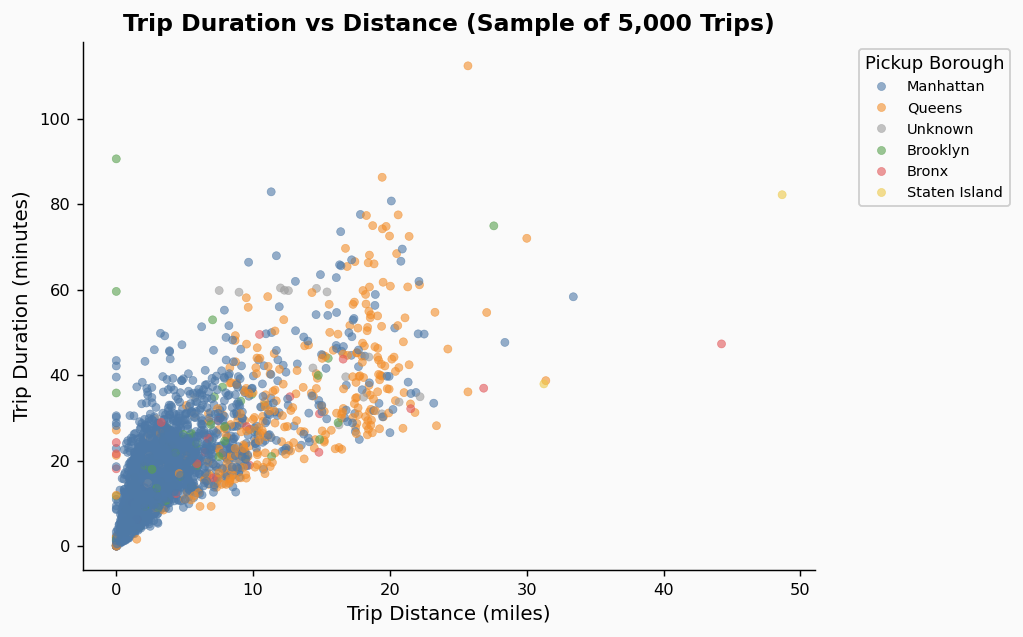

In [46]:
# Show scatter plot of trip duration vs trip distance, colored by pickup borough
# sampling 5000 data points for visibility and cap 90% of distance and duration to avoid extreme outliers dominating the plot
scatter_df = df.copy()
scatter_df = scatter_df.sample(n=5000, random_state=42)
scatter_df['pickup_borough'] = scatter_df['pickup_borough'].fillna('Unknown')
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=scatter_df,
    x='trip_distance',
    y='trip_duration_min',
    hue='pickup_borough',
    palette=borough_color_map,
    alpha=0.6,
    edgecolor=None,
    s=20
)
plt.title('Trip Duration vs Distance (Sample of 5,000 Trips)', fontweight='bold')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Trip Duration (minutes)')
plt.legend(title='Pickup Borough', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8, framealpha=0.95)
plt.tight_layout()
plt.show()

There is a positive correlation between trip distance and duration, as expected. Trips originating from Manhattan tend to cluster towards shorter distances and durations, while trips from outer boroughs like Queens and Brooklyn show a wider spread, including longer trips. This reflects the geographic layout of NYC, where Manhattan has many short intra-borough trips, while outer boroughs have more long-distance trips to/from Manhattan and other areas.

In [47]:
# Statistics Spearman test: correlation between trip distance and duration, by borough
corr_df = df.copy()
corr_df['pickup_borough'] = corr_df['pickup_borough'].fillna('Unknown')
# Show correlation results with p values
from scipy.stats import spearmanr
corr_results = []
for borough in corr_df['pickup_borough'].unique():
    subset = corr_df[corr_df['pickup_borough'] == borough]
    if len(subset) > 1:
        corr, p_value = spearmanr(subset['trip_distance'], subset['trip_duration_min'])
        corr_results.append({'pickup_borough': borough, 'spearman_corr': corr, 'p_value': p_value})
corr_results = pd.DataFrame(corr_results)
print('Spearman Correlation between Trip Distance and Duration by Pickup Borough:')
print(corr_results.to_string(index=False))

Spearman Correlation between Trip Distance and Duration by Pickup Borough:
pickup_borough  spearman_corr       p_value
     Manhattan       0.821137  0.000000e+00
        Queens       0.768543  0.000000e+00
      Brooklyn       0.743788  0.000000e+00
       Unknown       0.888864  0.000000e+00
         Bronx       0.697323 1.759769e-197
 Staten Island       0.758412  4.934703e-07
           EWR       0.448677  4.722640e-03


Spearman test is used instead of Pearson due to non-normal distributions of the variables. The results show statistically significant positive correlation (p < 0.001) across all boroughs, with Spearman coefficients from 0.7 and above (except for EWR), indicating a strong relationship between distance and duration regardless of pickup location.

[Back to Table of Contents](#table-of-contents)
### 5.2. Temporal Analysis (L1)
##### Monthly seasonality

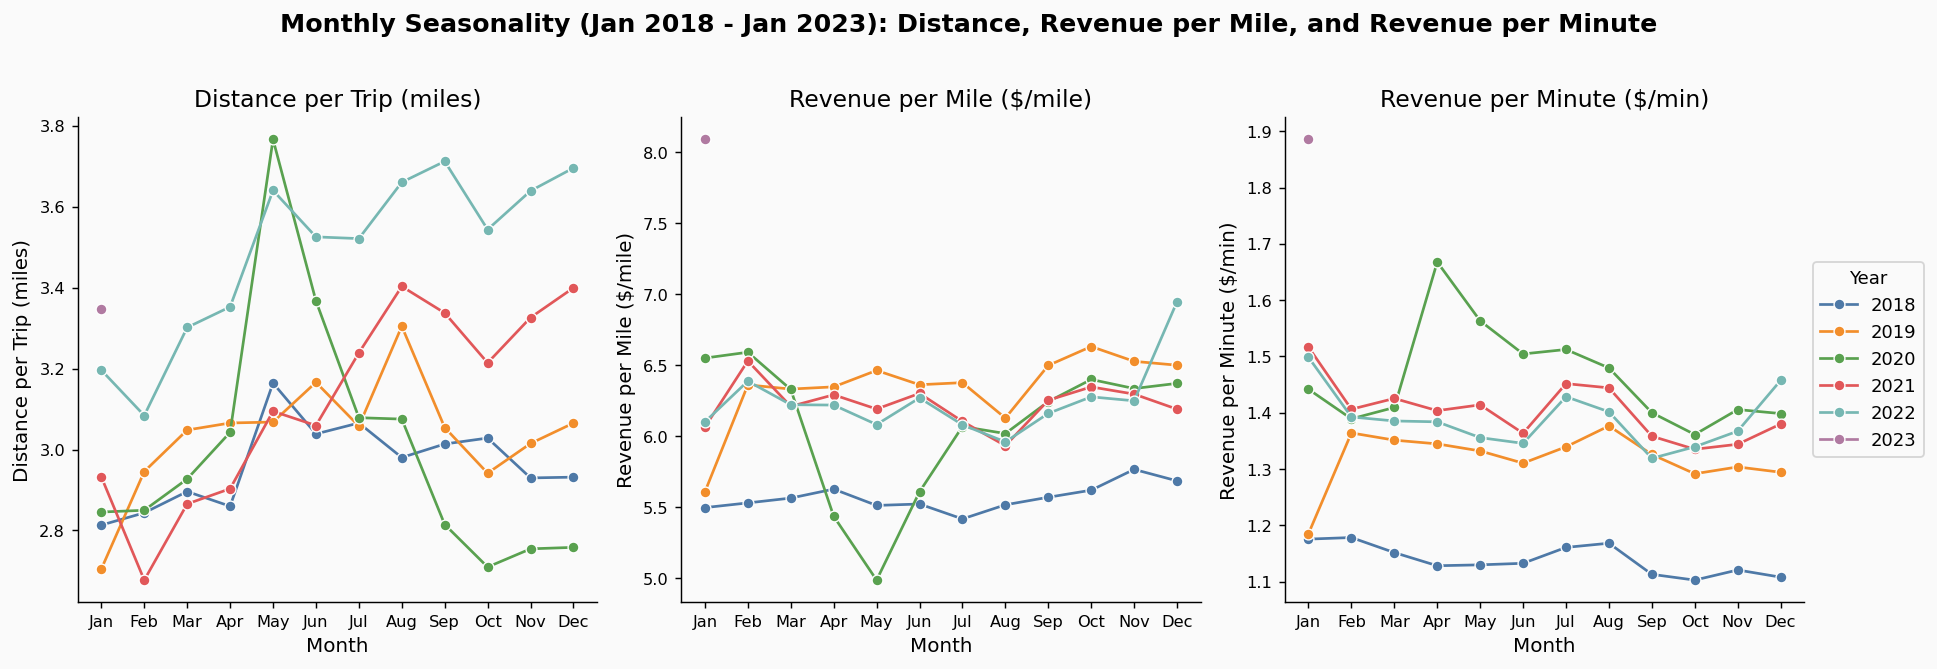

In [48]:
# -- Monthly seasonality across years --
monthly = df.groupby(['pickup_year', 'pickup_month']).agg(
    avg_distance=('trip_distance', 'mean'),
    total_revenue=('total_amount', 'sum'),
    total_distance=('trip_distance', 'sum'),
    total_duration=('trip_duration_min', 'sum')
).reset_index()
monthly['revenue_per_mile'] = np.where(
    monthly['total_distance'] > 0,
    monthly['total_revenue'] / monthly['total_distance'],
    np.nan
)
monthly['revenue_per_minute'] = np.where(
    monthly['total_duration'] > 0,
    monthly['total_revenue'] / monthly['total_duration'],
    np.nan
)

# Plot monthly distance, revenue per mile, and revenue per minute across years
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Monthly Seasonality (Jan 2018 - Jan 2023): Distance, Revenue per Mile, and Revenue per Minute', fontsize=14, fontweight='bold', y=1.02)
months_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
for ax, col, label in zip(
    axes,
    ['avg_distance', 'revenue_per_mile', 'revenue_per_minute'],
    ['Distance per Trip (miles)', 'Revenue per Mile ($/mile)', 'Revenue per Minute ($/min)']
):
    sns.lineplot(x='pickup_month', y=col, hue='pickup_year', data=monthly, marker='o', ax=ax, palette=PALETTE)
    ax.set_xlabel('Month')
    ax.set_ylabel(label)
    ax.set_title(label)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(months_labels)
    if col == 'revenue_per_minute':
        ax.legend(title='Year', loc='center left', bbox_to_anchor=(1, 0.5))
    else:
        ax.get_legend().remove()

plt.tight_layout()
plt.show()


**Distance**:
Trip distance were around 3 miles from 2018 to mid-2021, with a sharp peak in May 2020. It gradually went up since late 2021.

**Revenue per Mile**:
Revenue per Mile started at 5.5 USD in 2018, then remained almost unchanged between 6.0 - 6.5 USD over 2019-2022. The dip in May 2020 correlate with longer trip distance. Finally, efficiency increased significantly to 8.0 USD in Jan 2023.

**Revenue per Minute**:
Revenue per Minute also increased over time with tremendous improvment in 2023 to 1.9 USD. However, April 2020 saw a large spike, which is opposite to Revenue per Mile. This proves that the trips during the start of Covid period saw large disruption in efficiency.

##### Heatmap by Day of Month x Month

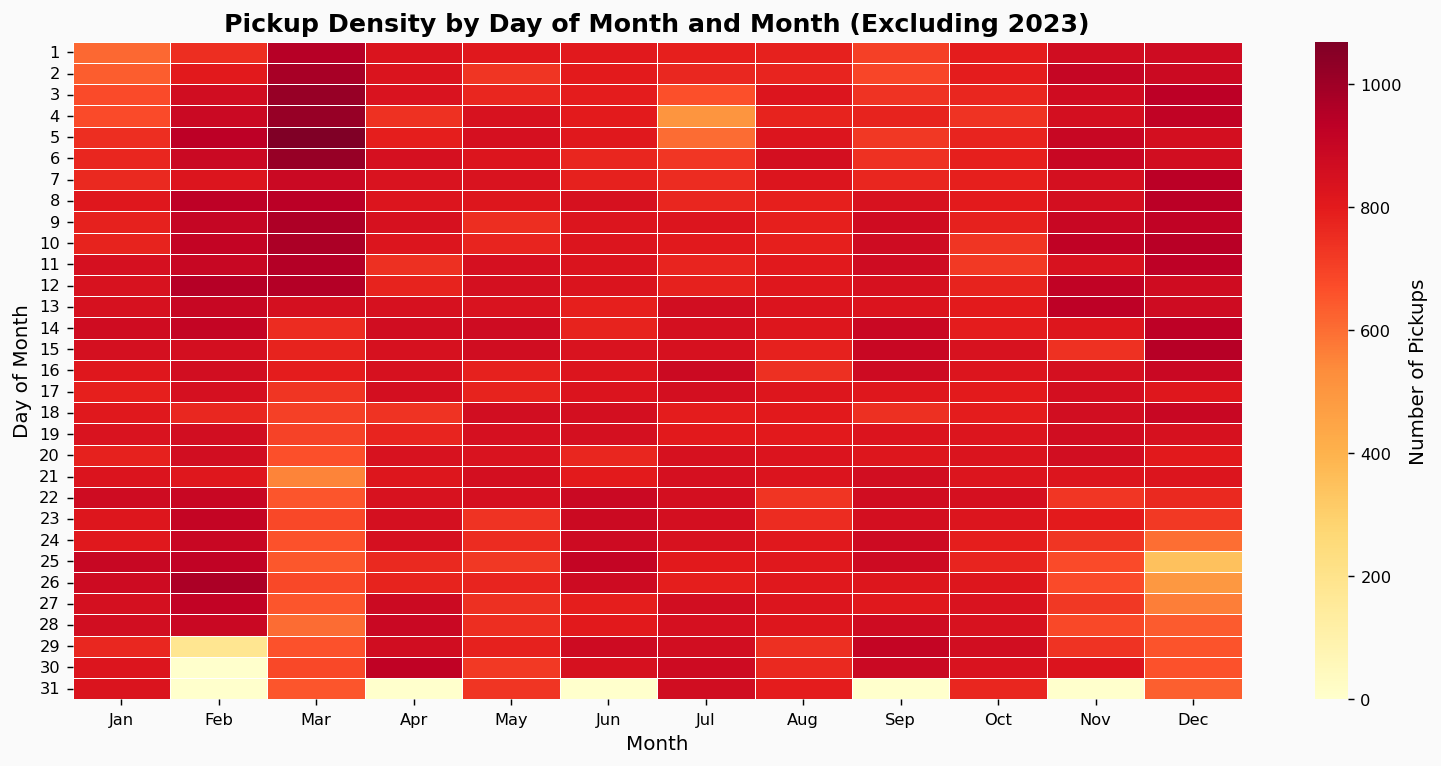

In [49]:
# Heatmap by Day of Month x Month , excluding 2023
pickup_candidates = [
    'tpep_pickup_datetime',
    'pickup_datetime',
    'lpep_pickup_datetime',
    'pickup_dt'
]

pickup_col = next((c for c in pickup_candidates if c in df.columns), None)
if pickup_col is None:
    raise ValueError(
        f"No pickup datetime column found. Tried: {pickup_candidates}"
    )

temp_df = df[[pickup_col]].copy()
temp_df[pickup_col] = pd.to_datetime(temp_df[pickup_col], errors='coerce')
temp_df = temp_df.dropna(subset=[pickup_col])

# Exclude all records from 2023
temp_df = temp_df[temp_df[pickup_col].dt.year != 2023]
if temp_df.empty:
    raise ValueError("No data left after excluding year 2023.")

# Right panel: heatmap by day of month x month
temp_df['month'] = temp_df[pickup_col].dt.month
temp_df['day'] = temp_df[pickup_col].dt.day

heatmap_data = (
    temp_df.groupby(['day', 'month'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(1, 32), columns=range(1, 13), fill_value=0)
)

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
heatmap_data.columns = month_labels

plt.figure(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'Number of Pickups'}
)
plt.title('Pickup Density by Day of Month and Month (Excluding 2023)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Day of Month')
plt.tight_layout()
plt.show()

2023 was excluded from the heatmap to avoid skewing the color scale due to partial data for that year.

The distribution accross the dates looks fairly even.
- Some lower demand during the holiday periods in Dec (Christmas) and on 4 July (US Independence Day)
- Early March has higher demand, which will be studied next.

##### Heatmap by Day of Month x Year (for March data only)

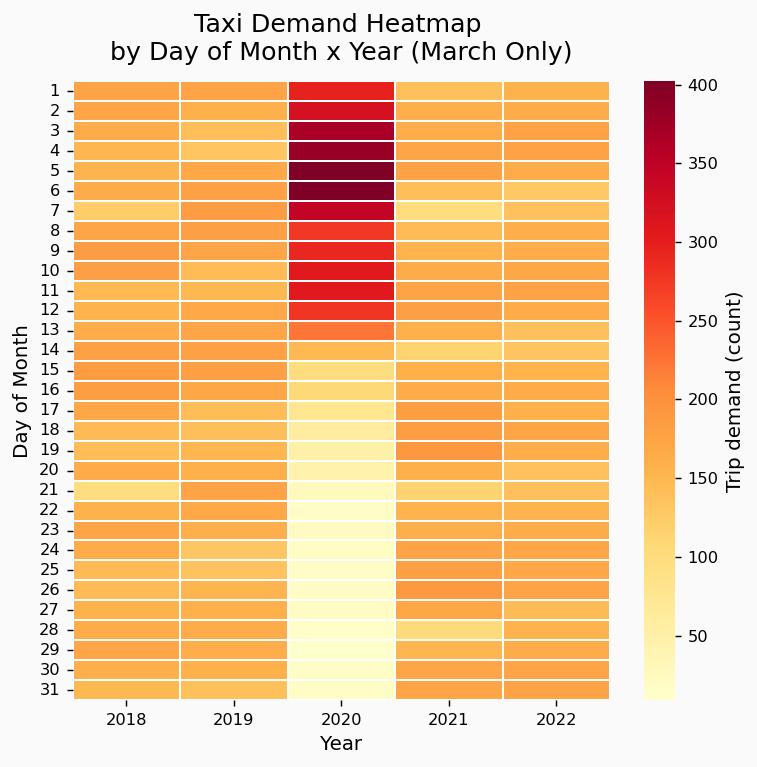

In [50]:
# Heatmap: demand by Day of Month (rows) x Year (columns), March only
pickup_candidates = [
    'tpep_pickup_datetime',
    'pickup_datetime',
    'lpep_pickup_datetime',
    'pickup_dt'
]

pickup_col = next((c for c in pickup_candidates if c in df.columns), None)
if pickup_col is None:
    raise ValueError(f"No pickup datetime column found. Tried: {pickup_candidates}")

temp_df = df[[pickup_col]].copy()
temp_df[pickup_col] = pd.to_datetime(temp_df[pickup_col], errors='coerce')
temp_df = temp_df.dropna(subset=[pickup_col])

# Keep March records only
temp_df = temp_df[temp_df[pickup_col].dt.month == 3]
if temp_df.empty:
    raise ValueError("No March data available for heatmap.")

temp_df['year'] = temp_df[pickup_col].dt.year
temp_df['day'] = temp_df[pickup_col].dt.day

year_order = sorted(temp_df['year'].unique())

heatmap_data = (
    temp_df.groupby(['day', 'year'])
    .size()
    .unstack(fill_value=0)
    .reindex(index=range(1, 32), fill_value=0)
    .reindex(columns=year_order, fill_value=0)
)

plt.figure(figsize=(6, 6))
sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    linewidths=0.2,
    linecolor='white',
    cbar_kws={'label': 'Trip demand (count)'}
)
plt.title('Taxi Demand Heatmap \nby Day of Month x Year (March Only)', fontsize=14, pad=12)
plt.xlabel('Year')
plt.ylabel('Day of Month')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

From demand distribution for March across all years, we see that 2020 is the outlier: higher demand in early March 2020 compared to the rest of that month.

This correlates with the timing of Covid: few people took taxis in the 2nd half of March 2020. Because the data is capped at 5k per month, most of the records for March 2020 are from the earlier days of the month.

[Back to Table of Contents](#table-of-contents)
##### Heatmap by Time of Day x Day of Week: Distance and Efficiency

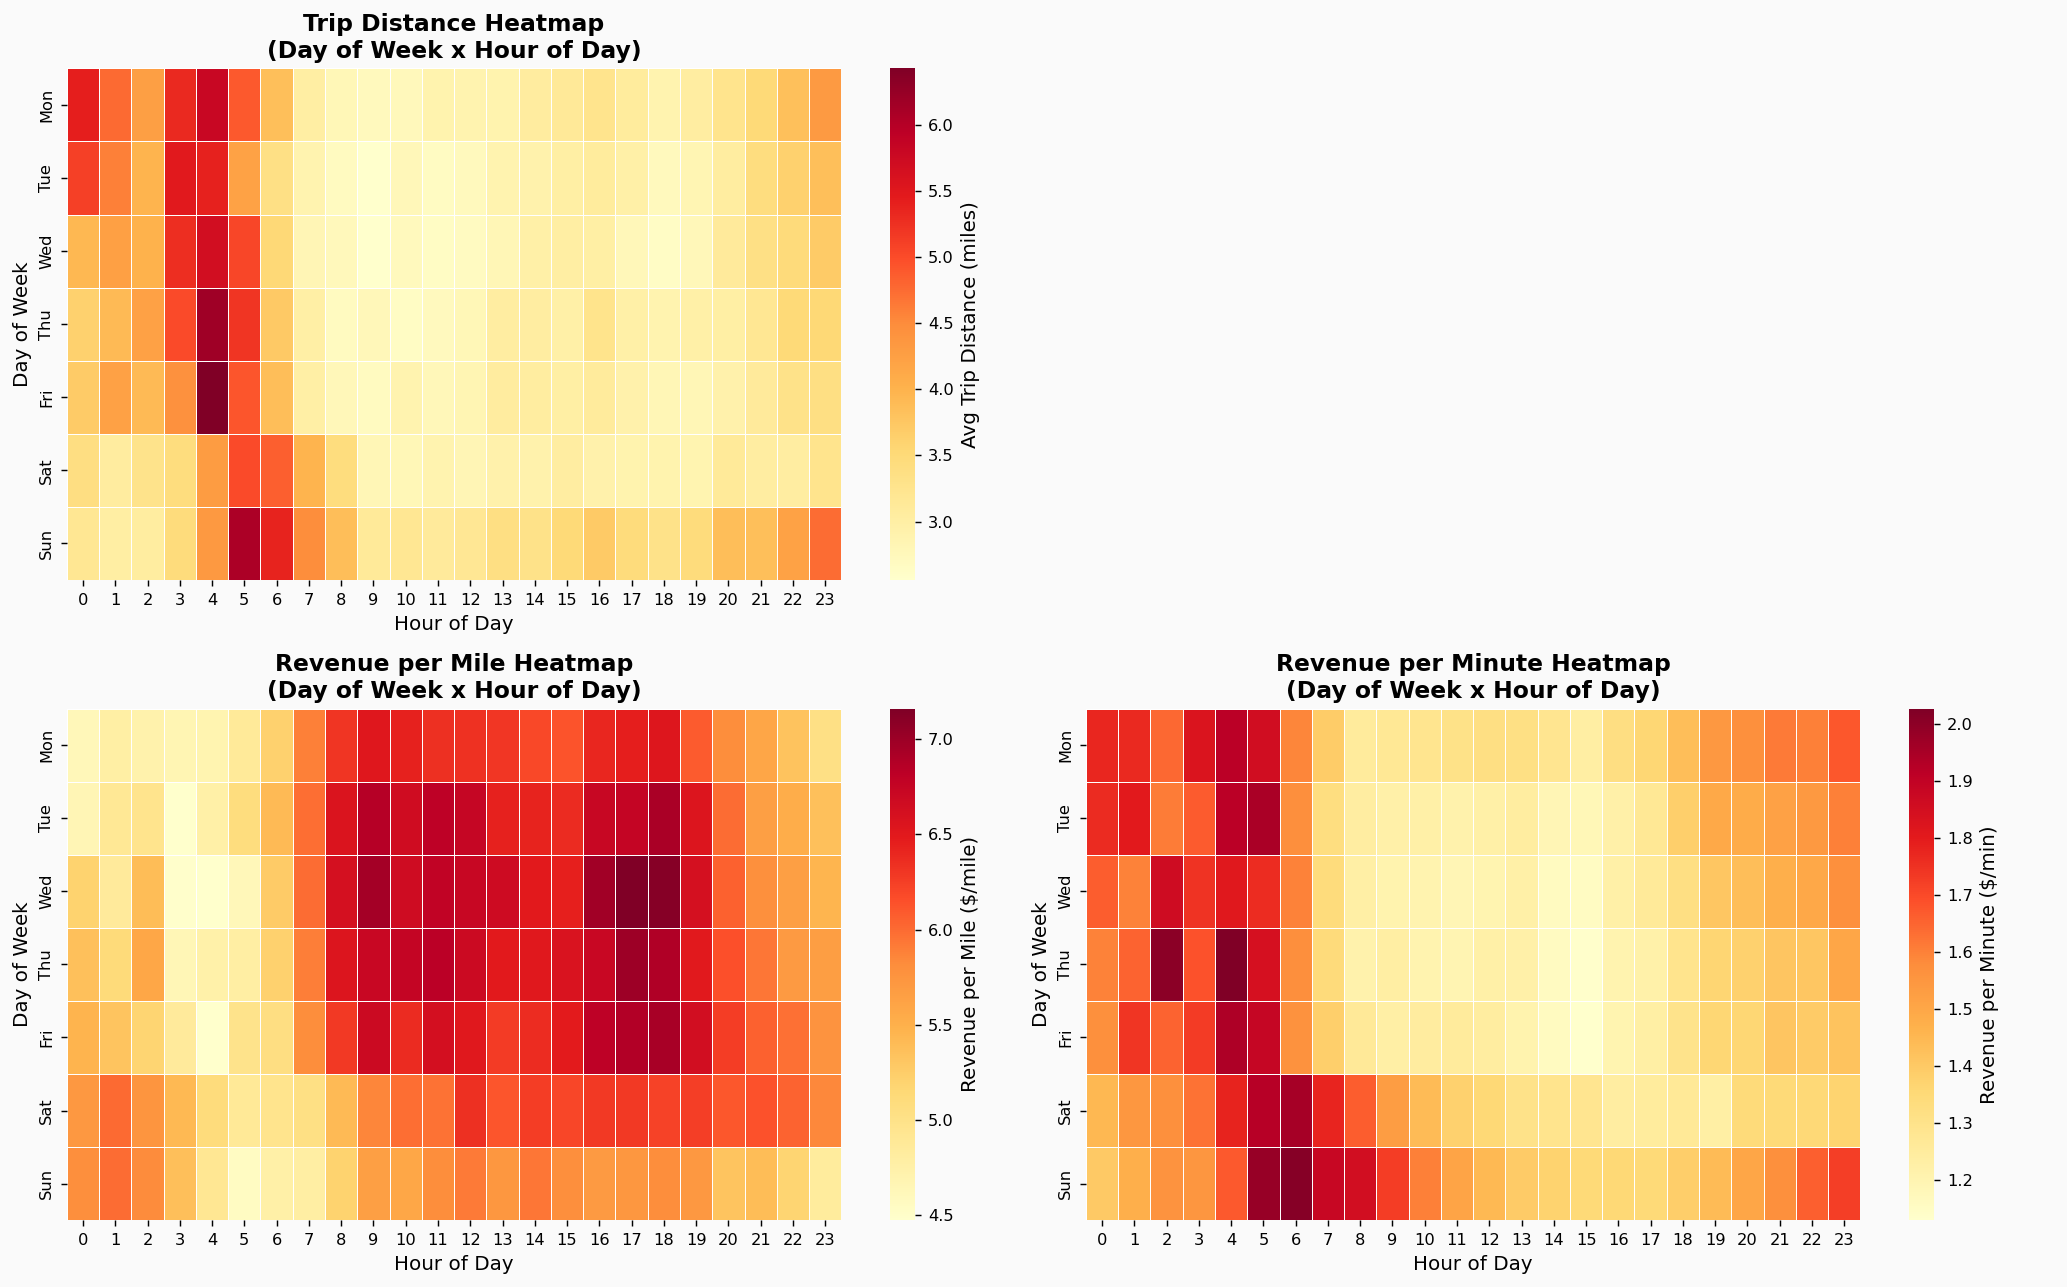

In [51]:
# -- Heatmaps: Day-of-week x Hour-of-day for Trip Distance, Revenue per Mile, and Revenue per Minute --
pivot_dist = (
    df.groupby(['pickup_dow', 'pickup_hour'])['trip_distance']
      .mean()
      .unstack(fill_value=0)
      .reindex(index=range(7), columns=range(24), fill_value=0)
)

rpm_group = df.groupby(['pickup_dow', 'pickup_hour']).agg(
    total_revenue=('total_amount', 'sum'),
    total_distance=('trip_distance', 'sum'),
    total_duration_min=('trip_duration_min', 'sum')
)
rpm_group['revenue_per_mile'] = np.where(
    rpm_group['total_distance'] > 0,
    rpm_group['total_revenue'] / rpm_group['total_distance'],
    np.nan
)
rpm_group['revenue_per_minute'] = np.where(
    rpm_group['total_duration_min'] > 0,
    rpm_group['total_revenue'] / rpm_group['total_duration_min'],
    np.nan
)

pivot_rpm = (
    rpm_group['revenue_per_mile']
      .unstack(fill_value=0)
      .reindex(index=range(7), columns=range(24), fill_value=0)
)
pivot_rpm_min = (
    rpm_group['revenue_per_minute']
      .unstack(fill_value=0)
      .reindex(index=range(7), columns=range(24), fill_value=0)
)

dow_labels = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
pivot_dist.index = dow_labels
pivot_rpm.index = dow_labels
pivot_rpm_min.index = dow_labels

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: trip distance
sns.heatmap(
    pivot_dist,
    cmap='YlOrRd',
    ax=axes[0, 0],
    linewidths=0.3,
    linecolor='white',
    annot=False,
    cbar_kws={'label': 'Avg Trip Distance (miles)'}
)
axes[0, 0].set_xlabel('Hour of Day')
axes[0, 0].set_ylabel('Day of Week')
axes[0, 0].set_title('Trip Distance Heatmap\n(Day of Week x Hour of Day)', fontweight='bold')

# Top-right: intentionally empty
axes[0, 1].axis('off')

# Bottom-left: revenue per mile
sns.heatmap(
    pivot_rpm,
    cmap='YlOrRd',
    ax=axes[1, 0],
    linewidths=0.3,
    linecolor='white',
    annot=False,
    cbar_kws={'label': 'Revenue per Mile ($/mile)'}
)
axes[1, 0].set_xlabel('Hour of Day')
axes[1, 0].set_ylabel('Day of Week')
axes[1, 0].set_title('Revenue per Mile Heatmap\n(Day of Week x Hour of Day)', fontweight='bold')

# Bottom-right: revenue per minute
sns.heatmap(
    pivot_rpm_min,
    cmap='YlOrRd',
    ax=axes[1, 1],
    linewidths=0.3,
    linecolor='white',
    annot=False,
    cbar_kws={'label': 'Revenue per Minute ($/min)'}
)
axes[1, 1].set_xlabel('Hour of Day')
axes[1, 1].set_ylabel('Day of Week')
axes[1, 1].set_title('Revenue per Minute Heatmap\n(Day of Week x Hour of Day)', fontweight='bold')

plt.tight_layout()
plt.show()


- Trip distance is highest in late-night to early-morning windows, especially around 3-6 AM.

- In contrast, Revenue per mile is weaker in overnight periods.

- Revenue per minute has opposite pattern to Revenue per mile.

- Together, the three heatmaps suggest distance influence revenue efficiency. Overnight periods have longer-distance trips and better Revenue per minute efficiency, but lower Revenue per mile.


[Back to Table of Contents](#table-of-contents)
### 5.3. Geospatial Analysis (L1)

##### Top pickup and dropoff zones

Number of distinct pickup zones:
247

Number of distinct dropoff zones:
257


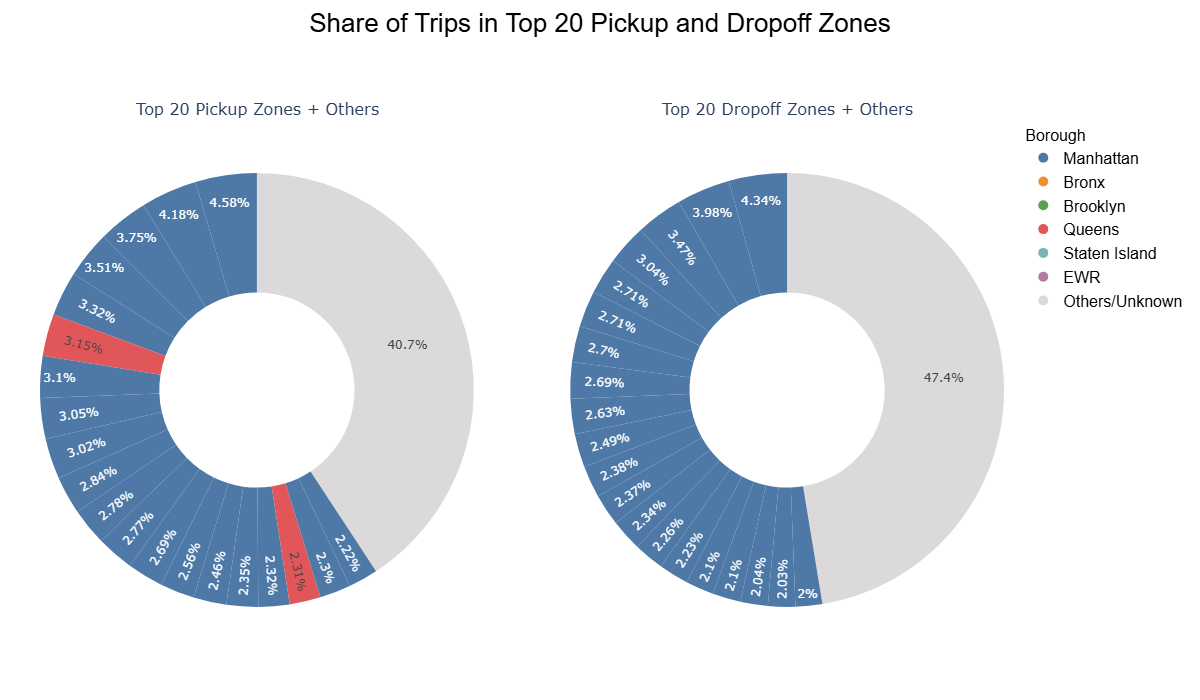

In [52]:
# Count distinct number of pickup and dropoff zones in trip records
pickup_zone_counts = df['pickup_zone'].nunique()
dropoff_zone_counts = df['dropoff_zone'].nunique()
print("Number of distinct pickup zones:")
print(pickup_zone_counts)
print("\nNumber of distinct dropoff zones:")
print(dropoff_zone_counts)

# Create donut charts for top pickup and dropoff zones using zone names.
zone_name_map = zone_lookup.set_index('LocationID')['Zone'].to_dict()
zone_borough_map = zone_lookup.set_index('LocationID')['Borough'].to_dict()

borough_colors_map = {
    'Manhattan': '#4E79A7',
    'Bronx': '#F28E2B',
    'Brooklyn': '#59A14F',
    'Queens': '#E15759',
    'Staten Island': '#76B7B2',
    'EWR': '#B07AA1'
}
other_color = "#DBD9D9"

def topn_with_others(series, zone_map, n=20):
    counts = series.value_counts()
    topn = counts.head(n)
    others_count = counts.iloc[n:].sum()

    ids = [int(location_id) for location_id in topn.index]
    labels = [zone_map.get(location_id, f'Unknown ({location_id})') for location_id in ids]
    values = topn.tolist()

    if others_count > 0:
        labels.append('Others')
        values.append(others_count)
        ids.append(None)

    return labels, values, ids

def colors_from_borough(zone_ids, borough_map, borough_colors, fallback_color):
    colors = []
    for zone_id in zone_ids:
        if zone_id is None:
            colors.append(fallback_color)
        else:
            borough = borough_map.get(zone_id, 'Unknown')
            colors.append(borough_colors.get(borough, fallback_color))
    return colors

pu_labels, pu_values, pu_ids = topn_with_others(df['PULocationID'], zone_name_map, n=20)
do_labels, do_values, do_ids = topn_with_others(df['DOLocationID'], zone_name_map, n=20)

pu_colors = colors_from_borough(pu_ids, zone_borough_map, borough_colors_map, other_color)
do_colors = colors_from_borough(do_ids, zone_borough_map, borough_colors_map, other_color)

fig = make_subplots(
    rows=1,
    cols=2,
    specs=[[{'type': 'domain'}, {'type': 'domain'}]],
    subplot_titles=['Top 20 Pickup Zones + Others', 'Top 20 Dropoff Zones + Others']
 )
fig.add_trace(go.Pie(labels=pu_labels, values=pu_values, hole=0.45, marker_colors=pu_colors,
                     hovertemplate='%{label}<br>Trips: %{value:,}<br>Percentage: %{percent}', textinfo='percent',
                     textposition='inside', showlegend=False),
                row=1, col=1)
fig.add_trace(go.Pie(labels=do_labels, values=do_values, hole=0.45, marker_colors=do_colors,
                     hovertemplate='%{label}<br>Trips: %{value:,}<br>Percentage: %{percent}', textinfo='percent',
                     textposition='inside', showlegend=False),
                row=1, col=2)

for borough, color in borough_colors_map.items():
    fig.add_trace(go.Scatter(
        x=[None],
        y=[None],
        mode='markers',
        marker=dict(size=10, color=color),
        name=borough,
        showlegend=True,
        hoverinfo='skip'
    ))
fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode='markers',
    marker=dict(size=10, color=other_color),
    name='Others/Unknown',
    showlegend=True,
    hoverinfo='skip'
))

fig.update_layout(title_text='Share of Trips in Top 20 Pickup and Dropoff Zones',
                    title_font_size=26, title_font_family='Arial', title_font_color='black',
                    title_x=0.5, title_xanchor='center',
                    title_y=0.98,
                    legend_title_text='Borough', legend_title_font_size=16, legend_title_font_family='Arial',
                    legend_title_font_color='black', legend_font_size=16, legend_font_family='Arial',
                    legend_font_color='black', height=700,
                    paper_bgcolor='white', plot_bgcolor='white',
                    xaxis=dict(visible=False, showgrid=False, zeroline=False, showticklabels=False),
                    yaxis=dict(visible=False, showgrid=False, zeroline=False, showticklabels=False),
                    margin=dict(t=120, b=40, l=40, r=40))

# show as static image with size 1000x700 for better readability in notebook
fig.show(renderer="png", width=1200, height=700)

- The trips are **highly concentrated** in a few zones: out of ~250 zones, both the top 20 pickup and dropoff zones account for more than half of trip volume.
- The top 20 pickup zones are mostly in Manhattan, together with 2 airports in Queens.
- The top 20 dropoff zones are all in Manhattan.

[Back to Table of Contents](#table-of-contents)
##### Route analysis

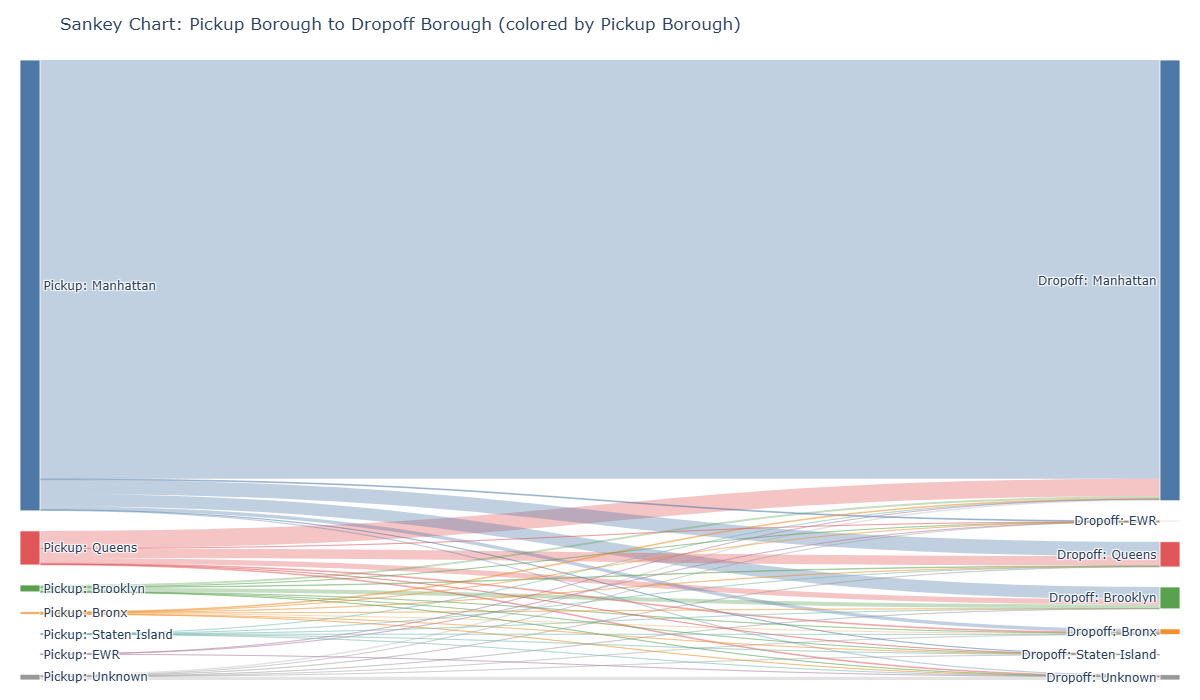

In [53]:
borough_flows = (
    df[['pickup_borough', 'dropoff_borough']]
    .fillna('Unknown')
    .groupby(['pickup_borough', 'dropoff_borough'])
    .size()
    .reset_index(name='trip_count')
    .sort_values('trip_count', ascending=False)
)

total_sankey_trips = borough_flows['trip_count'].sum()
borough_flows['trip_pct'] = borough_flows['trip_count'] / total_sankey_trips * 100

pickup_boroughs = borough_flows['pickup_borough'].drop_duplicates().tolist()
dropoff_boroughs = borough_flows['dropoff_borough'].drop_duplicates().tolist()

pickup_labels = [f'Pickup: {borough}' for borough in pickup_boroughs]
dropoff_labels = [f'Dropoff: {borough}' for borough in dropoff_boroughs]
node_labels = pickup_labels + dropoff_labels

pickup_index = {borough: idx for idx, borough in enumerate(pickup_boroughs)}
dropoff_index = {borough: idx + len(pickup_boroughs) for idx, borough in enumerate(dropoff_boroughs)}

sources = borough_flows['pickup_borough'].map(pickup_index).tolist()
targets = borough_flows['dropoff_borough'].map(dropoff_index).tolist()
values = borough_flows['trip_count'].tolist()

# Borough-to-color mapping
borough_colors_map = {
    'Manhattan': '#4E79A7',      # Blue
    'Bronx': '#F28E2B',          # Orange
    'Brooklyn': '#59A14F',       # Green
    'Queens': '#E15759',         # Red
    'Staten Island': '#76B7B2',  # Teal
    'EWR': '#B07AA1',            # Purple
}

# Assign colors based on borough
pickup_node_colors = [borough_colors_map.get(borough, '#999999') for borough in pickup_boroughs]
dropoff_node_colors = [borough_colors_map.get(borough, '#999999') for borough in dropoff_boroughs]
node_colors = pickup_node_colors + dropoff_node_colors

# Use borough-specific link colors (semi-transparent) based on pickup borough
borough_link_colors_map = {
    'Manhattan': 'rgba(78,121,167,0.35)',
    'Bronx': 'rgba(242,142,43,0.35)',
    'Brooklyn': 'rgba(89,161,79,0.35)',
    'Queens': 'rgba(225,87,89,0.35)',
    'Staten Island': 'rgba(118,183,178,0.35)',
    'EWR': 'rgba(176,122,161,0.35)'
}
link_colors = [
    borough_link_colors_map.get(borough, 'rgba(153,153,153,0.28)')
    for borough in borough_flows['pickup_borough']
]

fig = go.Figure(
    data=[
        go.Sankey(
            arrangement='snap',
            node=dict(
                pad=20,
                thickness=20,
                line=dict(color='white', width=0.8),
                label=node_labels,
                color=node_colors
            ),
            link=dict(
                source=sources,
                target=targets,
                value=values,
                color=link_colors,
                customdata=borough_flows[['pickup_borough', 'dropoff_borough', 'trip_pct']].values,
                hovertemplate='Pickup %{customdata[0]}<br>Dropoff %{customdata[1]}<br>Trips %{value:,} (%{customdata[2]:.2f}%)<extra></extra>'
            )
        )
    ]
)

fig.update_layout(
    title='Sankey Chart: Pickup Borough to Dropoff Borough (colored by Pickup Borough)',
    font=dict(size=12),
    width=1000,
    height=650,
    margin=dict(l=20, r=20, t=60, b=20),
    paper_bgcolor='white'
)

# show as static image with size 1000x700 for better readability in notebook
fig.show(renderer="png", width=1200, height=700)

Nearly 85% of trips start and end within Manhattan, which is expected given that Manhattan is the most densely populated borough and a major commercial hub with many attractions, offices, and transportation connections. Besides, yellow taxi works mostly in Manhattan area (all yellow zones are in Manhattan).

[Back to Table of Contents](#table-of-contents)
##### Pickup zone Heatmaps: Trip Volume, Trip Distance and Revenue Efficiency

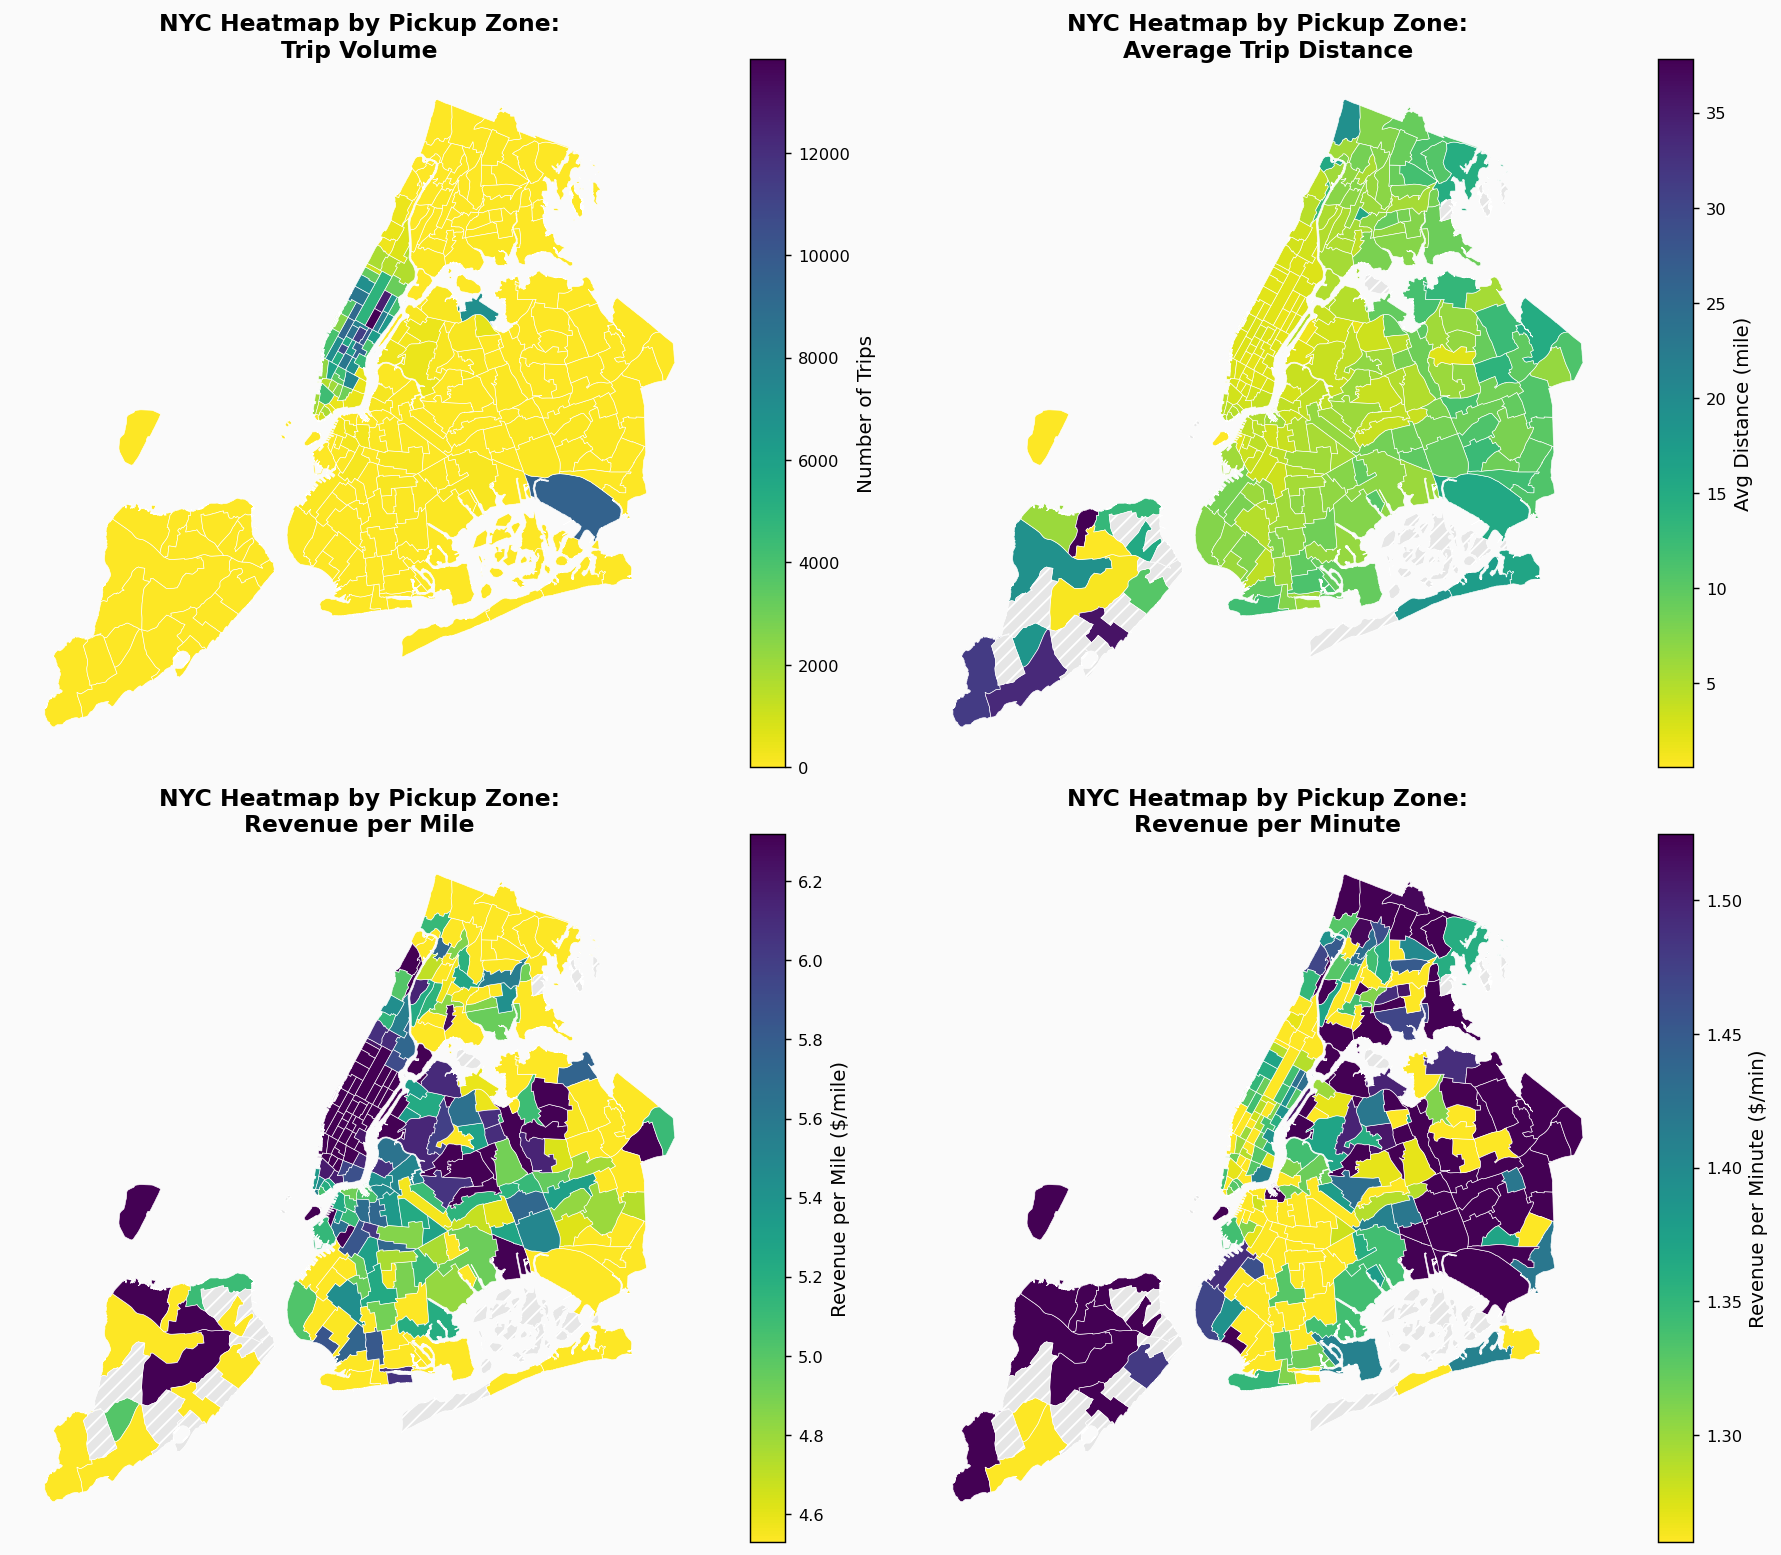

In [54]:
# 1) Trip Volume by pickup zone

trip_stats = (
    df.groupby('PULocationID')
    .agg(trip_count=('PULocationID', 'size'))
    .reset_index()
)

volume_heatmap_gdf = zones_gdf.merge(trip_stats, on='PULocationID', how='left')
volume_heatmap_gdf['Trip Count'] = volume_heatmap_gdf['trip_count'].fillna(0).astype(int)
volume_heatmap_gdf = volume_heatmap_gdf.to_crs(epsg=4326)

# 2) Average Trip Distance by pickup zone
distance_stats = (
    df.groupby('PULocationID')
    .agg(
        avg_distance=('trip_distance', 'mean'),
        trip_count=('PULocationID', 'size')
    )
    .reset_index()
)

distance_heatmap_gdf = zones_gdf.merge(distance_stats, on='PULocationID', how='left')
distance_heatmap_gdf['Avg Distance (mile)'] = distance_heatmap_gdf['avg_distance'].round(2)
distance_heatmap_gdf['Trip Count'] = distance_heatmap_gdf['trip_count'].fillna(0).astype(int)
distance_heatmap_gdf = distance_heatmap_gdf.to_crs(epsg=4326)

# 3) Revenue per Mile by pickup zone
rpm_stats = (
    df.groupby('PULocationID')
    .agg(
        total_revenue=('total_amount', 'sum'),
        total_distance=('trip_distance', 'sum')
    )
    .reset_index()
)

rpm_stats['Revenue per Mile ($/mile)'] = np.where(
    rpm_stats['total_distance'] > 0,
    rpm_stats['total_revenue'] / rpm_stats['total_distance'],
    np.nan
)

rpm_heatmap_gdf = zones_gdf.merge(rpm_stats, on='PULocationID', how='left')
rpm_heatmap_gdf['Revenue per Mile ($/mile)'] = rpm_heatmap_gdf['Revenue per Mile ($/mile)'].round(2)
rpm_heatmap_gdf = rpm_heatmap_gdf.to_crs(epsg=4326)

# 4) Revenue per Minute by pickup zone
rpm_min_stats = (
    df.groupby('PULocationID')
    .agg(
        total_revenue=('total_amount', 'sum'),
        total_duration_min=('trip_duration_min', 'sum')
    )
    .reset_index()
)

rpm_min_stats['Revenue per Minute ($/min)'] = np.where(
    rpm_min_stats['total_duration_min'] > 0,
    rpm_min_stats['total_revenue'] / rpm_min_stats['total_duration_min'],
    np.nan
)

rpm_min_heatmap_gdf = zones_gdf.merge(rpm_min_stats, on='PULocationID', how='left')
rpm_min_heatmap_gdf['Revenue per Minute ($/min)'] = rpm_min_heatmap_gdf['Revenue per Minute ($/min)'].round(2)
rpm_min_heatmap_gdf = rpm_min_heatmap_gdf.to_crs(epsg=4326)

# Plot all four maps in one 2x2 layout
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

volume_heatmap_gdf.plot(
    column='Trip Count',
    cmap='viridis_r',
    linewidth=0.35,
    edgecolor='white',
    legend=True,
    missing_kwds={
        'color': '#E6E6E6',
        'edgecolor': 'white',
        'hatch': '///',
        'label': 'No data'
    },
    ax=axes[0]
)
axes[0].set_title('NYC Heatmap by Pickup Zone:\nTrip Volume', fontweight='bold')
axes[0].set_axis_off()
fig.axes[-1].set_ylabel('Number of Trips')

distance_heatmap_gdf.plot(
    column='Avg Distance (mile)',
    cmap='viridis_r',
    linewidth=0.35,
    edgecolor='white',
    legend=True,
    missing_kwds={
        'color': '#E6E6E6',
        'edgecolor': 'white',
        'hatch': '///',
        'label': 'No data'
    },
    ax=axes[1]
)
axes[1].set_title('NYC Heatmap by Pickup Zone:\nAverage Trip Distance', fontweight='bold')
axes[1].set_axis_off()
fig.axes[-1].set_ylabel('Avg Distance (mile)')

rpm_heatmap_gdf.plot(
    column='Revenue per Mile ($/mile)',
    cmap='viridis_r',
    vmin=rpm_heatmap_gdf['Revenue per Mile ($/mile)'].quantile(0.25),
    vmax=rpm_heatmap_gdf['Revenue per Mile ($/mile)'].quantile(0.75),
    linewidth=0.35,
    edgecolor='white',
    legend=True,
    missing_kwds={
        'color': '#E6E6E6',
        'edgecolor': 'white',
        'hatch': '///',
        'label': 'No data'
    },
    ax=axes[2]
)
axes[2].set_title('NYC Heatmap by Pickup Zone:\nRevenue per Mile', fontweight='bold')
axes[2].set_axis_off()
fig.axes[-1].set_ylabel('Revenue per Mile ($/mile)')

rpm_min_heatmap_gdf.plot(
    column='Revenue per Minute ($/min)',
    cmap='viridis_r',
    vmin=rpm_min_heatmap_gdf['Revenue per Minute ($/min)'].quantile(0.25),
    vmax=rpm_min_heatmap_gdf['Revenue per Minute ($/min)'].quantile(0.75),
    linewidth=0.35,
    edgecolor='white',
    legend=True,
    missing_kwds={
        'color': '#E6E6E6',
        'edgecolor': 'white',
        'hatch': '///',
        'label': 'No data'
    },
    ax=axes[3]
)
axes[3].set_title('NYC Heatmap by Pickup Zone:\nRevenue per Minute', fontweight='bold')
axes[3].set_axis_off()
fig.axes[-1].set_ylabel('Revenue per Minute ($/min)')

plt.tight_layout()
plt.show()


**Insights from the combined pickup-zone heatmaps (Volume, Distance, Revenue per Mile, Revenue per Minute):**

- **Trip volume** is heavily concentrated in Manhattan, with airport-related zones in Queens as secondary hotspots.

- **Average trip distance** is generally shorter in high-volume core zones (especially Manhattan) and longer in lower-volume outer-borough zones.

- **Revenue per mile** tends to be strongest in central, dense activity zones and weaker across many peripheral zones.

- **Revenue per minute** adds a complementary view: the general pattern is opposite to Revenue per mile. However, some zones with moderate distance efficiency still show strong time-based efficiency, while other zones underperform on both efficiency metrics.

- Together, the four maps show a clear core-periphery pattern: a high-demand urban core with stronger distance-based yield versus a lower-demand outer area with more mixed efficiency outcomes.

- Operationally, zone decisions should combine **demand scale** (volume) with both **distance-based** and **time-based** efficiency metrics, while treating low-volume zones with caution due to potential metric instability.

- Newark airport surprisingly has very short-distance trips, which will be investigated next.


In [55]:
# Filter EWR pickup trips and show key trip fields
ewr_trips = df[df["pickup_borough"] == "EWR"].copy()
selected_cols = ["trip_duration_min", "trip_distance", "total_amount"]
ewr_trips = ewr_trips[selected_cols]
ewr_trips.describe()

,trip_duration_min,trip_distance,total_amount
count,38.000000,38.000000,38.000000
mean,1.504386,0.567895,93.983421
std,5.951287,3.139495,32.630884
min,0.033333,0.000000,5.300000
25%,0.066667,0.000000,81.690000
50%,0.208333,0.000000,105.495000
75%,0.858333,0.017500,117.240000
max,36.850000,19.380000,138.300000


- The above result shows that Newark has a lot of zero-distance trips with very high total_amount. This suggests a possible recording or metering anomaly.

[Back to Table of Contents](#table-of-contents)
### 5.4.  Vendor Analysis (L1)

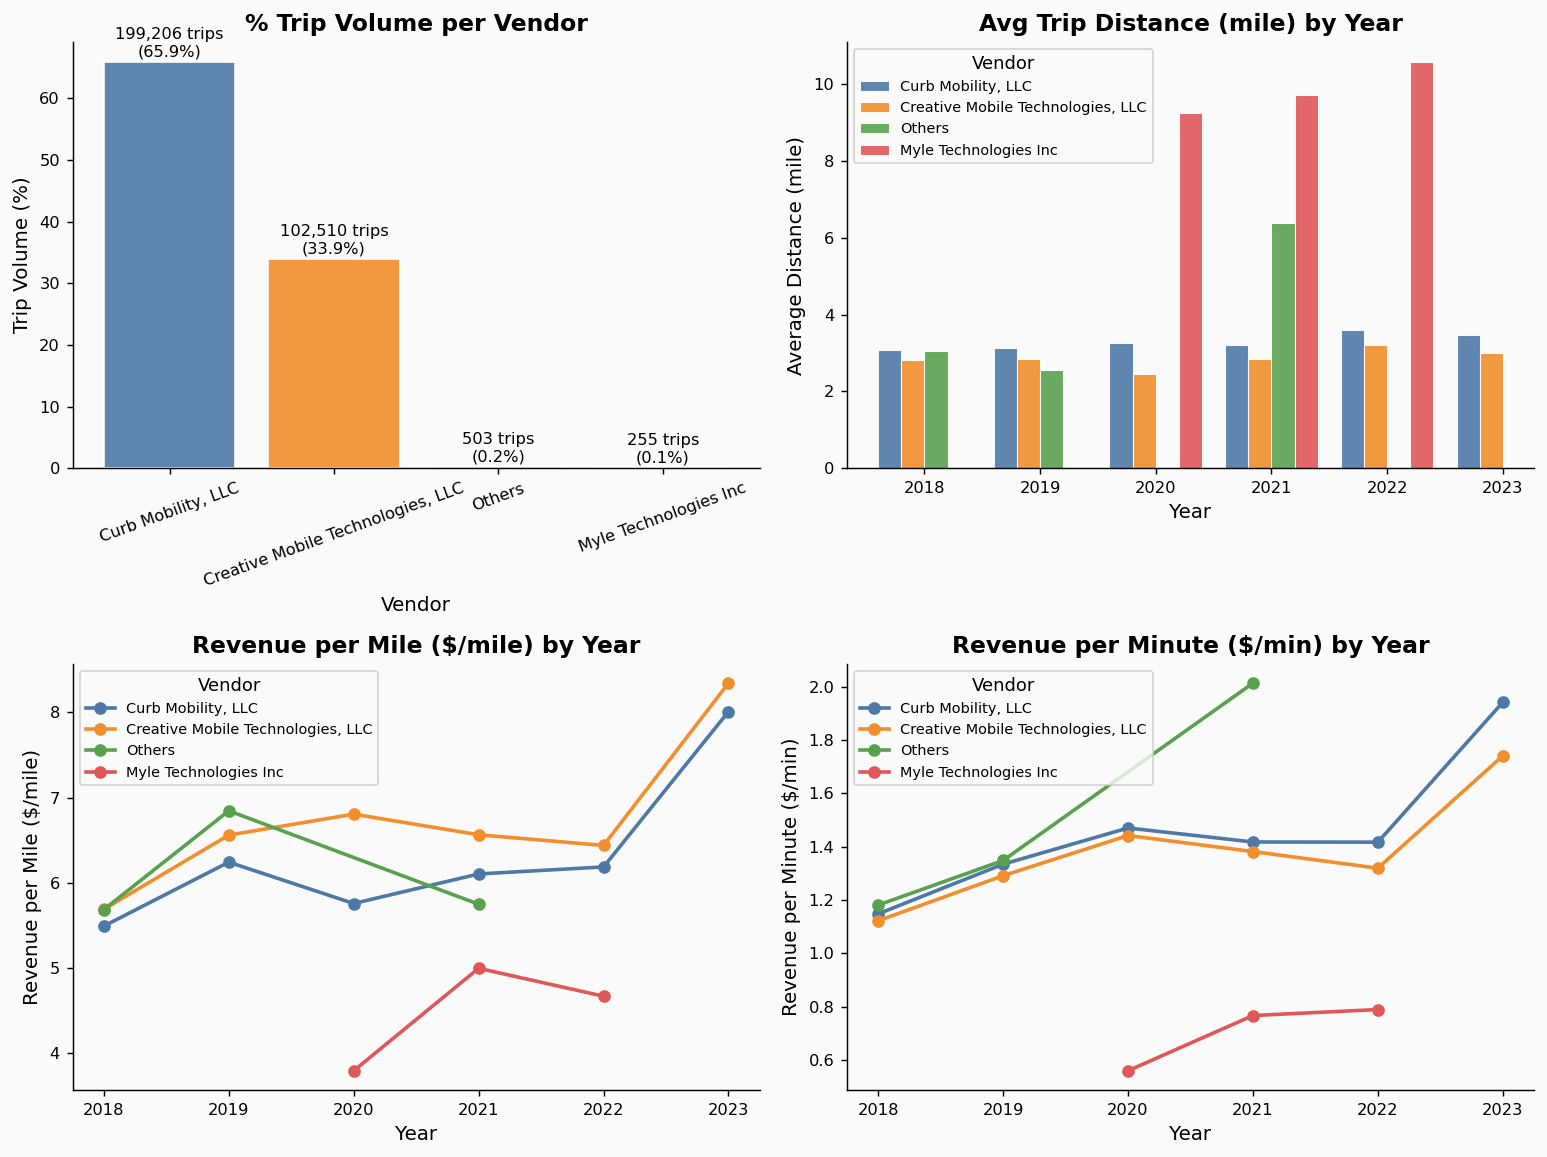

In [56]:
# Vendor charts: trip volume share, avg distance by year, revenue per mile by year, revenue per minute by year
vendor_year = (
    df.groupby(['vendor_name', 'pickup_year'])
    .agg(
        trips=('total_amount', 'count'),
        total_revenue=('total_amount', 'sum'),
        total_distance=('trip_distance', 'sum'),
        total_duration_min=('trip_duration_min', 'sum'),
        avg_distance=('trip_distance', 'mean')
    )
    .reset_index()
)
vendor_year['revenue_per_mile'] = np.where(
    vendor_year['total_distance'] > 0,
    vendor_year['total_revenue'] / vendor_year['total_distance'],
    np.nan
)
vendor_year['revenue_per_minute'] = np.where(
    vendor_year['total_duration_min'] > 0,
    vendor_year['total_revenue'] / vendor_year['total_duration_min'],
    np.nan
)

vendor_total = (
    vendor_year.groupby('vendor_name', as_index=False)['trips']
    .sum()
    .sort_values('trips', ascending=False)
)
vendor_total['trip_pct'] = vendor_total['trips'] / vendor_total['trips'].sum() * 100

# Keep vendor colors consistent across all charts
vendor_names = vendor_total['vendor_name'].tolist()
vendor_colors = {vendor: PALETTE[i % len(PALETTE)] for i, vendor in enumerate(vendor_names)}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
ax1, ax2, ax3, ax4 = axes.flatten()

# 1) Bar chart: % trip volume per vendor
bars = ax1.bar(
    vendor_total['vendor_name'],
    vendor_total['trip_pct'],
    color=[vendor_colors[v] for v in vendor_total['vendor_name']],
    edgecolor='white',
    linewidth=1,
    alpha=0.9
)
ax1.set_title('% Trip Volume per Vendor', fontweight='bold')
ax1.set_xlabel('Vendor')
ax1.set_ylabel('Trip Volume (%)')
ax1.tick_params(axis='x', rotation=20)

for bar, trips, pct in zip(bars, vendor_total['trips'], vendor_total['trip_pct']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.4,
        f'{trips:,.0f} trips\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=9
    )

# 2) Grouped bar chart: avg trip distance over years by vendor
years = sorted(vendor_year['pickup_year'].unique())
x = np.arange(len(years))
bar_width = 0.8 / max(len(vendor_names), 1)

for i, vendor in enumerate(vendor_names):
    sub = vendor_year[vendor_year['vendor_name'] == vendor].sort_values('pickup_year')
    sub_indexed = sub.set_index('pickup_year').reindex(years)
    ax2.bar(
        x + (i - (len(vendor_names) - 1) / 2) * bar_width,
        sub_indexed['avg_distance'],
        width=bar_width,
        color=vendor_colors[vendor],
        label=vendor,
        alpha=0.9,
        edgecolor='white',
        linewidth=0.6
    )
ax2.set_title('Avg Trip Distance (mile) by Year', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Distance (mile)')
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.legend(title='Vendor', fontsize=8)

# 3) Line chart: $ per mile over years by vendor
for vendor in vendor_names:
    sub = vendor_year[vendor_year['vendor_name'] == vendor].sort_values('pickup_year')
    ax3.plot(
        sub['pickup_year'],
        sub['revenue_per_mile'],
        marker='o',
        linewidth=2,
        color=vendor_colors[vendor],
        label=vendor
    )
ax3.set_title('Revenue per Mile ($/mile) by Year', fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Revenue per Mile ($/mile)')
ax3.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax3.legend(title='Vendor', fontsize=8)

# 4) Line chart: $ per minute over years by vendor
for vendor in vendor_names:
    sub = vendor_year[vendor_year['vendor_name'] == vendor].sort_values('pickup_year')
    ax4.plot(
        sub['pickup_year'],
        sub['revenue_per_minute'],
        marker='o',
        linewidth=2,
        color=vendor_colors[vendor],
        label=vendor
    )
ax4.set_title('Revenue per Minute ($/min) by Year', fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Revenue per Minute ($/min)')
ax4.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax4.legend(title='Vendor', fontsize=8)

plt.tight_layout()
plt.show()

**Vendor Insights**

- Trip volume is highly concentrated in Curb Mobility and Creative Mobile Technologies; other vendors have minimal share.
- The two major vendors maintain stable average trip distance, while smaller vendors tend to run longer trips.
- Revenue per mile and per minute is stronger for the top vendors and jumps in 2023.
- Myle remains lower for both efficiency metrics, suggesting a different fare mix.
- Results for small vendors are volatile and should be interpreted cautiously due to low trip counts.

[Back to Table of Contents](#table-of-contents)
### 5.5. Rate Code Analysis (L1)

I will follow the same structure as Vendor Analysis

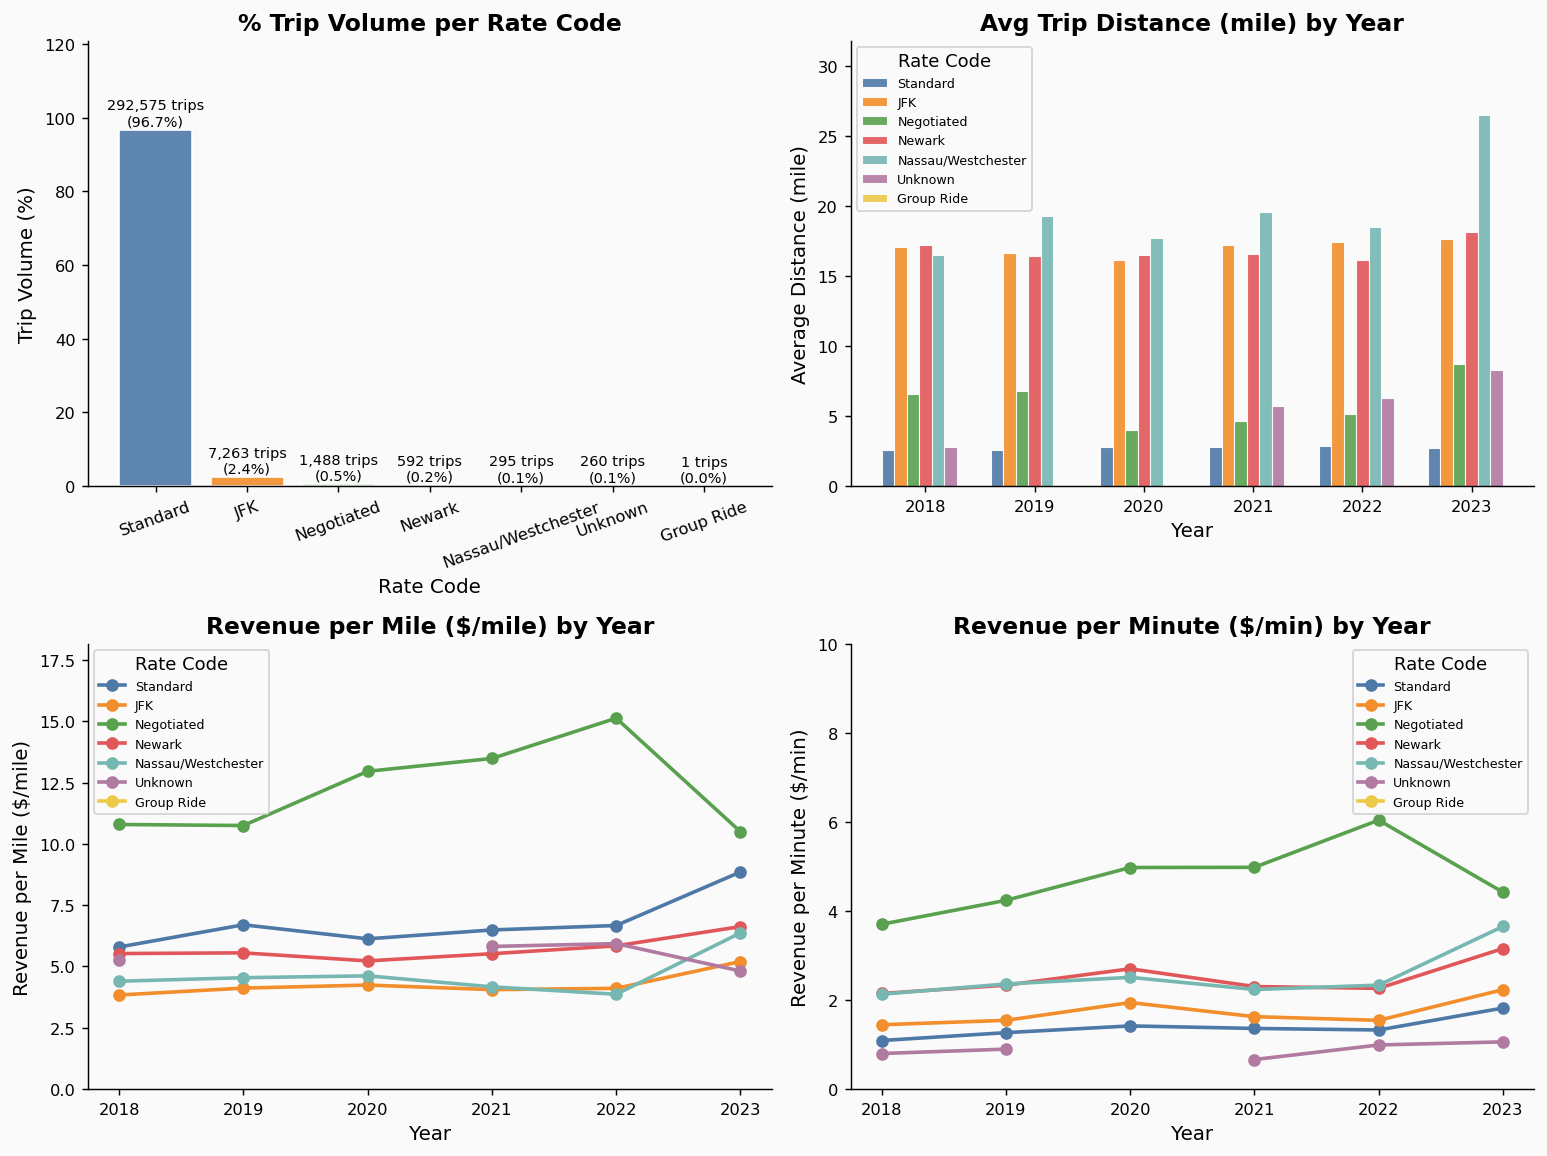

In [57]:
# Rate code charts: trip volume share, avg distance by year, revenue per mile by year, revenue per minute by year
rate_year = (
    df.groupby(['rate_label', 'pickup_year'])
    .agg(
        trips=('total_amount', 'count'),
        total_revenue=('total_amount', 'sum'),
        total_distance=('trip_distance', 'sum'),
        total_duration_min=('trip_duration_min', 'sum'),
        avg_distance=('trip_distance', 'mean')
    )
    .reset_index()
)
rate_year['revenue_per_mile'] = np.where(
    rate_year['total_distance'] > 0,
    rate_year['total_revenue'] / rate_year['total_distance'],
    np.nan
)
rate_year['revenue_per_minute'] = np.where(
    rate_year['total_duration_min'] > 0,
    rate_year['total_revenue'] / rate_year['total_duration_min'],
    np.nan
)

rate_total = (
    rate_year.groupby('rate_label', as_index=False)['trips']
    .sum()
    .sort_values('trips', ascending=False)
)
rate_total['trip_pct'] = rate_total['trips'] / rate_total['trips'].sum() * 100

# Keep rate-code colors consistent across all charts
rate_names = rate_total['rate_label'].tolist()
rate_colors = {rate: PALETTE[i % len(PALETTE)] for i, rate in enumerate(rate_names)}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
ax1, ax2, ax3, ax4 = axes.flatten()

# 1) Bar chart: % trip volume per rate code
bars = ax1.bar(
    rate_total['rate_label'],
    rate_total['trip_pct'],
    color=[rate_colors[r] for r in rate_total['rate_label']],
    edgecolor='white',
    linewidth=1,
    alpha=0.9
)
ax1.set_title('% Trip Volume per Rate Code', fontweight='bold')
ax1.set_xlabel('Rate Code')
ax1.set_ylabel('Trip Volume (%)')
ax1.tick_params(axis='x', rotation=20)
ax1.set_ylim(0, rate_total['trip_pct'].max() * 1.25)

for bar, trips, pct in zip(bars, rate_total['trips'], rate_total['trip_pct']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.35,
        f'{trips:,.0f} trips\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=8
    )

# 2) Grouped bar chart: avg trip distance over years by rate code
years = sorted(rate_year['pickup_year'].unique())
x = np.arange(len(years))
bar_width = 0.8 / max(len(rate_names), 1)

for i, rate in enumerate(rate_names):
    sub = rate_year[rate_year['rate_label'] == rate].sort_values('pickup_year')
    sub_indexed = sub.set_index('pickup_year').reindex(years)
    ax2.bar(
        x + (i - (len(rate_names) - 1) / 2) * bar_width,
        sub_indexed['avg_distance'],
        width=bar_width,
        color=rate_colors[rate],
        label=rate,
        alpha=0.9,
        edgecolor='white',
        linewidth=0.6
    )
ax2.set_title('Avg Trip Distance (mile) by Year', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Distance (mile)')
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.set_ylim(0, rate_year['avg_distance'].max() * 1.2)
ax2.legend(title='Rate Code', fontsize=7)

# 3) Line chart: $ per mile over years by rate code
for rate in rate_names:
    sub = rate_year[rate_year['rate_label'] == rate].sort_values('pickup_year')
    ax3.plot(
        sub['pickup_year'],
        sub['revenue_per_mile'],
        marker='o',
        linewidth=2,
        color=rate_colors[rate],
        label=rate
    )
ax3.set_title('Revenue per Mile ($/mile) by Year', fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Revenue per Mile ($/mile)')
ax3.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax3.set_ylim(0, rate_year['revenue_per_mile'].max() * 1.2)
ax3.legend(title='Rate Code', fontsize=7)

# 4) Line chart: $ per minute over years by rate code (exclude Group Ride)
for rate in rate_names:
    sub = rate_year[rate_year['rate_label'] == rate].sort_values('pickup_year')
    ax4.plot(
        sub['pickup_year'],
        sub['revenue_per_minute'],
        marker='o',
        linewidth=2,
        color=rate_colors[rate],
        label=rate
    )
ax4.set_title('Revenue per Minute ($/min) by Year', fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Revenue per Minute ($/min)')
ax4.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax4.set_ylim(0, 10)
ax4.legend(title='Rate Code', fontsize=7)

plt.tight_layout()
plt.show()

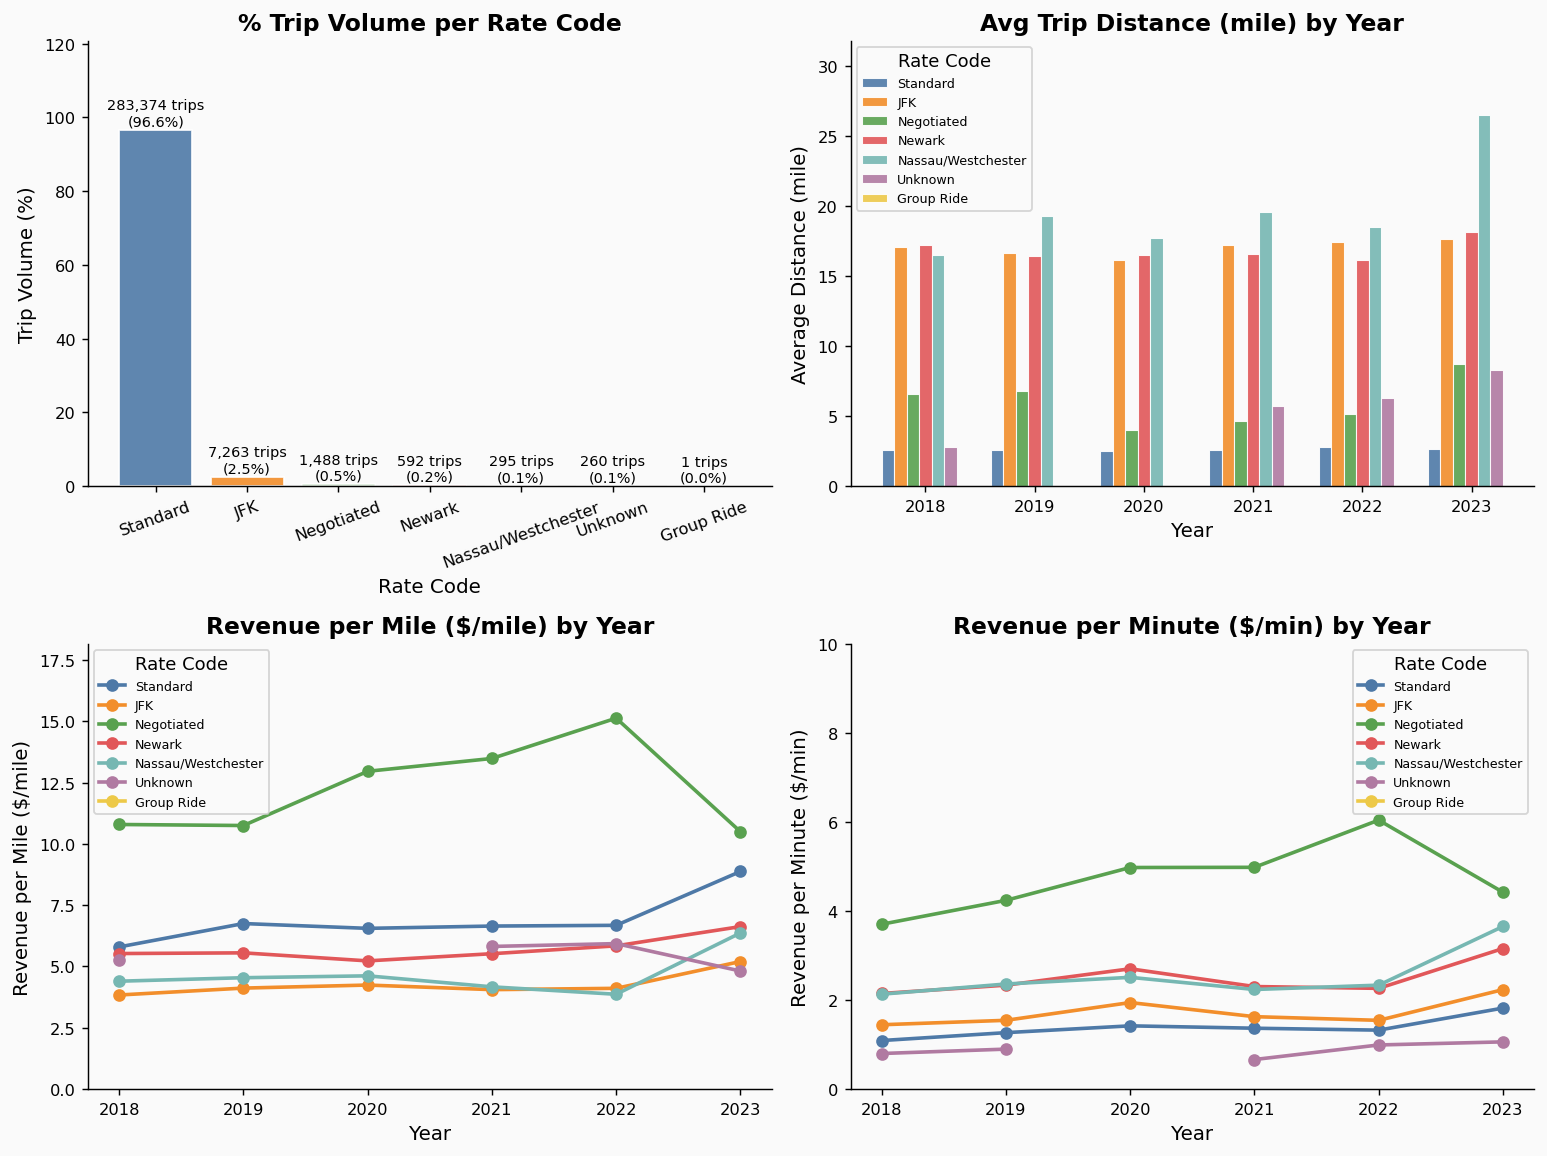

In [75]:
# Draw all the same charts but exclude rows where has_null_metadata is true, 
# to see if the trends are different when excluding trips with missing metadata.
df_exclude_null = df[df['has_null_metadata'] == False].copy()
rate_year = (
    df_exclude_null.groupby(['rate_label', 'pickup_year'])
    .agg(
        trips=('total_amount', 'count'),
        total_revenue=('total_amount', 'sum'),
        total_distance=('trip_distance', 'sum'),
        total_duration_min=('trip_duration_min', 'sum'),
        avg_distance=('trip_distance', 'mean')
    )
    .reset_index()
)
rate_year['revenue_per_mile'] = np.where(
    rate_year['total_distance'] > 0,
    rate_year['total_revenue'] / rate_year['total_distance'],
    np.nan
)
rate_year['revenue_per_minute'] = np.where(
    rate_year['total_duration_min'] > 0,
    rate_year['total_revenue'] / rate_year['total_duration_min'],
    np.nan
)

rate_total = (
    rate_year.groupby('rate_label', as_index=False)['trips']
    .sum()
    .sort_values('trips', ascending=False)
)
rate_total['trip_pct'] = rate_total['trips'] / rate_total['trips'].sum() * 100

# Keep rate-code colors consistent across all charts
rate_names = rate_total['rate_label'].tolist()
rate_colors = {rate: PALETTE[i % len(PALETTE)] for i, rate in enumerate(rate_names)}

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
ax1, ax2, ax3, ax4 = axes.flatten()

# 1) Bar chart: % trip volume per rate code
bars = ax1.bar(
    rate_total['rate_label'],
    rate_total['trip_pct'],
    color=[rate_colors[r] for r in rate_total['rate_label']],
    edgecolor='white',
    linewidth=1,
    alpha=0.9
)
ax1.set_title('% Trip Volume per Rate Code', fontweight='bold')
ax1.set_xlabel('Rate Code')
ax1.set_ylabel('Trip Volume (%)')
ax1.tick_params(axis='x', rotation=20)
ax1.set_ylim(0, rate_total['trip_pct'].max() * 1.25)

for bar, trips, pct in zip(bars, rate_total['trips'], rate_total['trip_pct']):
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.35,
        f'{trips:,.0f} trips\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=8
    )

# 2) Grouped bar chart: avg trip distance over years by rate code
years = sorted(rate_year['pickup_year'].unique())
x = np.arange(len(years))
bar_width = 0.8 / max(len(rate_names), 1)

for i, rate in enumerate(rate_names):
    sub = rate_year[rate_year['rate_label'] == rate].sort_values('pickup_year')
    sub_indexed = sub.set_index('pickup_year').reindex(years)
    ax2.bar(
        x + (i - (len(rate_names) - 1) / 2) * bar_width,
        sub_indexed['avg_distance'],
        width=bar_width,
        color=rate_colors[rate],
        label=rate,
        alpha=0.9,
        edgecolor='white',
        linewidth=0.6
    )
ax2.set_title('Avg Trip Distance (mile) by Year', fontweight='bold')
ax2.set_xlabel('Year')
ax2.set_ylabel('Average Distance (mile)')
ax2.set_xticks(x)
ax2.set_xticklabels(years)
ax2.set_ylim(0, rate_year['avg_distance'].max() * 1.2)
ax2.legend(title='Rate Code', fontsize=7)

# 3) Line chart: $ per mile over years by rate code
for rate in rate_names:
    sub = rate_year[rate_year['rate_label'] == rate].sort_values('pickup_year')
    ax3.plot(
        sub['pickup_year'],
        sub['revenue_per_mile'],
        marker='o',
        linewidth=2,
        color=rate_colors[rate],
        label=rate
    )
ax3.set_title('Revenue per Mile ($/mile) by Year', fontweight='bold')
ax3.set_xlabel('Year')
ax3.set_ylabel('Revenue per Mile ($/mile)')
ax3.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax3.set_ylim(0, rate_year['revenue_per_mile'].max() * 1.2)
ax3.legend(title='Rate Code', fontsize=7)

# 4) Line chart: $ per minute over years by rate code (exclude Group Ride)
for rate in rate_names:
    sub = rate_year[rate_year['rate_label'] == rate].sort_values('pickup_year')
    ax4.plot(
        sub['pickup_year'],
        sub['revenue_per_minute'],
        marker='o',
        linewidth=2,
        color=rate_colors[rate],
        label=rate
    )
ax4.set_title('Revenue per Minute ($/min) by Year', fontweight='bold')
ax4.set_xlabel('Year')
ax4.set_ylabel('Revenue per Minute ($/min)')
ax4.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
ax4.set_ylim(0, 10)
ax4.legend(title='Rate Code', fontsize=7)

plt.tight_layout()
plt.show()

As expected, the trend does not change a lot after I exclude missing values of Rate Code because the percentage of Standard rate trips is disproportionately large.

**Rate Code Insights**

- Standard rides drive the business by volume, while non-standard codes remain niche.
- Airport and premium-related codes carry longer trip profiles.
- Negotiated rate code perform the best for both revenue efficiency metrics.

**Management takeaway:** Keep Standard as the core volume engine, but prioritize negotiated segments as the main levers for margin expansion.

[Back to Table of Contents](#table-of-contents)
### 5.6. Tip Analysis (L2)

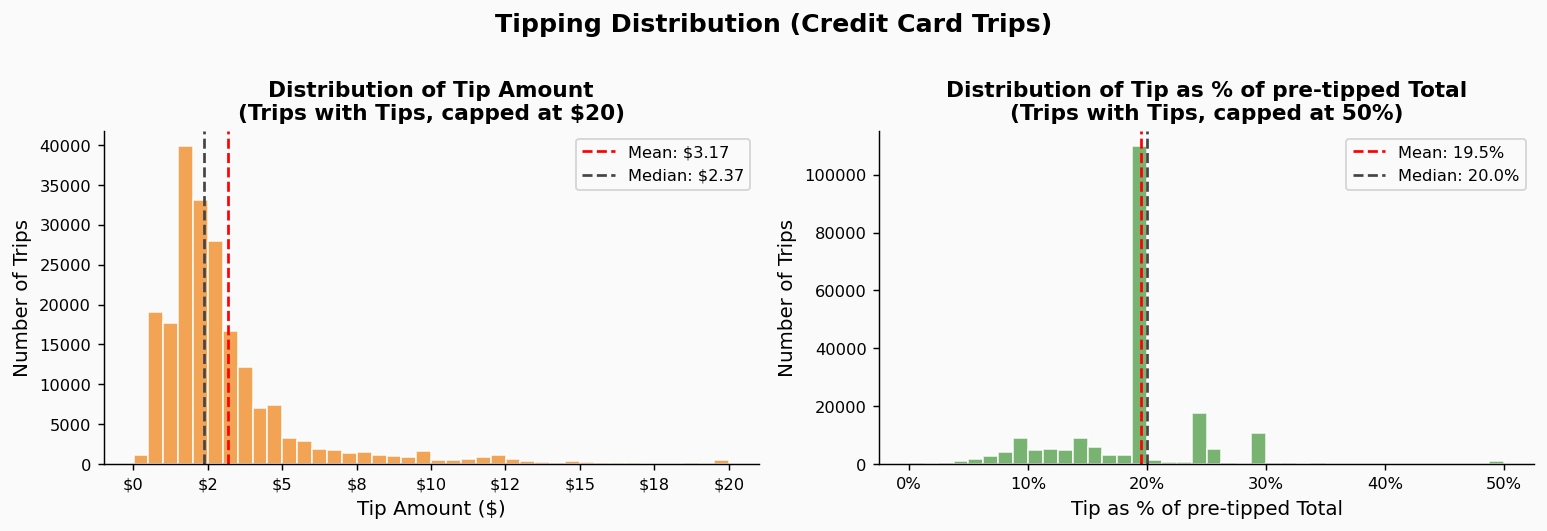

In [58]:
# Histograms: tipping distributions for credit card trips
cc_tip = cc_df[cc_df['tip_amount'] > 0].copy()
cc_tip['tip_pct_total'] = cc_tip['tip_amount'] / (cc_tip['total_amount']-cc_tip['tip_amount']) * 100

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Tipping Distribution (Credit Card Trips)', fontsize=14, fontweight='bold', y=1.01)

# ── 1) Avg Tip Amount distribution ───────────────────────────────────────────
axes[0].hist(cc_tip['tip_amount'].clip(upper=20), bins=40, color=PALETTE[1], alpha=0.8, edgecolor='white')
axes[0].axvline(cc_tip['tip_amount'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f"Mean: ${cc_tip['tip_amount'].mean():.2f}")
axes[0].axvline(cc_tip['tip_amount'].median(), color='#444444', linestyle='--', linewidth=1.5,
                label=f"Median: ${cc_tip['tip_amount'].median():.2f}")
axes[0].set_title('Distribution of Tip Amount\n(Trips with Tips, capped at $20)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tip Amount ($)')
axes[0].set_ylabel('Number of Trips')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'${v:.0f}'))
axes[0].legend(fontsize=9)

# ── 2) Tip as % of Total Amount ───────────────────────────────────────────────
axes[1].hist(cc_tip['tip_pct_total'].clip(upper=50), bins=40, color=PALETTE[2], alpha=0.8, edgecolor='white')
axes[1].axvline(cc_tip['tip_pct_total'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f"Mean: {cc_tip['tip_pct_total'].mean():.1f}%")
axes[1].axvline(cc_tip['tip_pct_total'].median(), color='#444444', linestyle='--', linewidth=1.5,
                label=f"Median: {cc_tip['tip_pct_total'].median():.1f}%")
axes[1].set_title('Distribution of Tip as % of pre-tipped Total\n(Trips with Tips, capped at 50%)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tip as % of pre-tipped Total')
axes[1].set_ylabel('Number of Trips')
axes[1].xaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

**Tip Histogram Insights**

- Tips are right-skewed: most trips have low-to-moderate tips, while high tips are relatively rare.
- The concentration near small tip values suggests many short trips or low-fare rides. A thin long tail indicates occasional high-tip trips, likely linked to longer distances or higher total fares.
- A large majority of trips have 20% tip. This may be the default choice for customers.

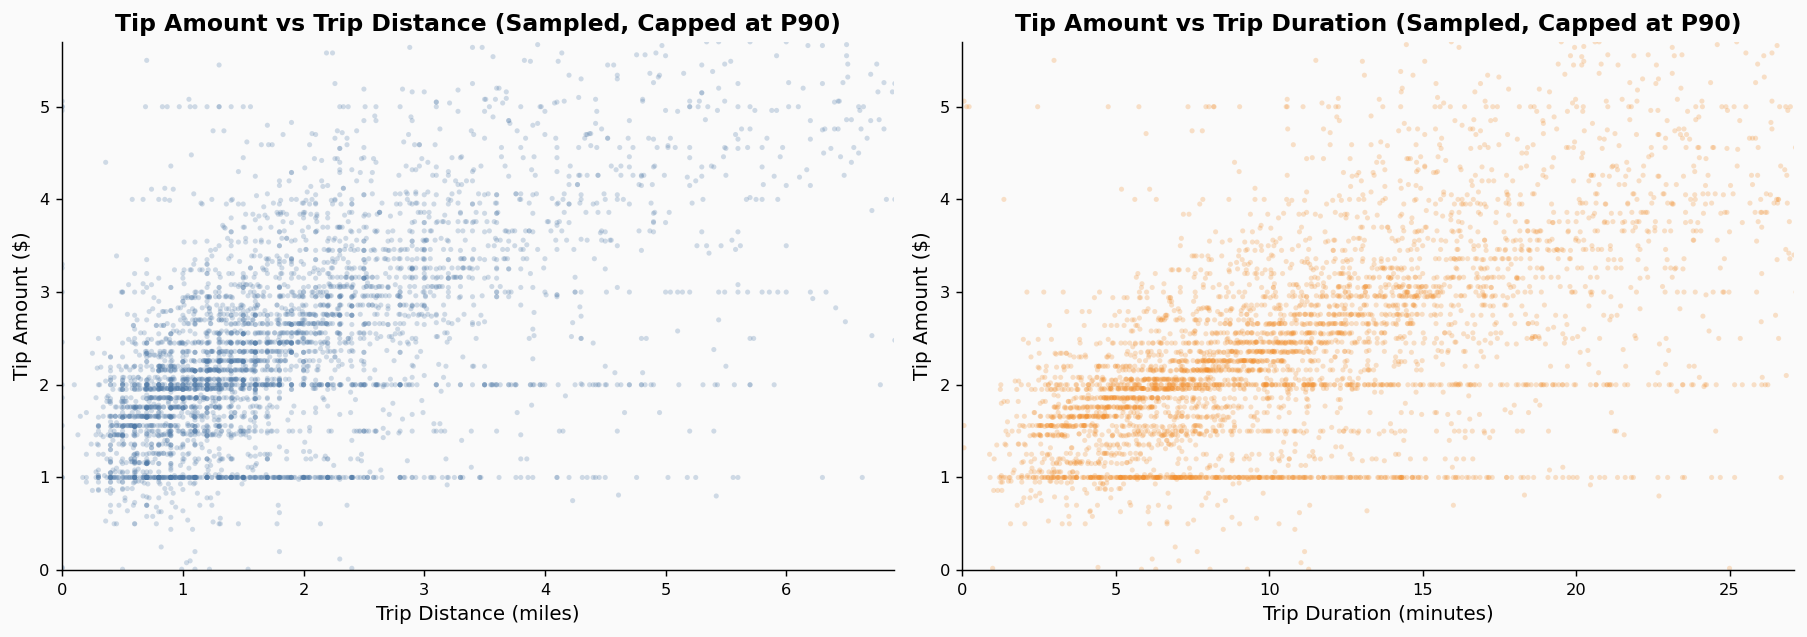

In [59]:
# Scatter plots before statistical tests: tip_amount vs trip_distance and tip_amount vs trip_duration_min
scatter_df = cc_tip[["tip_amount", "trip_distance", "trip_duration_min"]].dropna().copy()

# Use requested sample size
sample_n = min(5000, len(scatter_df))
scatter_sample = scatter_df.sample(n=sample_n, random_state=42)

# 90th percentile caps (computed from sampled data)
tip_p90 = scatter_sample["tip_amount"].quantile(0.90)
dist_p90 = scatter_sample["trip_distance"].quantile(0.90)
dur_p90 = scatter_sample["trip_duration_min"].quantile(0.90)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Tip Amount vs Trip Distance
axes[0].scatter(
    scatter_sample["trip_distance"],
    scatter_sample["tip_amount"],
    s=8,
    alpha=0.25,
    color=PALETTE[0],
    edgecolors="none",
)
axes[0].set_title("Tip Amount vs Trip Distance (Sampled, Capped at P90)", fontweight="bold")
axes[0].set_xlabel("Trip Distance (miles)")
axes[0].set_ylabel("Tip Amount ($)")
axes[0].set_xlim(0, dist_p90)
axes[0].set_ylim(0, tip_p90)

# 2) Tip Amount vs Trip Duration
axes[1].scatter(
    scatter_sample["trip_duration_min"],
    scatter_sample["tip_amount"],
    s=8,
    alpha=0.25,
    color=PALETTE[1],
    edgecolors="none",
)
axes[1].set_title("Tip Amount vs Trip Duration (Sampled, Capped at P90)", fontweight="bold")
axes[1].set_xlabel("Trip Duration (minutes)")
axes[1].set_ylabel("Tip Amount ($)")
axes[1].set_xlim(0, dur_p90)
axes[1].set_ylim(0, tip_p90)

plt.tight_layout()
plt.show()

Many trips have tip amount of $1 and $2. There is a generally positive correlation between tip amount and both trip distance and trip duration, but the relationship is not perfectly linear. Longer trips tend to have higher tips, but there is significant variability in tip amounts for trips of similar distance or duration.

In [60]:
# Statistical tests: correlation between tip amount and trip distance / trip duration
# Focus on credit-card trips with positive tips, where tip behavior is directly observed
corr_df = cc_tip[["trip_distance", "trip_duration_min", "tip_amount"]].dropna().copy()

print(f"Number of trips used in tests: {len(corr_df):,}")

from scipy.stats import spearmanr

# We use Spearman rank correlation to be robust to outliers, which are common in tip data
rho_dist, p_dist = spearmanr(corr_df["trip_distance"], corr_df["tip_amount"])
rho_dur, p_dur = spearmanr(corr_df["trip_duration_min"], corr_df["tip_amount"])

print("\nSpearman rank correlation tests")
print("H0: No monotonic correlation between variable and tip amount")
print(f"trip_distance vs tip_amount -> rho: {rho_dist:.3f}, p-value: {p_dist:.3e}")
print(f"trip_duration_min vs tip_amount -> rho: {rho_dur:.3f}, p-value: {p_dur:.3e}")

Number of trips used in tests: 206,728

Spearman rank correlation tests
H0: No monotonic correlation between variable and tip amount
trip_distance vs tip_amount -> rho: 0.675, p-value: 0.000e+00
trip_duration_min vs tip_amount -> rho: 0.685, p-value: 0.000e+00


Both tests indicate positive relationships: longer-distance and longer-duration trips tend to have higher tip amounts.

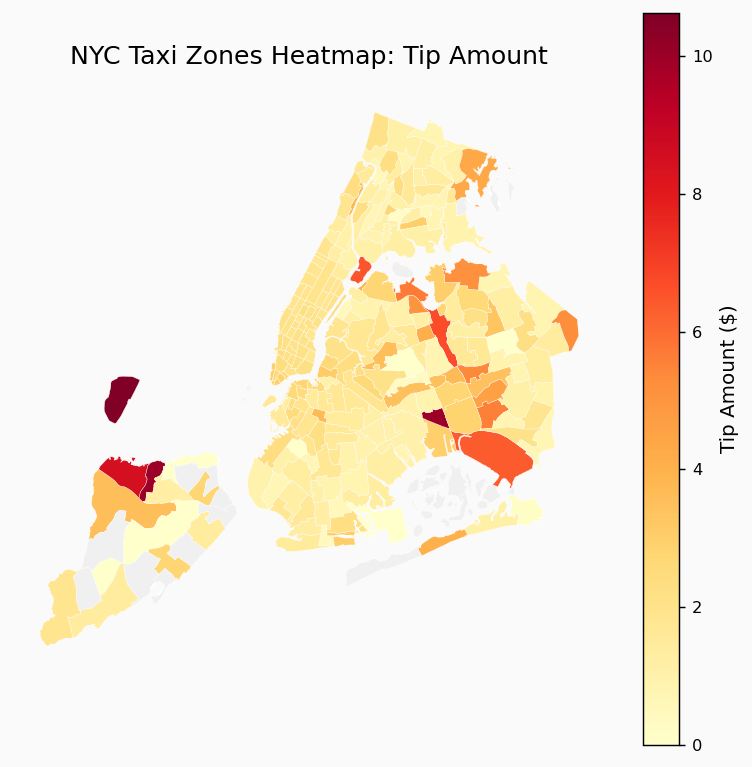

Top 10 Taxi Zones by Average Tip Amount (Only Zones with at least 100 trips):


,Zone,Borough,avg_tip_amount,number_of_trips,avg_trip_distance
131,JFK Airport,Queens,6.39,9524.0,15.49
137,LaGuardia Airport,Queens,5.70,7001.0,9.55
69,East Elmhurst,Queens,5.04,491.0,9.33
255,Williamsburg (South Side),Brooklyn,3.13,155.0,4.15
12,Battery Park City,Manhattan,2.97,1980.0,4.29
87,Financial District South,Manhattan,2.92,934.0,4.92
86,Financial District North,Manhattan,2.91,1730.0,4.52
65,DUMBO/Vinegar Hill,Brooklyn,2.80,101.0,5.08
222,Steinway,Queens,2.75,130.0,4.76
11,Battery Park,Manhattan,2.75,120.0,4.52


In [61]:
# Build heatmap of average tip amount by taxi zone, merging trip records with zone geometries
tip_col = "tip_amount"
distance_col = "trip_distance"
location_col_candidates = ["PULocationID", "DOLocationID"]  # prefer pickup if available
zone_key_candidates = ["LocationID", "PULocationID", "DOLocationID"]

location_col = next((c for c in location_col_candidates if c in df.columns), None)
zone_key_col = next((c for c in zone_key_candidates if c in zones_gdf.columns), None)

# Build zone-level metrics for tip and trip profile
tip_by_zone = (
    df.loc[df[tip_col].notna() & (df[tip_col] >= 0), [location_col, tip_col, distance_col]]
    .groupby(location_col, as_index=False)
    .agg(
        avg_tip_amount=(tip_col, "mean"),
        number_of_trips=(tip_col, "size"),
        avg_trip_distance=(distance_col, "mean"),
    )
    .rename(columns={location_col: zone_key_col})
)

# Merge with taxi zone geometries
tip_heatmap_gdf = zones_gdf.merge(tip_by_zone, on=zone_key_col, how="left")

# Plot geospatial heatmap
fig, ax = plt.subplots(figsize=(6, 6))
tip_heatmap_gdf.plot(
    column="avg_tip_amount",
    cmap="YlOrRd",
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "#f0f0f0", "label": "No data"},
    ax=ax,
)

ax.set_title("NYC Taxi Zones Heatmap: Tip Amount", fontsize=14, pad=12)
ax.set_axis_off()
cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("Tip Amount ($)")
plt.tight_layout()
plt.show()

# Table: zones with highest tips + trip volume + avg trip distance
display_cols = ["Zone", "Borough", "avg_tip_amount", "number_of_trips", "avg_trip_distance"]
# Show only zones with at least 100 trips to ensure reliability of tip estimates
top_tip_zones = tip_heatmap_gdf[tip_heatmap_gdf["number_of_trips"] >= 100]
top_tip_zones = (
    top_tip_zones[display_cols]
    .dropna(subset=["avg_tip_amount"])
    .sort_values("avg_tip_amount", ascending=False)
    .head(10)
    .copy()
)
top_tip_zones["avg_tip_amount"] = top_tip_zones["avg_tip_amount"].round(2)
top_tip_zones["avg_trip_distance"] = top_tip_zones["avg_trip_distance"].round(2)

print("Top 10 Taxi Zones by Average Tip Amount (Only Zones with at least 100 trips):")
display(top_tip_zones)

- JFK and LaGuardia with their high trip volume are perfect example of the relationship between trip distance and tip amount.
- For the other zones, the higher tip amount is also linked to longer trip distance.

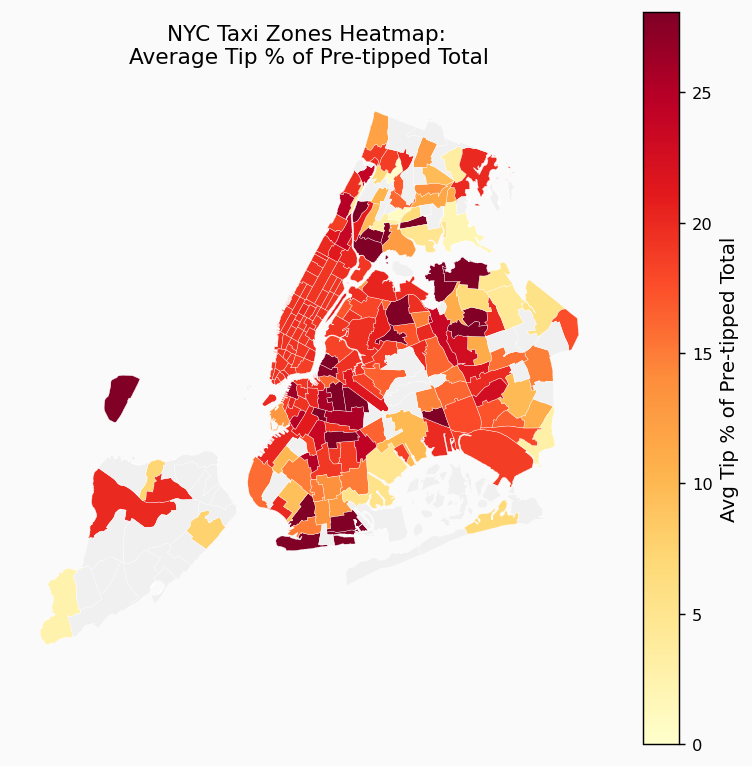

Top 10 Taxi Zones by Average Tip as % of Pre-tipped Total (Only Zones with at least 100 trips):


,Zone,Borough,avg_tip_pct_total,number_of_trips,avg_trip_distance
254,Williamsburg (North Side),Brooklyn,41.24,104.0,2.99
32,Brooklyn Heights,Brooklyn,26.38,143.0,4.18
243,Washington Heights South,Manhattan,24.87,159.0,5.26
41,Central Harlem North,Manhattan,23.70,173.0,3.33
151,Manhattanville,Manhattan,21.35,150.0,3.22
40,Central Harlem,Manhattan,21.07,634.0,2.48
23,Bloomingdale,Manhattan,20.30,655.0,2.70
208,Seaport,Manhattan,20.19,365.0,4.02
73,East Harlem North,Manhattan,20.09,527.0,2.75
165,Morningside Heights,Manhattan,20.03,1053.0,2.81


In [62]:
# Build heatmap of average tip as % of pre-tipped total by taxi zone
# Restrict to credit-card trips with positive tips, where tip percentage is meaningful
pct_col = "tip_pct_total"
distance_col = "trip_distance"
location_col_candidates = ["PULocationID", "DOLocationID"]  # prefer pickup if available
zone_key_candidates = ["LocationID", "PULocationID", "DOLocationID"]

location_col = next((c for c in location_col_candidates if c in cc_tip.columns), None)
zone_key_col = next((c for c in zone_key_candidates if c in zones_gdf.columns), None)

if location_col is None:
    raise KeyError(f"No location column found in cc_tip. Expected one of: {location_col_candidates}")
if zone_key_col is None:
    raise KeyError(f"No zone key found in zones_gdf. Expected one of: {zone_key_candidates}")

pct_by_zone = (
    cc_tip.loc[cc_tip[pct_col].notna(), [location_col, pct_col, distance_col]]
    .groupby(location_col, as_index=False)
    .agg(
        avg_tip_pct_total=(pct_col, "mean"),
        number_of_trips=(pct_col, "size"),
        avg_trip_distance=(distance_col, "mean"),
    )
    .rename(columns={location_col: zone_key_col})
)

pct_heatmap_gdf = zones_gdf.merge(pct_by_zone, on=zone_key_col, how="left")

fig, ax = plt.subplots(figsize=(6, 6))
pct_heatmap_gdf.plot(
    column="avg_tip_pct_total",
    cmap="YlOrRd",
    vmin=0,
    vmax=pct_heatmap_gdf["avg_tip_pct_total"].quantile(0.9),
    linewidth=0.2,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "#f0f0f0", "label": "No data"},
    ax=ax,
)

ax.set_title("NYC Taxi Zones Heatmap: " \
"\nAverage Tip % of Pre-tipped Total", fontsize=12, pad=12)
ax.set_axis_off()

cbar = ax.get_figure().axes[-1]
cbar.set_ylabel("Avg Tip % of Pre-tipped Total")

plt.tight_layout()
plt.show()

# Table: zones with highest average tip percentage + trip volume + avg trip distance
display_cols = ["Zone", "Borough", "avg_tip_pct_total", "number_of_trips", "avg_trip_distance"]
# Show only zones with at least 100 trips to ensure reliability of tip percentage estimates
top_tip_pct_zones = pct_heatmap_gdf[pct_heatmap_gdf["number_of_trips"] >= 100]
top_tip_pct_zones = (
    top_tip_pct_zones[display_cols]
    .dropna(subset=["avg_tip_pct_total"])
    .sort_values("avg_tip_pct_total", ascending=False)
    .head(10)
    .copy()
)

top_tip_pct_zones["avg_tip_pct_total"] = top_tip_pct_zones["avg_tip_pct_total"].round(2)
top_tip_pct_zones["avg_trip_distance"] = top_tip_pct_zones["avg_trip_distance"].round(2)

print("Top 10 Taxi Zones by Average Tip as % of Pre-tipped Total (Only Zones with at least 100 trips):")
display(top_tip_pct_zones)

- From the heatmap, many zones in outer boroughs have higher tipping rate, but they are excluded from the top 10 due to low trip volume.
- Brooklyn has the top 2 zones with highest tip %: Williamsburg is a clear number with a tip rate of 41%.
- Manhattan has the other 8 spots in the top 10, but from around 7th place, the tip % becomes very close the median 20% of all trips.

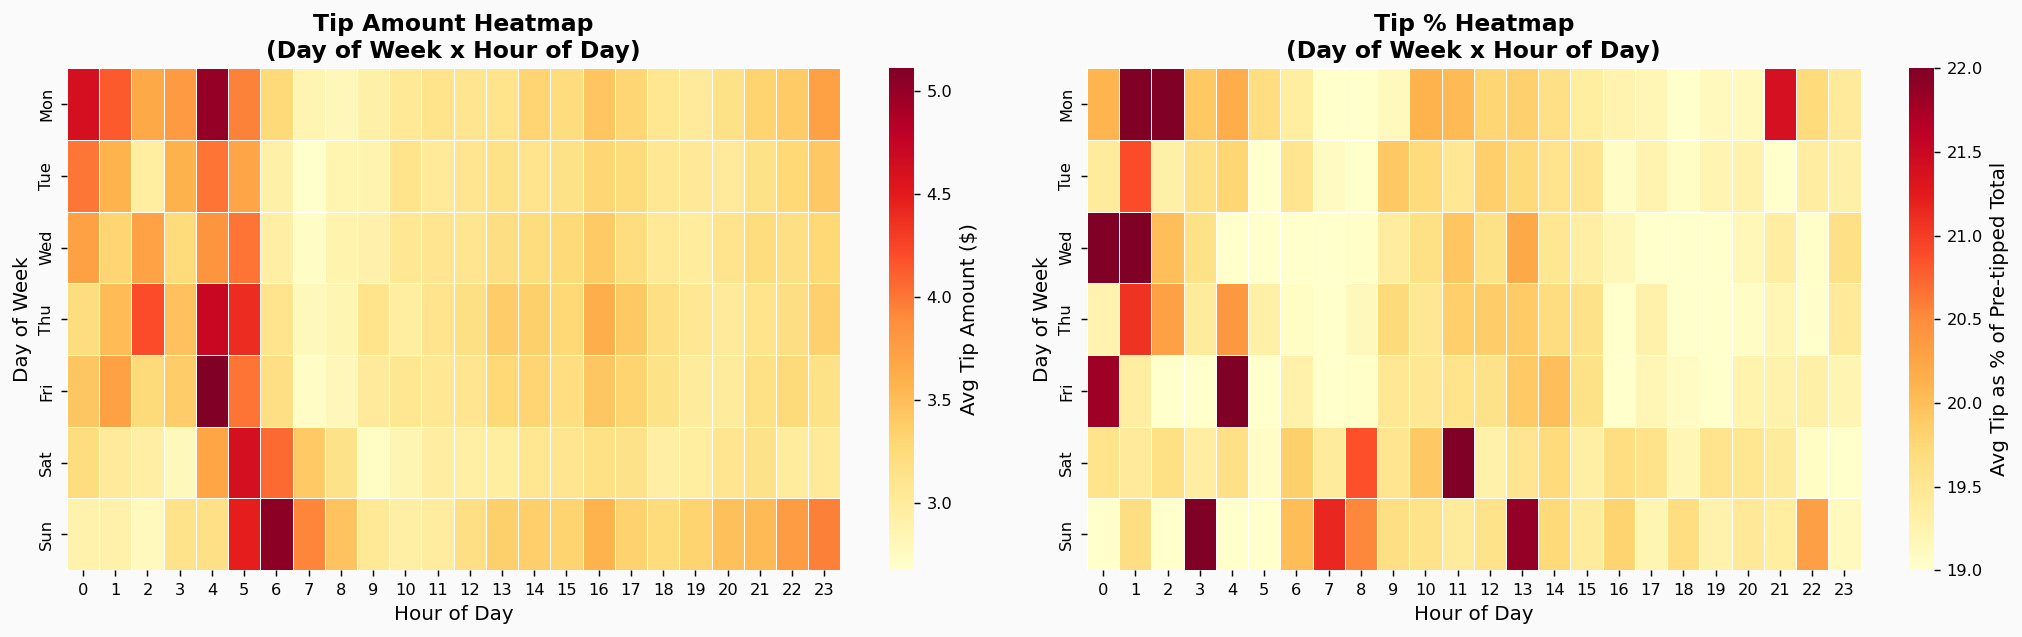

In [63]:
# Heatmaps by Day of Week x Time of Day for tipping metrics
# Use credit-card trips with positive tips for consistent tip-% interpretation
heatmap_df = cc_tip.copy()

# Aggregate metrics by day-of-week and hour
pivot_tip_amount = (
    heatmap_df.groupby(["pickup_dow", "pickup_hour"])["tip_amount"]
    .mean()
    .unstack(fill_value=0)
    .reindex(index=range(7), columns=range(24))
)

pivot_tip_pct = (
    heatmap_df.groupby(["pickup_dow", "pickup_hour"])["tip_pct_total"]
    .mean()
    .unstack(fill_value=0)
    .reindex(index=range(7), columns=range(24))
)

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot_tip_amount.index = dow_labels
pivot_tip_pct.index = dow_labels

# Plot side-by-side heatmaps
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    pivot_tip_amount,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Avg Tip Amount ($)"},
    ax=axes[0],
)
axes[0].set_title("Tip Amount Heatmap\n(Day of Week x Hour of Day)", fontweight="bold")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Day of Week")

sns.heatmap(
    pivot_tip_pct,
    cmap="YlOrRd",
    vmin=19,
    vmax=22,
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Avg Tip as % of Pre-tipped Total"},
    ax=axes[1],
)
axes[1].set_title("Tip % Heatmap\n(Day of Week x Hour of Day)", fontweight="bold")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Day of Week")

plt.tight_layout()
plt.show()

Tip amounts and tip percentages tend to be higher after midnights. This likely reflects a combination of longer trips, higher fares, and more generous tipping behavior during these times.

[Back to Table of Contents](#table-of-contents)
### 5.7. Fare Analysis (L2)

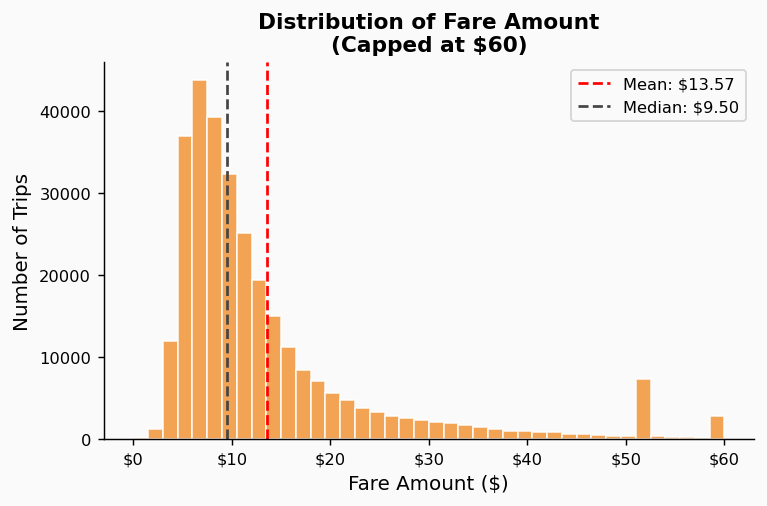

In [64]:
# Histogram of fare_amount (same style as Tip Amount histogram)
fare_hist_df = df[["fare_amount"]].dropna().copy()
fare_hist_df = fare_hist_df[fare_hist_df["fare_amount"] >= 0]

plt.figure(figsize=(6, 4))
plt.hist(
    fare_hist_df["fare_amount"].clip(upper=60),
    bins=40,
    color=PALETTE[1],
    alpha=0.8,
    edgecolor="white",
)
plt.axvline(
    fare_hist_df["fare_amount"].mean(),
    color="red",
    linestyle="--",
    linewidth=1.5,
    label=f"Mean: ${fare_hist_df['fare_amount'].mean():.2f}",
)
plt.axvline(
    fare_hist_df["fare_amount"].median(),
    color="#444444",
    linestyle="--",
    linewidth=1.5,
    label=f"Median: ${fare_hist_df['fare_amount'].median():.2f}",
)
plt.title("Distribution of Fare Amount\n(Capped at $60)", fontsize=12, fontweight="bold")
plt.xlabel("Fare Amount ($)")
plt.ylabel("Number of Trips")
plt.gca().xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"${v:.0f}"))
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

The distribution of fare amounts is right-skewed, with a long tail of higher fares. The majority of trips have fares clustered around the lower end of the spectrum, with mean and median fare amounts indicating that most trips cost under 20 USD.

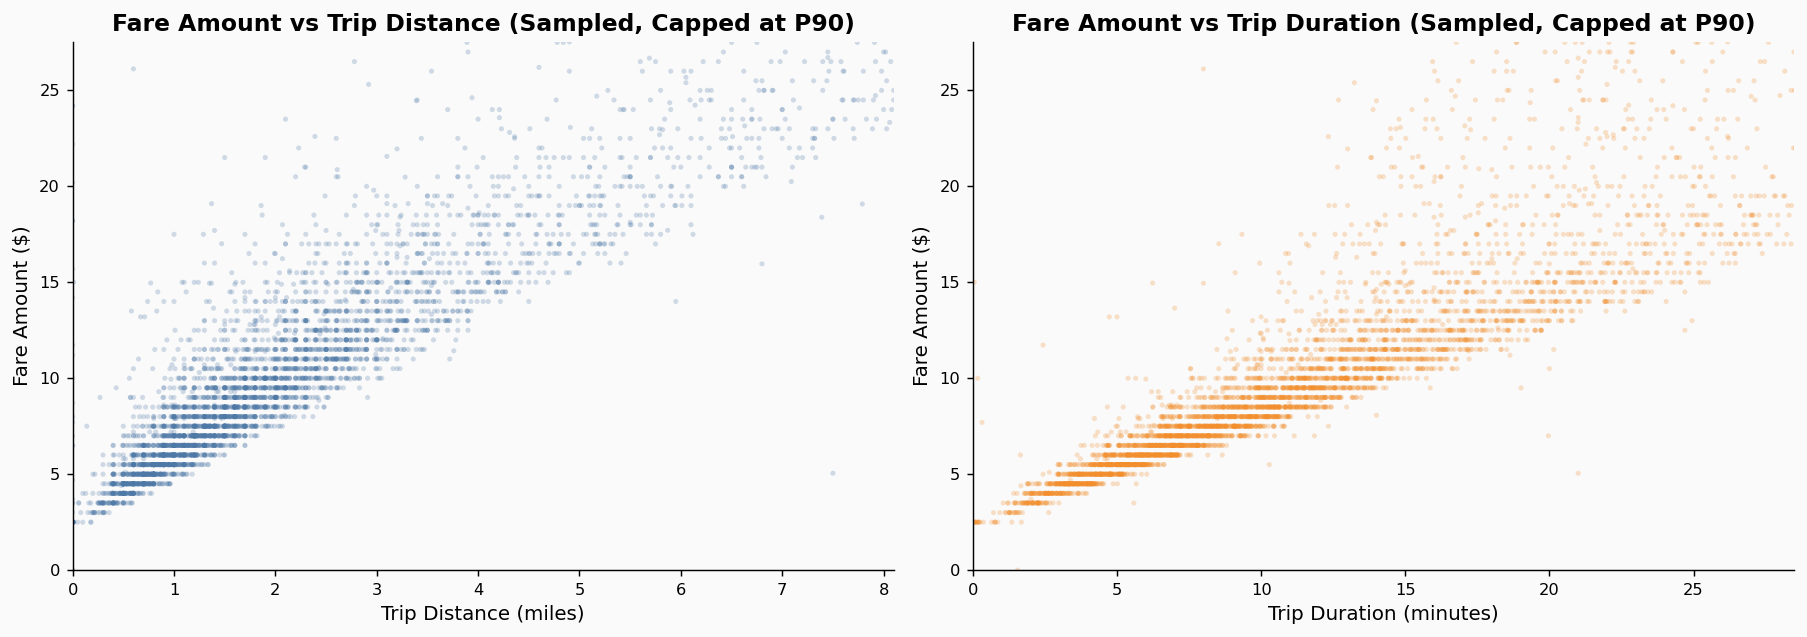

In [65]:
# Scatter plots (random sample + capped at 90th percentile): fare_amount vs trip_distance and fare_amount vs trip_duration_min
scatter_df = df[["fare_amount", "trip_distance", "trip_duration_min"]].dropna().copy()

# Use a random sample instead of the full dataset for plotting speed/readability
sample_n = min(5000, len(scatter_df))
scatter_sample = scatter_df.sample(n=sample_n, random_state=42)

# 90th-percentile caps from sampled data
fare_p90 = scatter_sample["fare_amount"].quantile(0.90)
dist_p90 = scatter_sample["trip_distance"].quantile(0.90)
dur_p90 = scatter_sample["trip_duration_min"].quantile(0.90)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Fare vs Distance
axes[0].scatter(
    scatter_sample["trip_distance"],
    scatter_sample["fare_amount"],
    s=8,
    alpha=0.25,
    color=PALETTE[0],
    edgecolors="none",
)
axes[0].set_title("Fare Amount vs Trip Distance (Sampled, Capped at P90)", fontweight="bold")
axes[0].set_xlabel("Trip Distance (miles)")
axes[0].set_ylabel("Fare Amount ($)")
axes[0].set_xlim(0, dist_p90)
axes[0].set_ylim(0, fare_p90)

# 2) Fare vs Duration
axes[1].scatter(
    scatter_sample["trip_duration_min"],
    scatter_sample["fare_amount"],
    s=8,
    alpha=0.25,
    color=PALETTE[1],
    edgecolors="none",
)
axes[1].set_title("Fare Amount vs Trip Duration (Sampled, Capped at P90)", fontweight="bold")
axes[1].set_xlabel("Trip Duration (minutes)")
axes[1].set_ylabel("Fare Amount ($)")
axes[1].set_xlim(0, dur_p90)
axes[1].set_ylim(0, fare_p90)

plt.tight_layout()
plt.show()

**Insights from Sampled Scatter Plots (P90-Capped)**

- Fare rises with both trip distance and trip duration, confirming strong positive relationships in both scatter plots.
- The fare-distance pattern is tighter and more linear than fare-duration, suggesting distance is the cleaner direct driver of pricing.
- The fare-duration plot is more dispersed at similar durations, indicating traffic and stop-and-go conditions introduce additional fare variability beyond travel time alone.

In [66]:
# Prepare analysis data
corr_df = df[["fare_amount", "trip_distance", "trip_duration_min"]].dropna().copy()

# Use a random sample to keep runtime fast and align with sampled scatter plots
sample_n = min(50000, len(corr_df))
corr_sample = corr_df.sample(n=sample_n, random_state=42)

results = []
for feature in ["trip_distance", "trip_duration_min"]:
    rho, p_value = spearmanr(corr_sample[feature], corr_sample["fare_amount"])
    results.append({
        "pair": f"fare_amount vs {feature}",
        "n": len(corr_sample),
        "spearman_rho": rho,
        "spearman_p": p_value,
    })

results_df = pd.DataFrame(results)

# Format for readability
formatted = results_df.copy()
formatted["spearman_rho"] = formatted["spearman_rho"].map(lambda v: f"{v:.4f}")
formatted["spearman_p"] = formatted["spearman_p"].map(lambda v: f"{v:.3e}")

print("Spearman correlation tests (random sample):")
display(formatted)

alpha = 0.05
for _, row in results_df.iterrows():
    significance = "significant" if row["spearman_p"] < alpha else "not significant"
    print(f"{row['pair']}: Spearman rho={row['spearman_rho']:.4f} ({significance})")

Spearman correlation tests (random sample):


,pair,n,spearman_rho,spearman_p
0,fare_amount vs trip_distance,50000,0.8996,0.000e+00
1,fare_amount vs trip_duration_min,50000,0.9376,0.000e+00


fare_amount vs trip_distance: Spearman rho=0.8996 (significant)
fare_amount vs trip_duration_min: Spearman rho=0.9376 (significant)


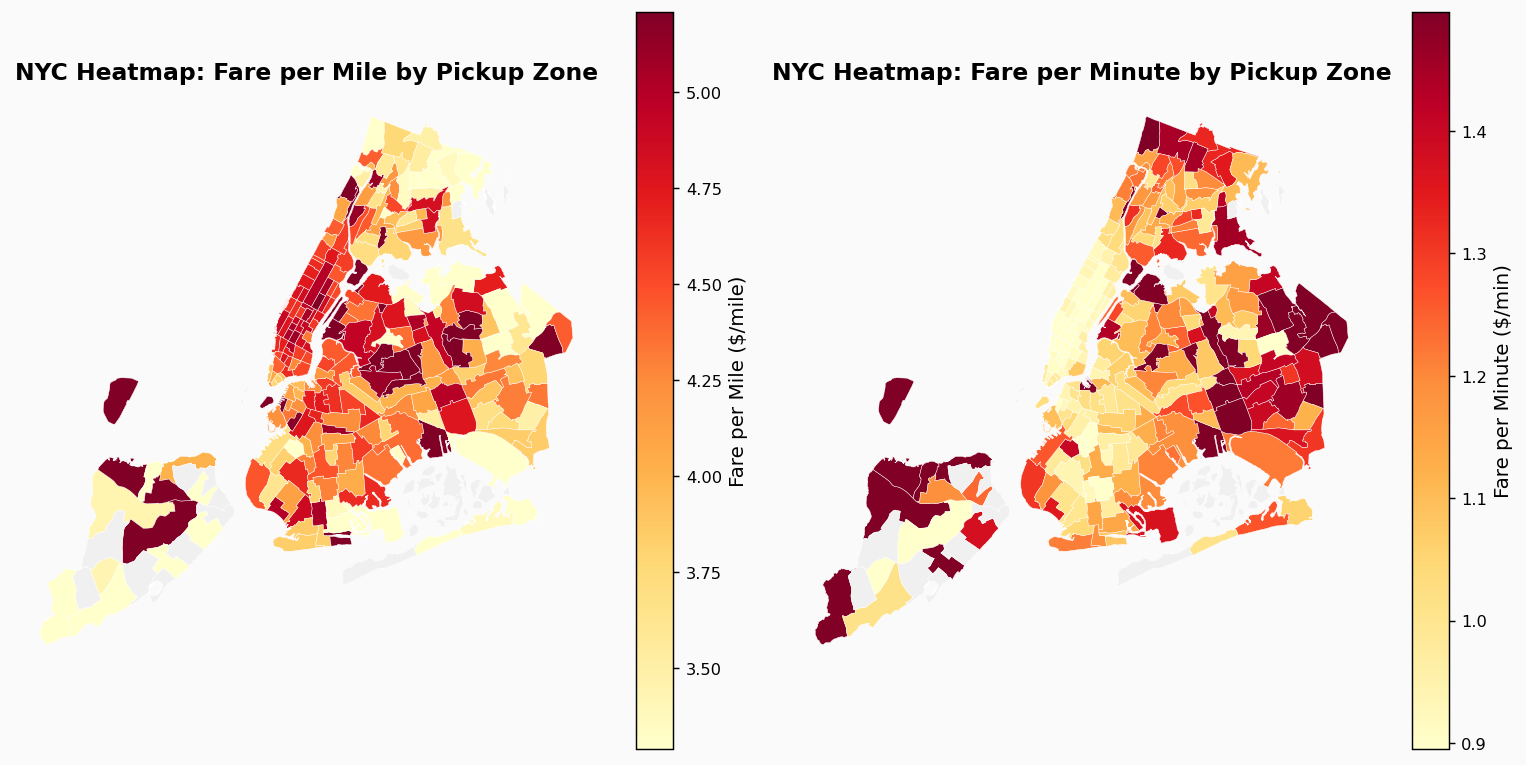

In [67]:
# Heatmaps by zone: fare per mile and fare per minute (pickup zones)
zone_fare_df = df.copy()

# Ensure trip duration in minutes exists
if "trip_duration_min" not in zone_fare_df.columns:
    zone_fare_df["trip_duration_min"] = (
        zone_fare_df["tpep_dropoff_datetime"] - zone_fare_df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

zone_metrics = (
    zone_fare_df.groupby("PULocationID", as_index=False)
    .agg(
        total_fare=("fare_amount", "sum"),
        total_distance=("trip_distance", "sum"),
        total_duration_min=("trip_duration_min", "sum"),
        trip_count=("PULocationID", "size"),
    )
)

zone_metrics["fare_per_mile"] = np.where(
    zone_metrics["total_distance"] > 0,
    zone_metrics["total_fare"] / zone_metrics["total_distance"],
    np.nan,
)
zone_metrics["fare_per_minute"] = np.where(
    zone_metrics["total_duration_min"] > 0,
    zone_metrics["total_fare"] / zone_metrics["total_duration_min"],
    np.nan,
)

fare_zone_heatmap_gdf = zones_gdf.merge(zone_metrics, on="PULocationID", how="left")

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# 1) Fare per mile heatmap
fare_zone_heatmap_gdf.plot(
    column="fare_per_mile",
    cmap="YlOrRd",
    vmin=fare_zone_heatmap_gdf["fare_per_mile"].quantile(0.10),
    vmax=fare_zone_heatmap_gdf["fare_per_mile"].quantile(0.90),
    linewidth=0.25,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "#f0f0f0", "label": "No data"},
    ax=axes[0],
)
axes[0].set_title("NYC Heatmap: Fare per Mile by Pickup Zone", fontweight="bold")
axes[0].set_axis_off()
cbar1 = axes[0].get_figure().axes[-1]
cbar1.set_ylabel("Fare per Mile ($/mile)")

# 2) Fare per minute heatmap
fare_zone_heatmap_gdf.plot(
    column="fare_per_minute",
    cmap="YlOrRd",
    vmin=fare_zone_heatmap_gdf["fare_per_minute"].quantile(0.10),
    vmax=fare_zone_heatmap_gdf["fare_per_minute"].quantile(0.90),
    linewidth=0.25,
    edgecolor="white",
    legend=True,
    missing_kwds={"color": "#f0f0f0", "label": "No data"},
    ax=axes[1],
)
axes[1].set_title("NYC Heatmap: Fare per Minute by Pickup Zone", fontweight="bold")
axes[1].set_axis_off()
cbar2 = axes[1].get_figure().axes[-1]
cbar2.set_ylabel("Fare per Minute ($/min)")

plt.tight_layout()
plt.show()

**Insights from Fare Efficiency Heatmaps**

- Both maps show clear zone-level variation rather than a uniform citywide pattern, indicating fare efficiency differs by pickup zone.
- The spatial pattern is not identical between the two metrics: some zones appear relatively stronger in fare per mile while others appear relatively stronger in fare per minute.
- Inner city zones (within Manhattan) have higher fare per mile but lower fare per minute, suggesting that most trips in the city center have shorter distance but take longer time compared to peripheral zones (for the same level of fare), probably due to congestion.

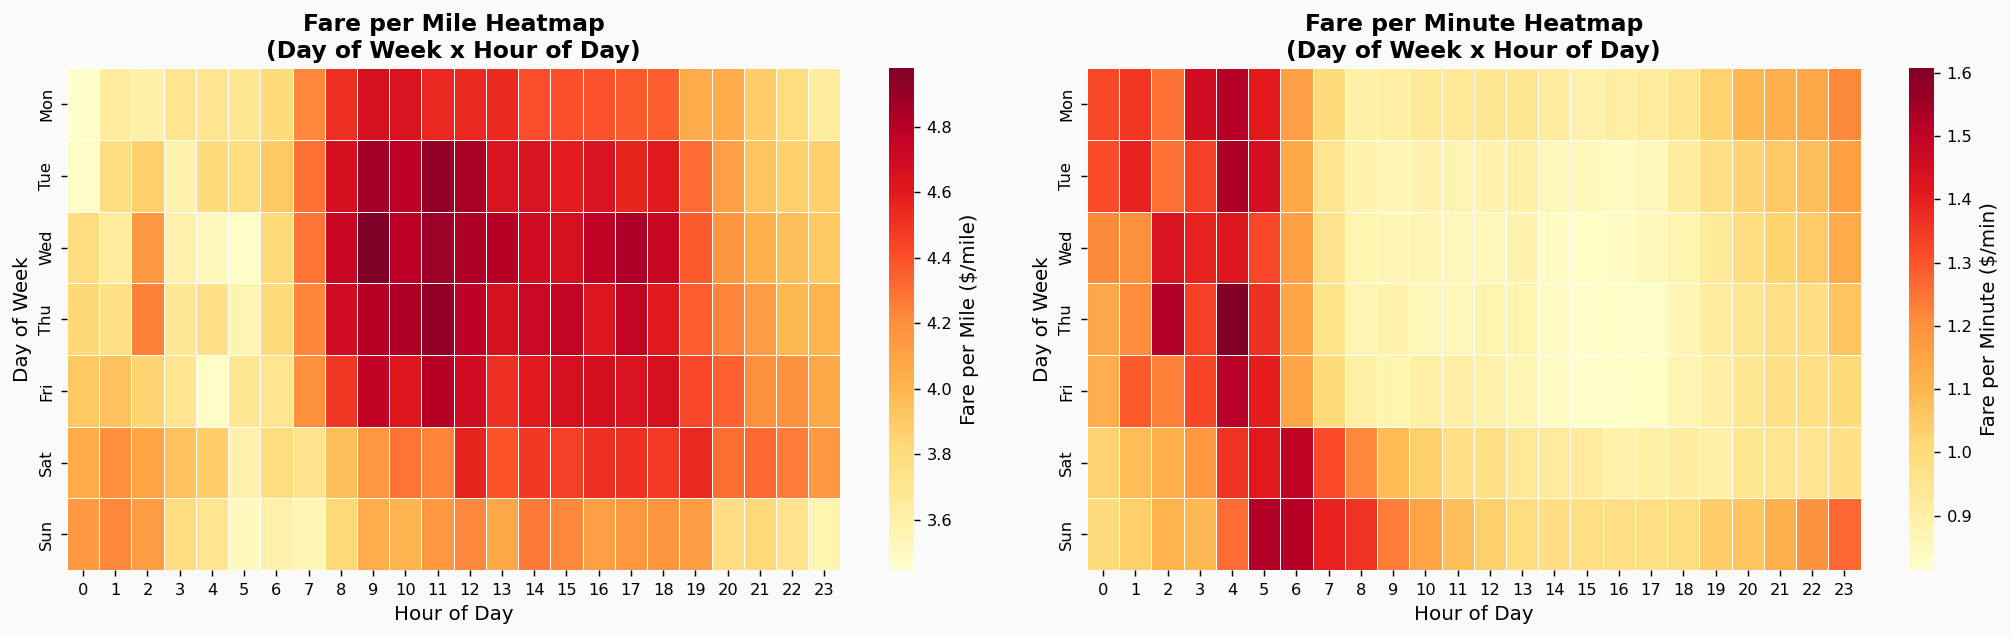

In [68]:
# Heatmaps by Day of Week x Time of Day for fare efficiency metrics
temp_df = df.copy()

# Ensure duration column exists
if "trip_duration_min" not in temp_df.columns:
    temp_df["trip_duration_min"] = (
        temp_df["tpep_dropoff_datetime"] - temp_df["tpep_pickup_datetime"]
    ).dt.total_seconds() / 60

# Aggregate by day-of-week and hour, then compute efficiency ratios
eff_time = (
    temp_df.groupby(["pickup_dow", "pickup_hour"], as_index=False)
    .agg(
        total_fare=("fare_amount", "sum"),
        total_distance=("trip_distance", "sum"),
        total_duration_min=("trip_duration_min", "sum"),
    )
)

eff_time["fare_per_mile"] = np.where(
    eff_time["total_distance"] > 0,
    eff_time["total_fare"] / eff_time["total_distance"],
    np.nan,
)
eff_time["fare_per_minute"] = np.where(
    eff_time["total_duration_min"] > 0,
    eff_time["total_fare"] / eff_time["total_duration_min"],
    np.nan,
)

pivot_fpmile = (
    eff_time.pivot(index="pickup_dow", columns="pickup_hour", values="fare_per_mile")
    .reindex(index=range(7), columns=range(24))
)
pivot_fpmin = (
    eff_time.pivot(index="pickup_dow", columns="pickup_hour", values="fare_per_minute")
    .reindex(index=range(7), columns=range(24))
)

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pivot_fpmile.index = dow_labels
pivot_fpmin.index = dow_labels

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    pivot_fpmile,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Fare per Mile ($/mile)"},
    ax=axes[0],
)
axes[0].set_title("Fare per Mile Heatmap\n(Day of Week x Hour of Day)", fontweight="bold")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Day of Week")

sns.heatmap(
    pivot_fpmin,
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Fare per Minute ($/min)"},
    ax=axes[1],
)
axes[1].set_title("Fare per Minute Heatmap\n(Day of Week x Hour of Day)", fontweight="bold")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Day of Week")

plt.tight_layout()
plt.show()

**Quick insights from the fare-efficiency heatmaps:**

- **Fare per mile** and **fare per minute** show different hotspot patterns, so they should be interpreted together.

- Periods with stronger **dollar/mile** likely reflect slower traffic conditions where there are more traffic jams (eg. weekday office hours) .

- Periods with stronger **dollar/min** but weaker **dollar/mile** suggest more time-efficient trips such as less congestion or longer direct routes (eg. after midnight on weekdays and early morning on weekends).

- The split between these two metrics supports using both as complementary KPIs for shift planning and operational monitoring.


[Back to Table of Contents](#table-of-contents)
## **6. Conclusions**

This analysis shows that taxi performance is strongly shaped by **when** and **where** trips happen, not just by city wide volume.

**Key conclusions from the notebook findings:**
- **Overview**:
   - Demand is the highest in Manhattan (about 90% of total number of trips), and it is time-dependent.
   - Average revenue goes up from 16 to 27 USD over the 5-year period, with fare making up the majority of total revenue.
   - Payment by card increases over time, reaching over 75% in 2023. About 95% of card-paid trips have tips, and tip amount rises about 50% from 2018 to 2023.
   - Revenue efficiency per mile and per minute both see a large boost in 2023.
- **Time and Space analysis:**
   - Trip demand, trip distance and revenue efficiency vary clearly by hour/day and by zone, confirming strong temporal and spatial influence on operations.
   - Weekday late afternoons and early evenings have the highest demand.
   - March 2020 is the outlier when there was extremely low trip volumne in the 2nd half of the month, which correlates with Covid timing.
   - Core city zones with high trip volume and short trip distance have better revenue per mile, but peripheral zones outperform in revenue per minute.
- **Vendor analysis:** Trip volume is concentrated in the two largest vendors (over 99%), while smaller vendors have low share and more volatile outcomes; revenue per trip rises over time, and revenue efficiency differs by vendor.
- **Rate-code analysis:** Standard rides dominate trip volume (nearly 97%), while negotiated segment has longer trip profiles and stronger revenue quality despite smaller shares.
- **Tip analysis:** Tip amount has right-skewed distribution and increases with trip distance. Many trips cluster around a 20% tipping level.
- **Fare analysis:**
   - Fare amount increases with trip distance and trip duration (supported by correlation tests and scatter patterns).
   - Fare-per-mile and fare-per-minute do not peak at the same times, which suggests different operating conditions across periods (for example, longer/more direct trips versus slower/congested trips).

**Business Recommendations**

1. Adopt a Zone- and Time-Specific Operating Model

Demand and operational metrics vary significantly across pickup zones and time periods. Overall averages mask substantial local differences in performance. Management should monitor KPIs at the zone and time-segment level rather than relying solely on citywide metrics. This would enable more targeted driver allocation, shift planning, and performance monitoring.

2. Use Revenue per Mile and Revenue per Minute as Complementary KPIs

The analysis shows that revenue per mile and revenue per minute often highlight different operational hotspots. Short urban trips tend to generate stronger revenue per mile, while longer trips in peripheral zones frequently achieve better revenue per minute. Because the two metrics capture different dimensions of efficiency, management decisions should consider both rather than relying on a single profitability measure.

3. Prioritize Peak Demand Periods for Capacity Planning

Trip volume exhibits clear temporal patterns by day of week, and hour of day. These recurring peaks suggest opportunities to better align driver availability with expected demand. Future operational planning could incorporate these patterns to improve service availability during high-demand periods while reducing underutilization during lower-demand periods.

4. Investigate High-Efficiency Route and Rate-Code Segments

Certain zones and rate-code categories consistently outperform others on revenue and efficiency metrics. However, the analysis does not establish whether these segments are operationally scalable or whether the observed performance is driven by a limited number of trips. 
These segments should therefore be treated as candidates for further investigation rather than immediate optimization targets.

5. Establish Ongoing Data-Quality Monitoring

The dataset contains a small number of anomalous observations, including missing records and records with unrealistic travel characteristics. While these records represent a small share of total volume, they can materially affect operational metrics if left unchecked. Automated monitoring of key data-quality indicators would improve the reliability of future reporting and decision-making.

6. Validate Findings Through Additional Data Sources

This analysis identifies several strong patterns and associations but does not establish causality. Future work could incorporate external factors such as weather, traffic conditions, airport activity, or economic indicators to better understand the drivers behind observed demand and revenue trends. These additional analyses would help convert descriptive insights into more actionable business decisions.
